# Feature Engineering Notebook

## Objectives

*   Engineer features for Regression models


## Inputs

* outputs/datasets/cleaned/TrainSetCleaned.csv
* outputs/datasets/cleaned/TestSetCleaned.csv

## Outputs

* generate a list with variables to engineer

## Conclusions

* Feature Engineering Transformers
  * Sparse Feature Removal ["OpenPorchSF", "MasVnrArea"], transformed into binary indicators outside the pipeline prior to removal.

  * Ordinal Encoding ["BsmtExposure", "BsmtFinType1", "GarageFinish", "KitchenQual"]

  * Numerical Transformation

    * PowerTransformer ["1stFlrSF"].

    * Yeo-Johnson transformation ["BedroomAbvGr", "BsmtFinSF1", "BsmtUnfSF", "GarageArea", "YearBuilt", "YearRemodAdd", "GrLivArea", "LotArea", "LotFrontage", "OverallCond", "TotalBsmtSF"]

    * Log10 transformation ["GarageYrBlt"]

    * Box-Cox transformation ["OverallQual"]

* Correlated Feature Removal based on Smart Correlation Selection, ["1stFlrSF", "GarageYrBlt"] while protecting key predictors like OverallQual and GrLivArea.

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\farib\\Projects\\Heritage-House-Price-Insight-Predictor\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\farib\\Projects\\Heritage-House-Price-Insight-Predictor'

# Load Cleaned Data

Train Set

In [4]:
import pandas as pd
train_set_path = "outputs/datasets/cleaned/TrainSetCleaned.csv"
TrainSet = pd.read_csv(train_set_path)
TrainSet.head(3)


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GarageYrBlt,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice
0,1828,0.0,3.0,Av,48,Unf,1774,774,Unf,2007.0,...,11694,90.0,452.0,108,5,9,1822,2007,2007,314813
1,894,0.0,2.0,No,0,Unf,894,308,Unf,1962.0,...,6600,60.0,0.0,0,5,5,894,1962,1962,109500
2,964,0.0,2.0,No,713,ALQ,163,432,Unf,1921.0,...,13360,80.0,0.0,0,7,5,876,1921,2006,163500


Test Set

In [5]:
test_set_path = 'outputs/datasets/cleaned/TestSetCleaned.csv'
TestSet = pd.read_csv(test_set_path)
TestSet.head(3)


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GarageYrBlt,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice
0,2515,0.0,4.0,No,1219,Rec,816,484,Unf,1975.0,...,32668,69.0,0.0,0,3,6,2035,1957,1975,200624
1,958,620.0,3.0,No,403,BLQ,238,240,Unf,1941.0,...,9490,79.0,0.0,0,7,6,806,1941,1950,133000
2,979,224.0,3.0,No,185,LwQ,524,352,Unf,1950.0,...,7015,69.0,161.0,0,4,5,709,1950,1950,110000


# Data Exploration

In feature engineering, you are interested to evaluate which potential transformation you could do in your variables

In [6]:
from ydata_profiling import ProfileReport
pandas_report = ProfileReport(df=TrainSet, minimal=True)
pandas_report.to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

---

# Correlation and PPS Analysis

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ppscore as pps

%matplotlib inline

sns.set(style="whitegrid")


def heatmap_corr(df, threshold, figsize=(20, 12), font_annot=8):
    """
    Plots a heatmap of the correlation matrix with masking applied
    to low-correlation values and the upper triangle.

    Parameters:
    - df (DataFrame): Correlation matrix (e.g., Pearson or Spearman).
    - threshold (float): Minimum absolute value for correlation to be shown.
    - figsize (tuple): Figure size for the plot.
    - font_annot (int): Font size for annotation values inside heatmap.
    """
    if len(df.columns) > 1:
        # Create a mask to hide upper triangle and weak correlations
        mask = np.zeros_like(df, dtype=bool)
        mask[np.triu_indices_from(mask)] = True
        mask[abs(df) < threshold] = True

        # Plot the heatmap
        fig, axes = plt.subplots(figsize=figsize)
        sns.heatmap(df, annot=True, xticklabels=True, yticklabels=True,
                    mask=mask, cmap='viridis', annot_kws={"size": font_annot},
                    ax=axes, linewidth=0.5)
        axes.set_yticklabels(df.columns, rotation=0)
        plt.ylim(len(df.columns), 0)
        plt.show()


def heatmap_pps(df, threshold, figsize=(20, 12), font_annot=8):
    """
    Plots a heatmap for a PPS (Predictive Power Score) matrix, with
    masking of low predictive scores.

    Parameters:
    - df (DataFrame): PPS matrix.
    - threshold (float): Minimum PPS score to be shown.
    - figsize (tuple): Figure size for the plot.
    - font_annot (int): Font size for annotation values inside heatmap.
    """
    if len(df.columns) > 1:
        # Mask low PPS values
        mask = np.zeros_like(df, dtype=bool)
        mask[abs(df) < threshold] = True

        # Plot the heatmap
        fig, ax = plt.subplots(figsize=figsize)
        sns.heatmap(df, annot=True, xticklabels=True, yticklabels=True,
                    mask=mask, cmap='rocket_r', annot_kws={"size": font_annot},
                    linewidth=0.05, linecolor='grey')
        plt.ylim(len(df.columns), 0)
        plt.show()


def CalculateCorrAndPPS(df):
    """
    Calculates Pearson and Spearman correlation matrices, and the PPS matrix.
    Also prints a statistical summary of PPS values below 1.

    Parameters:
    - df (DataFrame): Input dataset.

    Returns:
    - Tuple: (Pearson correlation matrix, Spearman correlation
    matrix, PPS matrix)
    """
    # Correlation matrices
    df_corr_spearman = df.corr(method="spearman", numeric_only=True)
    df_corr_pearson = df.corr(method="pearson", numeric_only=True)

    # Calculate Predictive Power Score matrix
    pps_matrix_raw = pps.matrix(df)
    pps_matrix = pps_matrix_raw.filter(['x', 'y', 'ppscore']).pivot(
        columns='x', index='y', values='ppscore')

    # Display IQR statistics for PPS values < 1
    pps_score_stats = pps_matrix_raw.query(
            "ppscore < 1").filter(['ppscore']).describe().T
    print("PPS threshold - check PPS score IQR to decide threshold"
          " for heatmap \n")
    print(pps_score_stats.round(3))

    return df_corr_pearson, df_corr_spearman, pps_matrix


def DisplayCorrAndPPS(df_corr_pearson, df_corr_spearman, pps_matrix,
                      CorrThreshold, PPS_Threshold,
                      figsize=(20, 12), font_annot=8):
    """
    Displays correlation and PPS heatmaps side by side to evaluate
    relationships between features and the target variable.

    Parameters:
    - df_corr_pearson (DataFrame): Pearson correlation matrix.
    - df_corr_spearman (DataFrame): Spearman correlation matrix.
    - pps_matrix (DataFrame): Predictive Power Score matrix.
    - CorrThreshold (float): Threshold for showing correlation values.
    - PPS_Threshold (float): Threshold for showing PPS values.
    - figsize (tuple): Figure size for plots.
    - font_annot (int): Font size for annotations in the heatmaps.
    """
    print("\n")
    print("* Analyse how the target variable for your ML models "
          "are correlated with other variables (features and target)")
    print("* Analyse multi-collinearity*")


Calculate Correlations and Power Predictive Score

In [8]:
import warnings
warnings.filterwarnings('ignore')
df_corr_pearson, df_corr_spearman, pps_matrix = CalculateCorrAndPPS(TrainSet)


PPS threshold - check PPS score IQR to decide threshold for heatmap 

         count   mean    std  min  25%  50%    75%    max
ppscore  462.0  0.055  0.108  0.0  0.0  0.0  0.061  0.873


After cleaning, max PPS increased from 0.702 to 0.873, suggesting better signal in the data.

IQR (Q3 - Q1) is almost the same, only minor increase.

**Display at Heatmaps**

In [9]:
%matplotlib inline
DisplayCorrAndPPS(df_corr_pearson=df_corr_pearson,
                  df_corr_spearman=df_corr_spearman,
                  pps_matrix=pps_matrix,
                  CorrThreshold=0.4, PPS_Threshold=0.06,
                  figsize=(12, 10), font_annot=10)




* Analyse how the target variable for your ML models are correlated with other variables (features and target)
* Analyse multi-collinearity*


---

# Feature Engineering

## Custom function

We are going to use the custom function in the feature-engine lesson. That will help us with the feature engineering process.

In [10]:
import scipy.stats as stats
import matplotlib.pyplot as plt
from feature_engine import transformation as vt
from feature_engine.outliers import Winsorizer
from feature_engine.encoding import OrdinalEncoder


def FeatureEngineeringAnalysis(df, analysis_type=None):
    """
    Perform exploratory feature engineering on a DataFrame
    based on the specified analysis type.

    Parameters:
    - df (pd.DataFrame): The input dataset.
    - analysis_type (str): One of 'numerical', 'ordinal_encoder',
    'outlier_winsorizer'.

    Returns:
    - pd.DataFrame: Transformed DataFrame including all tested transformations.
    """
    check_missing_values(df)
    allowed_types = ['numerical', 'ordinal_encoder', 'outlier_winsorizer']
    check_user_entry_on_analysis_type(analysis_type, allowed_types)
    list_column_transformers = define_list_column_transformers(analysis_type)

    df_feat_eng = pd.DataFrame([])

    for column in df.columns:
        # Add the original column and placeholders for transformations
        df_feat_eng = pd.concat([df_feat_eng, df[column]], axis=1)
        for method in list_column_transformers:
            df_feat_eng[f"{column}_{method}"] = df[column]

        # Apply transformations based on the analysis type
        df_feat_eng, list_applied_transformers = apply_transformers(
            analysis_type, df_feat_eng, column)

        # Visualize performance of transformations
        transformer_evaluation(column, list_applied_transformers,
                               analysis_type, df_feat_eng)

    return df_feat_eng


def check_user_entry_on_analysis_type(analysis_type, allowed_types):
    """Raise an error if the analysis_type is invalid or missing."""
    if analysis_type is None:
        raise SystemExit(
            f"You should pass analysis_type parameter as one "
            f"of the following options: {allowed_types}")
    if analysis_type not in allowed_types:
        raise SystemExit(
            f"analysis_type argument should be one of "
            f"these options: {allowed_types}")


def check_missing_values(df):
    """Raise an error if missing values are present in the DataFrame."""
    if df.isna().sum().sum() != 0:
        raise SystemExit(
            f"There is a missing value in your dataset. "
            f"Please handle that before getting into feature engineering.")


def define_list_column_transformers(analysis_type):
    """Define suffixes based on transformation method."""
    if analysis_type == 'numerical':
        return ["log_e", "log_10", "reciprocal", "power",
                "box_cox", "yeo_johnson"]
    elif analysis_type == 'ordinal_encoder':
        return ["ordinal_encoder"]
    elif analysis_type == 'outlier_winsorizer':
        return ['iqr']


def apply_transformers(analysis_type, df_feat_eng, column):
    """Apply the appropriate transformation pipeline to the column."""
    for col in df_feat_eng.select_dtypes(include='category').columns:
        df_feat_eng[col] = df_feat_eng[col].astype('object')

    if analysis_type == 'numerical':
        return FeatEngineering_Numerical(df_feat_eng, column)
    elif analysis_type == 'outlier_winsorizer':
        return FeatEngineering_OutlierWinsorizer(df_feat_eng, column)
    elif analysis_type == 'ordinal_encoder':
        return FeatEngineering_CategoricalEncoder(df_feat_eng, column)


def transformer_evaluation(column, list_applied_transformers,
                           analysis_type, df_feat_eng):
    """
    Display diagnostic plots and information about transformation impact.

    Parameters:
    - column (str): Original feature name.
    - list_applied_transformers (list): List of transformed column names.
    - analysis_type (str): Type of transformation.
    - df_feat_eng (pd.DataFrame): Engineered feature set.
    """
    print(f"* Variable Analyzed: {column}")
    print(f"* Applied transformation: {list_applied_transformers} \n")
    for col in [column] + list_applied_transformers:
        if analysis_type != 'ordinal_encoder':
            DiagnosticPlots_Numerical(df_feat_eng, col)
        else:
            if col == column:
                DiagnosticPlots_Categories(df_feat_eng, col)
            else:
                DiagnosticPlots_Numerical(df_feat_eng, col)
        print("\n")


def DiagnosticPlots_Categories(df_feat_eng, col):
    """Generate bar plot for categorical variables."""
    plt.figure(figsize=(4, 3))
    sns.countplot(data=df_feat_eng, x=col, palette=['#432371'],
                  order=df_feat_eng[col].squeeze().value_counts().index)
    plt.xticks(rotation=90)
    plt.suptitle(f"{col}", fontsize=30, y=1.05)
    plt.show()


def DiagnosticPlots_Numerical(df, variable):
    """Generate histogram, QQ-plot, and boxplot for numerical variables."""
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    sns.histplot(data=df, x=variable, kde=True, element="step", ax=axes[0])
    stats.probplot(df[variable], dist="norm", plot=axes[1])
    sns.boxplot(x=df[variable], ax=axes[2])

    axes[0].set_title('Histogram')
    axes[1].set_title('QQ Plot')
    axes[2].set_title('Boxplot')
    fig.suptitle(f"{variable}", fontsize=30, y=1.05)
    plt.tight_layout()
    plt.show()


def FeatEngineering_CategoricalEncoder(df_feat_eng, column):
    """Apply ordinal encoding to a single categorical feature."""
    list_methods_worked = []
    try:
        encoder = OrdinalEncoder(encoding_method='arbitrary',
                                 variables=[f"{column}_ordinal_encoder"])
        df_feat_eng = encoder.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_ordinal_encoder")
    except Exception:
        df_feat_eng.drop([f"{column}_ordinal_encoder"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked


def FeatEngineering_OutlierWinsorizer(df_feat_eng, column):
    """Apply IQR-based winsorization to handle outliers."""
    list_methods_worked = []
    try:
        disc = Winsorizer(capping_method='iqr', tail='both', fold=1.5,
                          variables=[f"{column}_iqr"])
        df_feat_eng = disc.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_iqr")
    except Exception:
        df_feat_eng.drop([f"{column}_iqr"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked


def FeatEngineering_Numerical(df_feat_eng, column):
    """Apply various numerical transformations to a feature."""
    list_methods_worked = []

    # Log base e
    try:
        lt = vt.LogTransformer(variables=[f"{column}_log_e"])
        df_feat_eng = lt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_log_e")
    except Exception:
        df_feat_eng.drop([f"{column}_log_e"], axis=1, inplace=True)

    # Log base 10
    try:
        lt = vt.LogTransformer(variables=[f"{column}_log_10"], base='10')
        df_feat_eng = lt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_log_10")
    except Exception:
        df_feat_eng.drop([f"{column}_log_10"], axis=1, inplace=True)

    # Reciprocal
    try:
        rt = vt.ReciprocalTransformer(variables=[f"{column}_reciprocal"])
        df_feat_eng = rt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_reciprocal")
    except Exception:
        df_feat_eng.drop([f"{column}_reciprocal"], axis=1, inplace=True)

    # Power
    try:
        pt = vt.PowerTransformer(variables=[f"{column}_power"])
        df_feat_eng = pt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_power")
    except Exception:
        df_feat_eng.drop([f"{column}_power"], axis=1, inplace=True)

    # Box-Cox
    try:
        bct = vt.BoxCoxTransformer(variables=[f"{column}_box_cox"])
        df_feat_eng = bct.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_box_cox")
    except Exception:
        df_feat_eng.drop([f"{column}_box_cox"], axis=1, inplace=True)

    # Yeo-Johnson
    try:
        yjt = vt.YeoJohnsonTransformer(variables=[f"{column}_yeo_johnson"])
        df_feat_eng = yjt.fit_transform(df_feat_eng)
        list_methods_worked.append(f"{column}_yeo_johnson")
    except Exception:
        df_feat_eng.drop([f"{column}_yeo_johnson"], axis=1, inplace=True)

    return df_feat_eng, list_methods_worked


## Feature Engineering Spreadsheet Summary

The transformers I will use:

* Drop high-zero features + Add binary flags: ['OpenPorchSF', 'MasVnrArea']
* Winsorization if skewed (|skew| > 0.5): ['1stFlrSF', '2ndFlrSF', 'BsmtFinSE1', 'BsmtUnfSF', 'GarageYrBlt', 'GrLivArea', 'LotArea', 'LotFrontage', 'OverallCond' 'TotalBsmtSF', 'YearBlt' ]
* Numerical Transformation: ['1stFlrSF', '2ndFlrSF', 'BedroomAbvGr', 'BsmtFinSE1', 'BsmtUnfSF', 'GarageArea', 'GarageYrBlt', 'GrLivArea', 'LotArea', 'LotFrontage', 'OverallCond', 'OverallQual', 'TotalBsmtSF', 'YearBlt', 'YearRemodAdd']
* OrdinalEncoder: ['BsmtExposure', 'BsmtFinType1', 'GarageFinish', 'KitchenQual']
* SmartCorrelationSelection for all features

---

## Dealing with Feature Engineering

**Drop high-zero features + Add binary flags: ['OpenPorchSF', 'MasVnrArea']**

In [11]:
variables_engineering = ['OpenPorchSF', 'MasVnrArea']
df_engineering = TrainSet[variables_engineering].copy()
df_engineering.head(3)


,OpenPorchSF,MasVnrArea
0,108,452.0
1,0,0.0
2,0,0.0


In [12]:
# Create binary indicator columns
df_engineering['HasOpenPorch'] = (
    df_engineering['OpenPorchSF'] > 0).astype(int)
df_engineering['HasMasonry'] = (df_engineering['MasVnrArea'] > 0).astype(int)

# Drop the original columns
df_engineering.drop(['OpenPorchSF', 'MasVnrArea'], axis=1, inplace=True)


Distribution of the New Features

In [13]:
df_engineering['HasOpenPorch'].value_counts(normalize=True)



HasOpenPorch
1    0.553938
0    0.446062
Name: proportion, dtype: float64

In [14]:
df_engineering['HasMasonry'].value_counts(normalize=True)


HasMasonry
0    0.60274
1    0.39726
Name: proportion, dtype: float64

Predictive Power

In [15]:
pps.score(df_engineering.join(TrainSet['SalePrice']),
          "HasOpenPorch", "SalePrice")


{'x': 'HasOpenPorch',
 'y': 'SalePrice',
 'ppscore': 0.10536328293794628,
 'case': 'regression',
 'is_valid_score': True,
 'metric': 'mean absolute error',
 'baseline_score': 55528.135273972606,
 'model_score': 49677.508646084476,
 'model': DecisionTreeRegressor()}

In [16]:
pps.score(df_engineering.join(TrainSet['SalePrice']),
          "HasMasonry", "SalePrice")


{'x': 'HasMasonry',
 'y': 'SalePrice',
 'ppscore': 0.04424999035038635,
 'case': 'regression',
 'is_valid_score': True,
 'metric': 'mean absolute error',
 'baseline_score': 55528.135273972606,
 'model_score': 53071.01582392437,
 'model': DecisionTreeRegressor()}

Correlation check

In [17]:
df_engineering['HasOpenPorch'].corr(TrainSet['SalePrice'])


0.41934576099449755

In [18]:
df_engineering['HasMasonry'].corr(TrainSet['SalePrice'])


0.38830997662788364

Both features are reasonably balanced, HasOpenPorch seems to be an overall stronger feature — PPS + Corr both solid. HasMasonry has slightly weaker PPS, but still good correlation. For now I'll keep them both in the dataset and let the SmartCorrelationSelection decide whether to keep them during training.

In [19]:
TrainSet = pd.concat([TrainSet.drop(columns=variables_engineering),
                     df_engineering], axis=1)


In [20]:
variables_engineering = ['OpenPorchSF', 'MasVnrArea']
df_engineering_test = TestSet[variables_engineering].copy()

# Create binary indicator columns
df_engineering_test['HasOpenPorch'] = (
        df_engineering_test['OpenPorchSF'] > 0).astype(int)
df_engineering_test['HasMasonry'] = (
        df_engineering_test['MasVnrArea'] > 0).astype(int)

# Drop the original columns
df_engineering_test.drop(['OpenPorchSF', 'MasVnrArea'], axis=1, inplace=True)


In [21]:
TestSet = pd.concat(
    [TestSet.drop(columns=variables_engineering), df_engineering_test],
    axis=1
)


**Winsorization if skewed (|skew| > 0.5): ['1stFlrSF', '2ndFlrSF', 'BsmtFinSF1', 'BsmtUnfSF', 'GarageYrBlt', 'GrLivArea', 'LotArea', 'LotFrontage', 'OverallCond' 'TotalBsmtSF', 'YearBuilt' ]**

* Step 1: Select variable(s)

In [22]:
variables_engineering = ['1stFlrSF', '2ndFlrSF', 'BsmtFinSF1',
                         'BsmtUnfSF', 'GarageYrBlt', 'GrLivArea',
                         'LotArea', 'LotFrontage', 'OverallCond',
                         'TotalBsmtSF', 'YearBuilt']
variables_engineering


['1stFlrSF',
 '2ndFlrSF',
 'BsmtFinSF1',
 'BsmtUnfSF',
 'GarageYrBlt',
 'GrLivArea',
 'LotArea',
 'LotFrontage',
 'OverallCond',
 'TotalBsmtSF',
 'YearBuilt']

* Step 2: Create a separate DataFrame, with the variable(s)

In [23]:
df_engineering = TrainSet[variables_engineering].copy()
df_engineering.head(3)


,1stFlrSF,2ndFlrSF,BsmtFinSF1,BsmtUnfSF,GarageYrBlt,GrLivArea,LotArea,LotFrontage,OverallCond,TotalBsmtSF,YearBuilt
0,1828,0.0,48,1774,2007.0,1828,11694,90.0,5,1822,2007
1,894,0.0,0,894,1962.0,894,6600,60.0,5,894,1962
2,964,0.0,713,163,1921.0,964,13360,80.0,7,876,1921


* Step 3: Create engineered variables(s) by applying the transformation(s), assess engineered variables distribution and select the most suitable method for each variable.

* Variable Analyzed: 1stFlrSF
* Applied transformation: ['1stFlrSF_iqr'] 



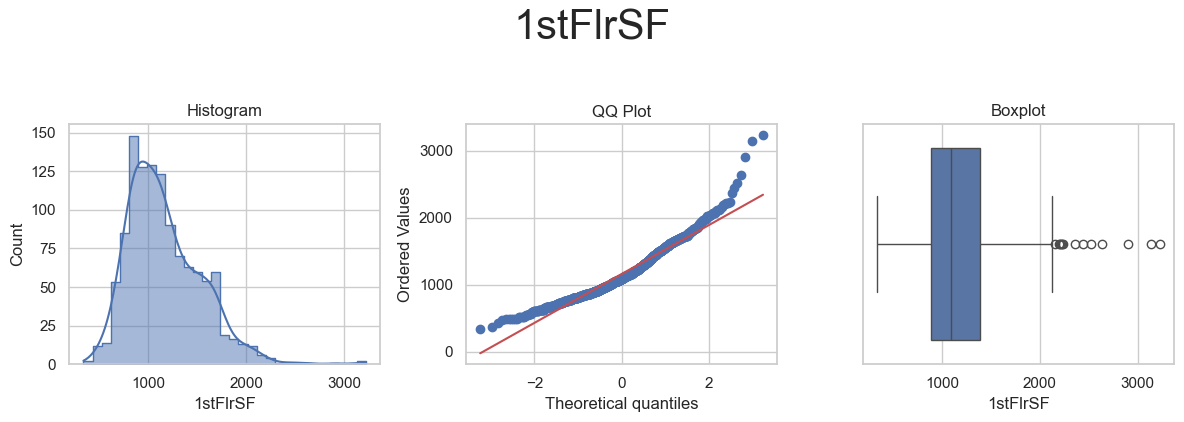

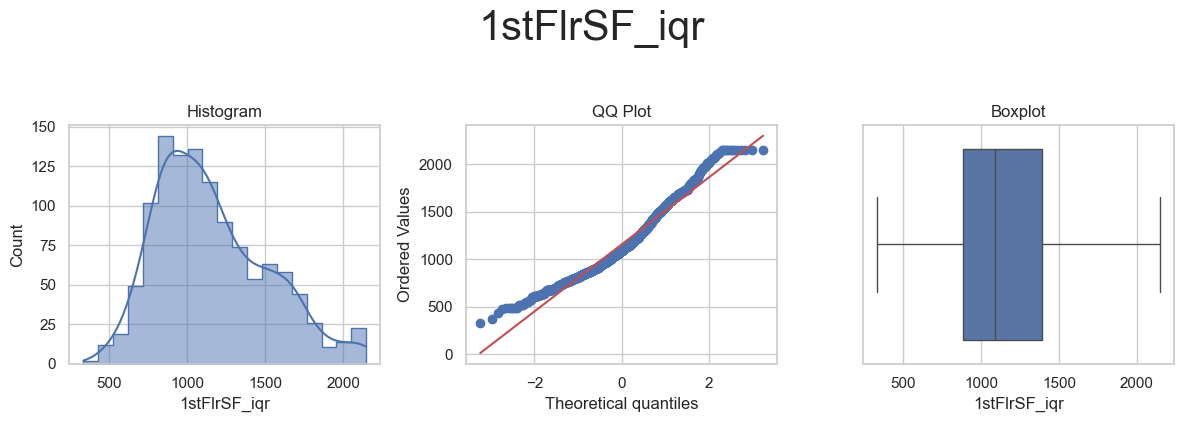



* Variable Analyzed: 2ndFlrSF
* Applied transformation: ['2ndFlrSF_iqr'] 



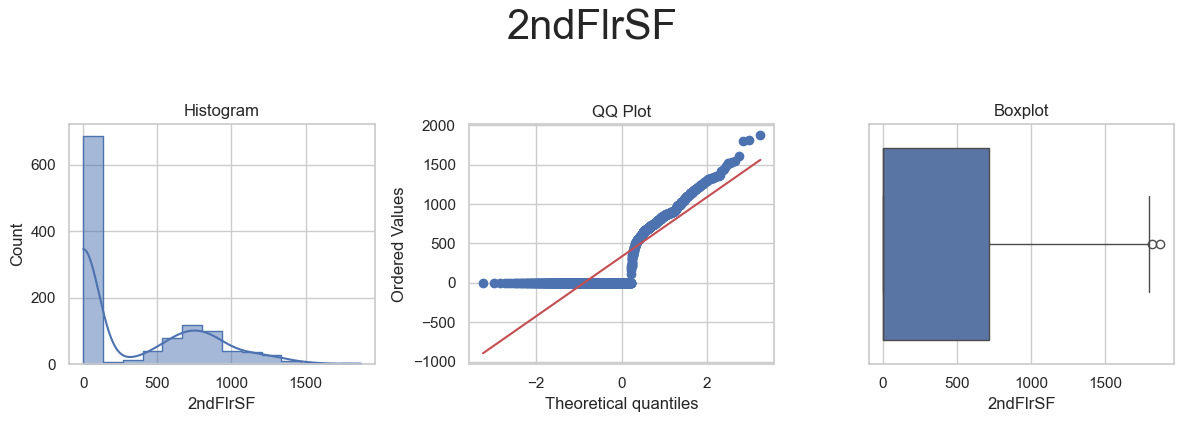

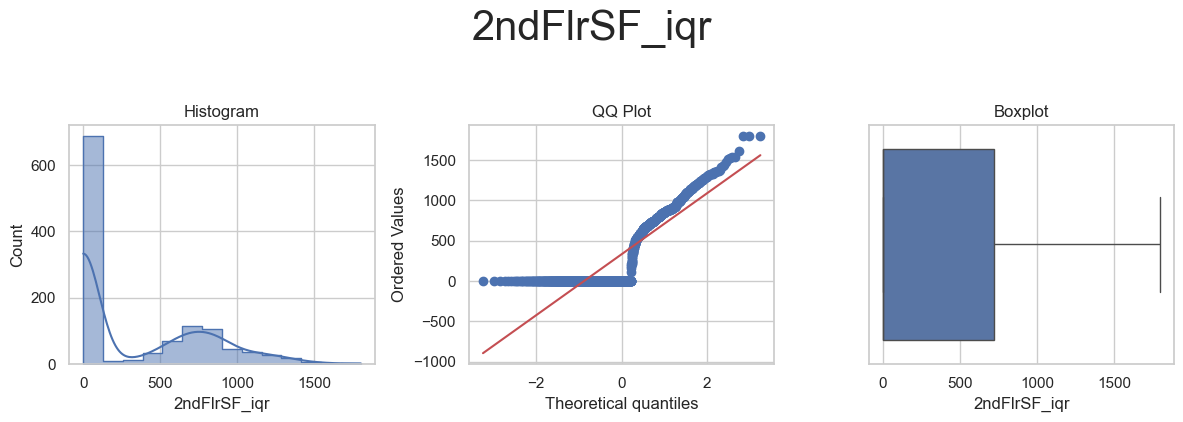



* Variable Analyzed: BsmtFinSF1
* Applied transformation: ['BsmtFinSF1_iqr'] 



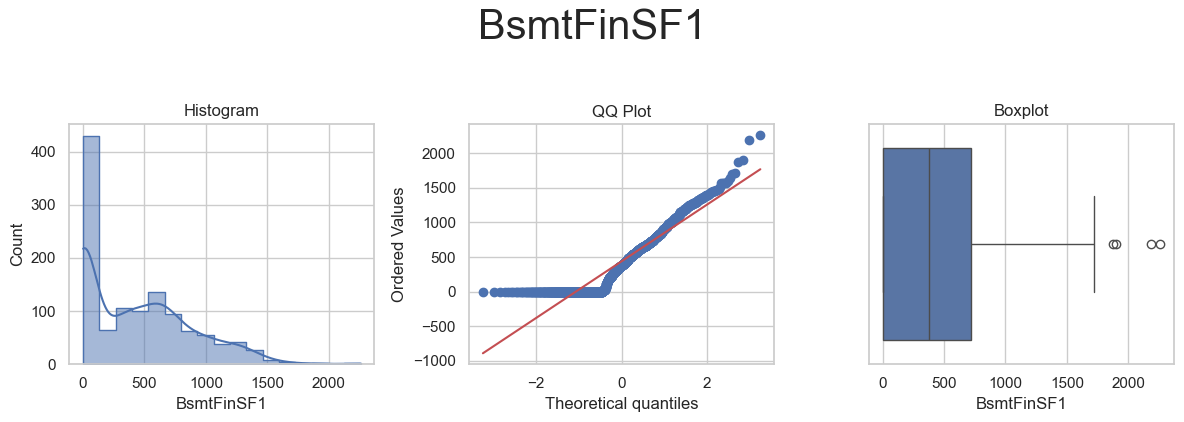

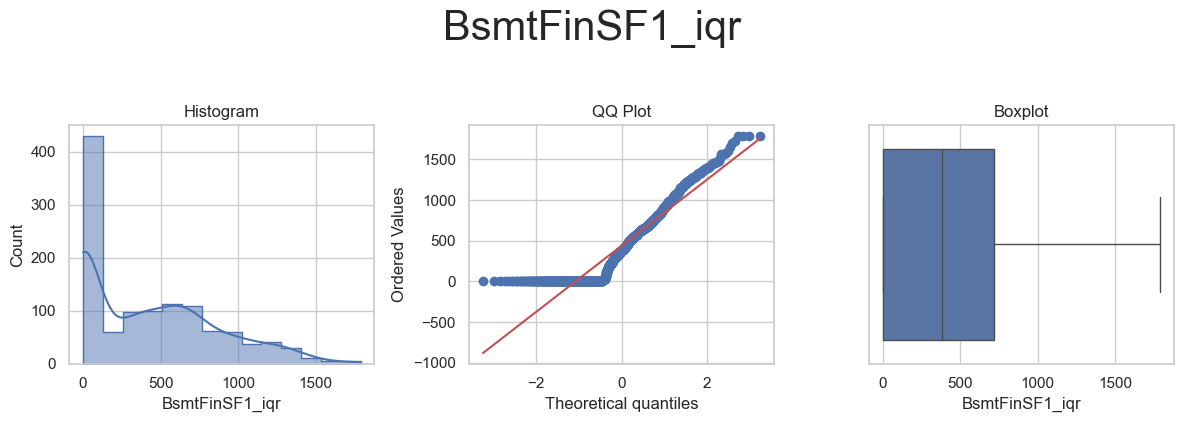



* Variable Analyzed: BsmtUnfSF
* Applied transformation: ['BsmtUnfSF_iqr'] 



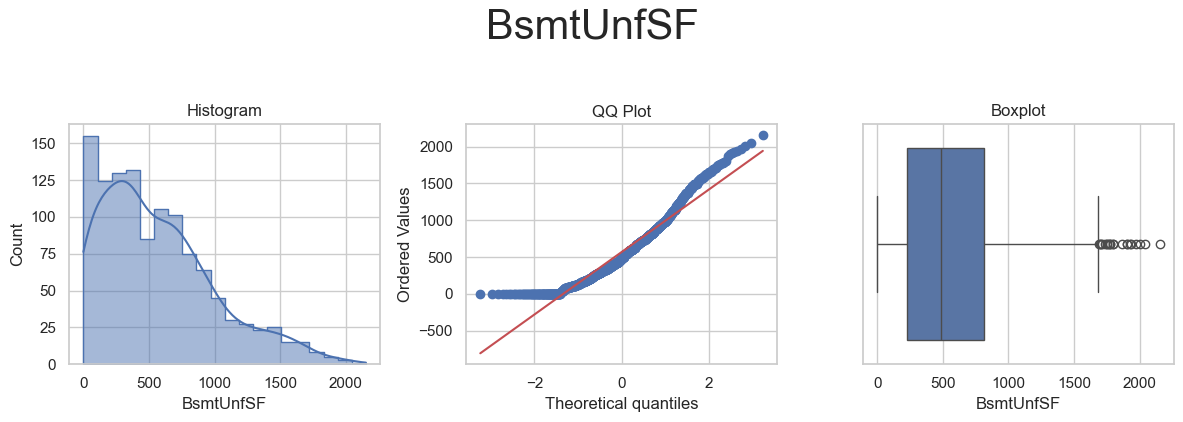

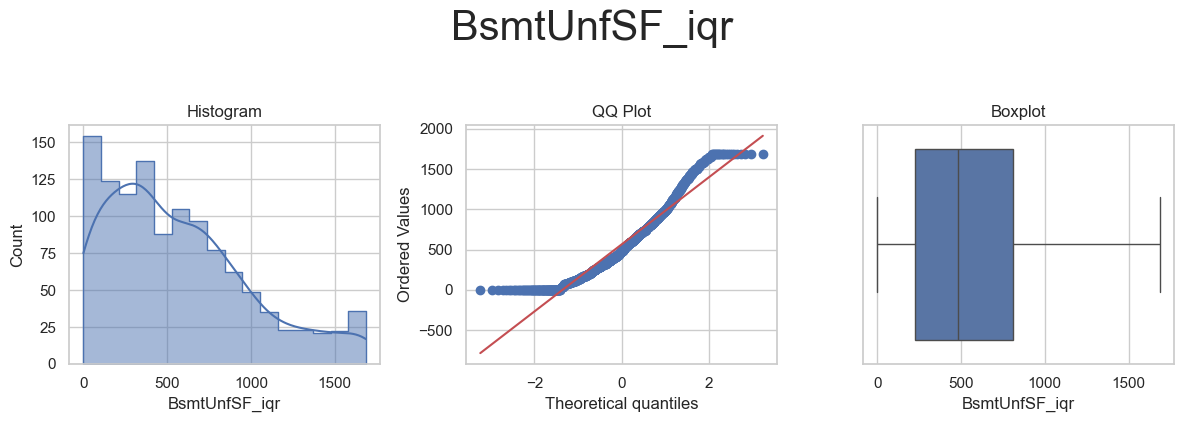



* Variable Analyzed: GarageYrBlt
* Applied transformation: ['GarageYrBlt_iqr'] 



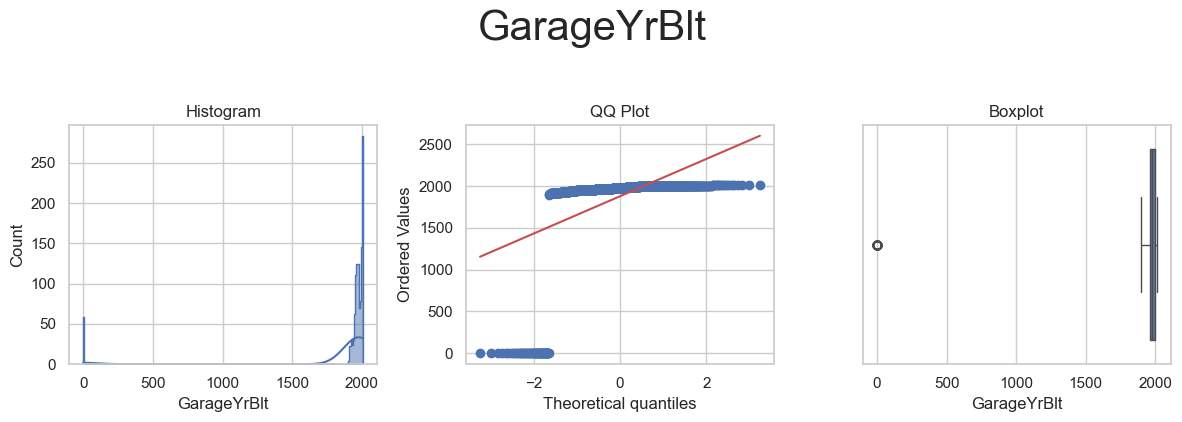

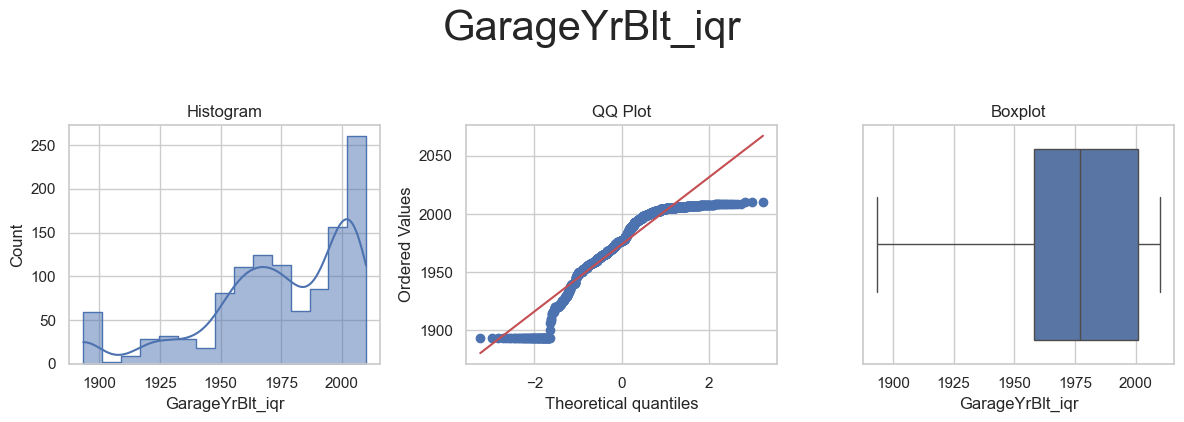



* Variable Analyzed: GrLivArea
* Applied transformation: ['GrLivArea_iqr'] 



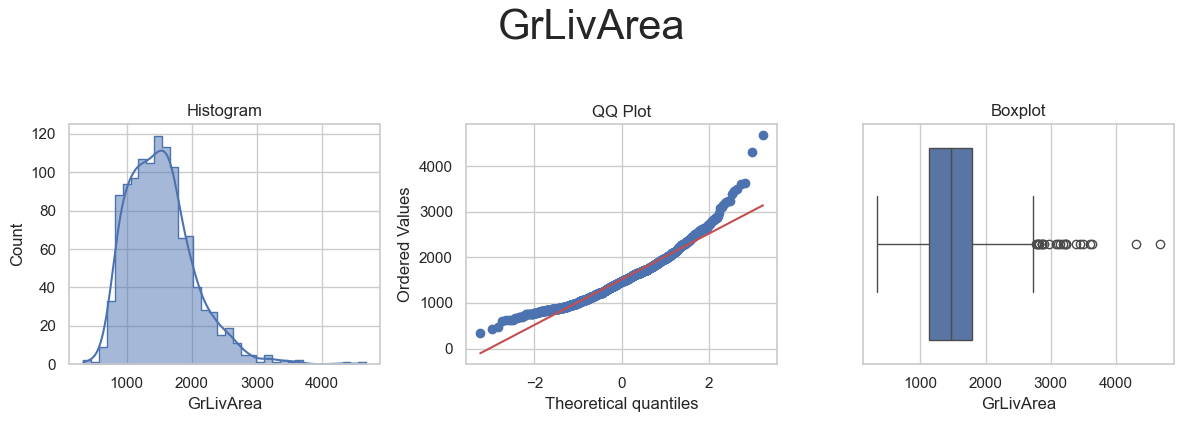

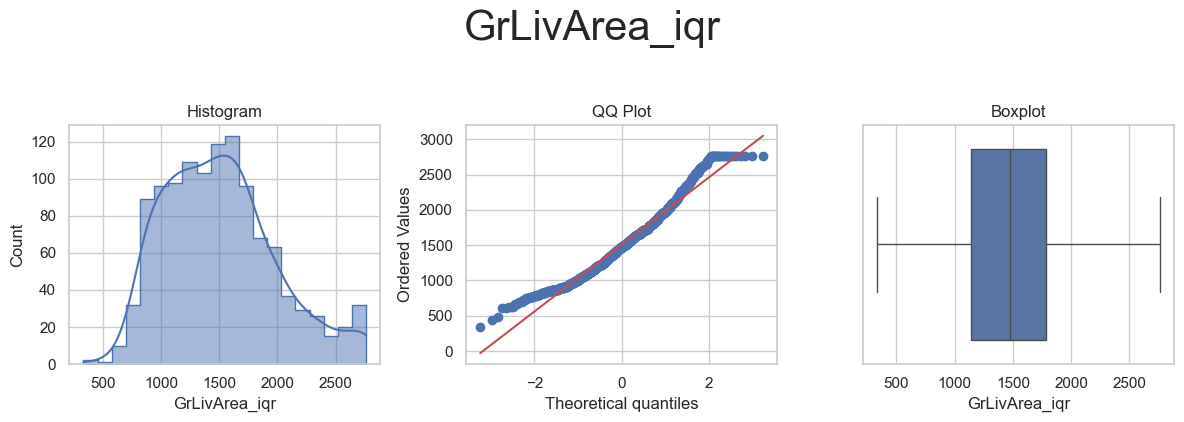



* Variable Analyzed: LotArea
* Applied transformation: ['LotArea_iqr'] 



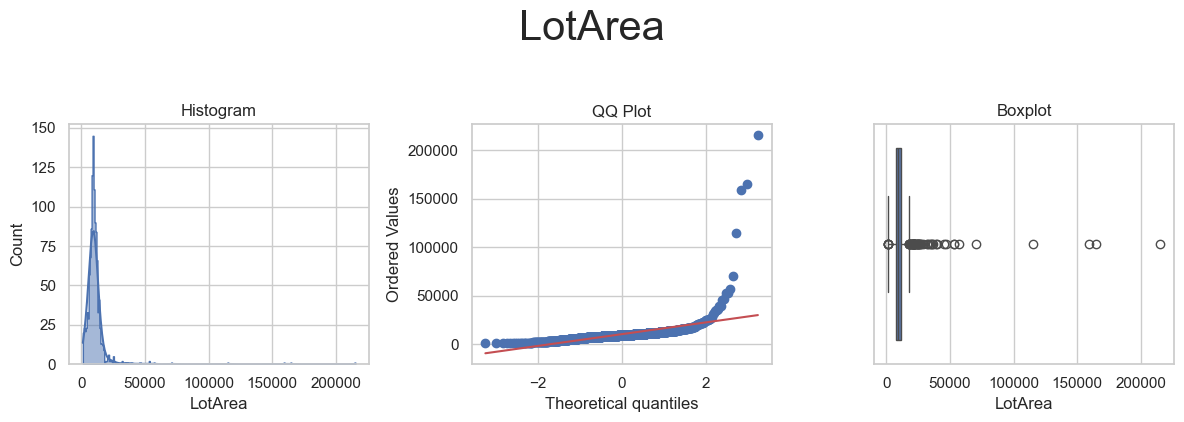

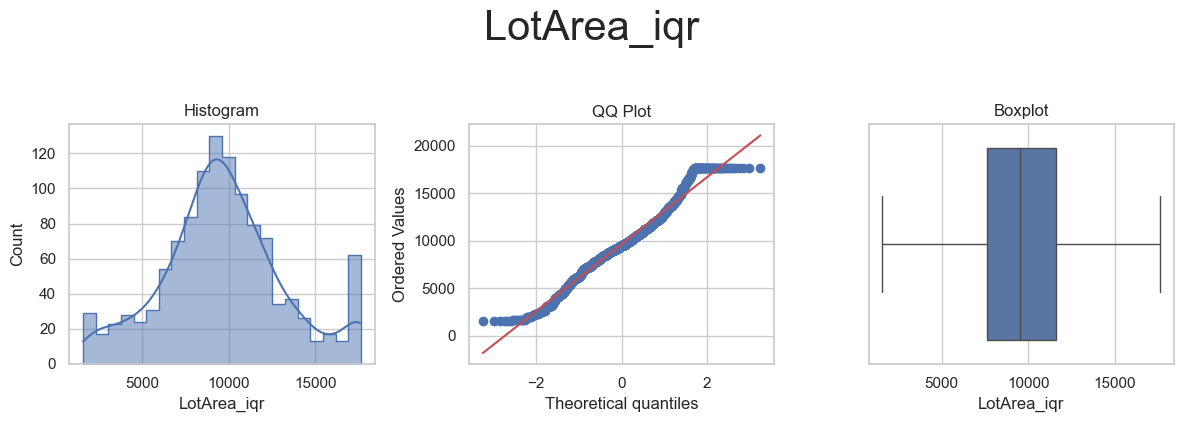



* Variable Analyzed: LotFrontage
* Applied transformation: ['LotFrontage_iqr'] 



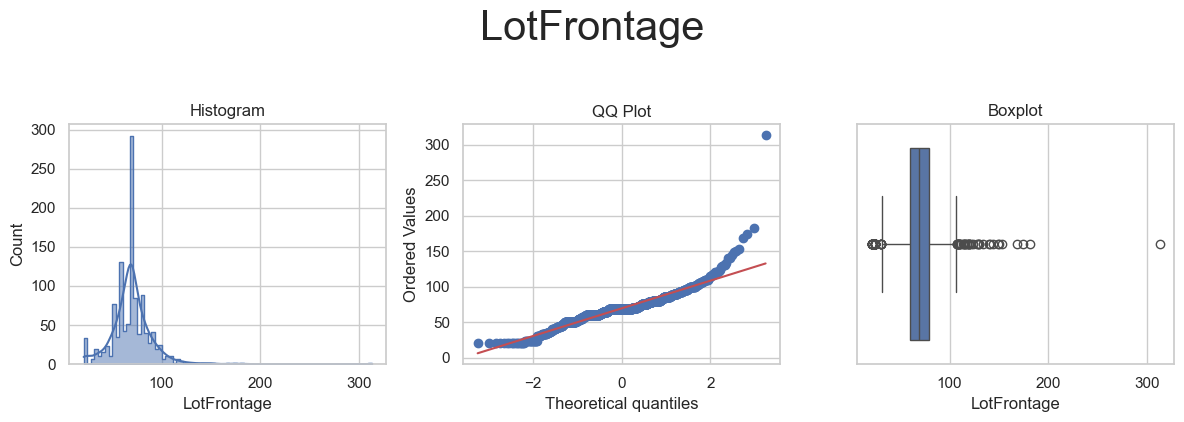

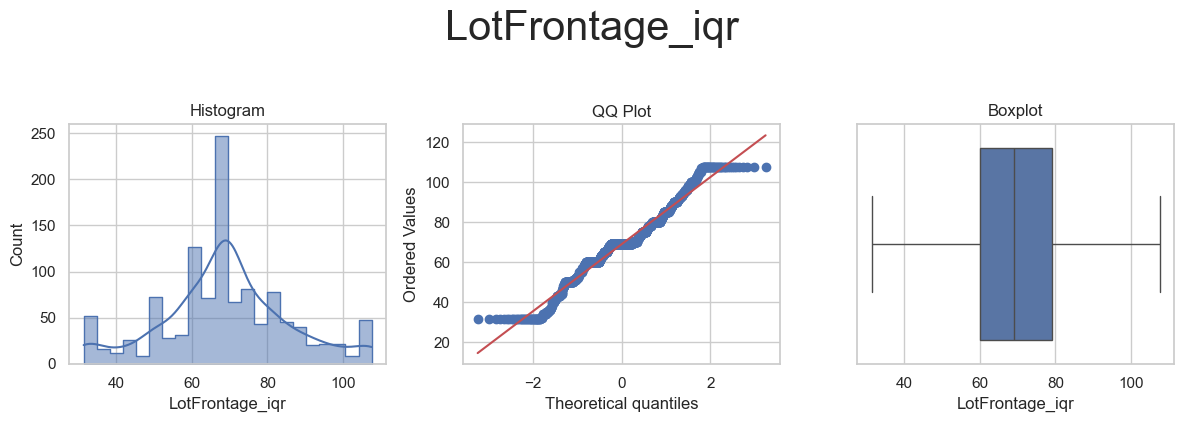



* Variable Analyzed: OverallCond
* Applied transformation: ['OverallCond_iqr'] 



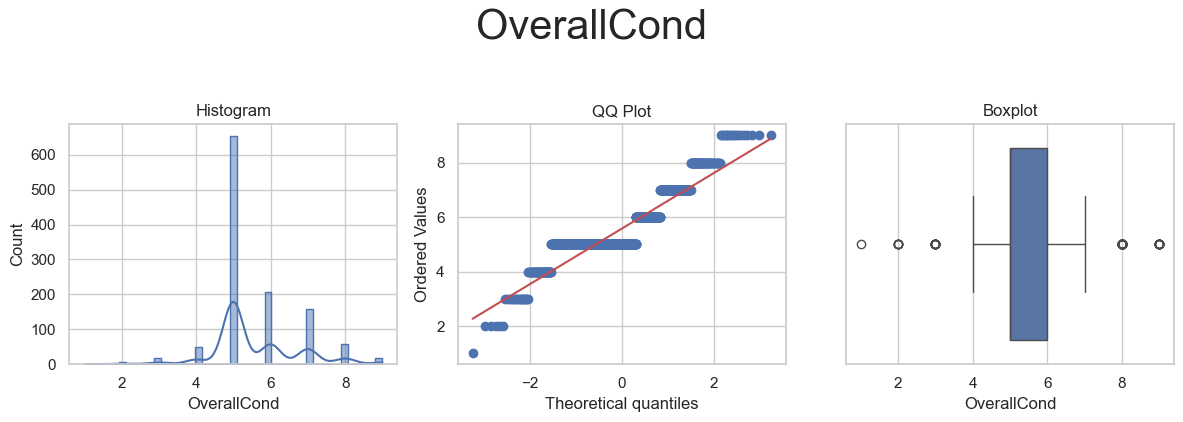

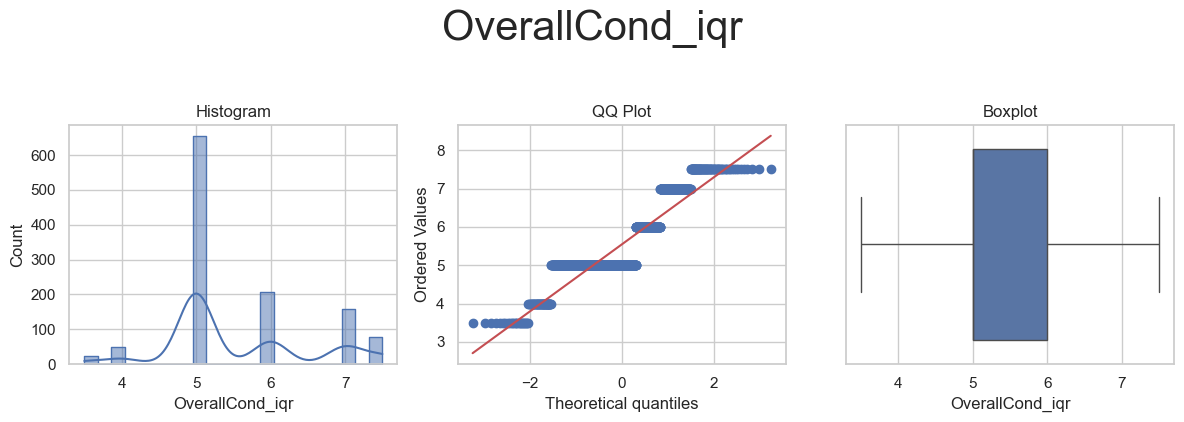



* Variable Analyzed: TotalBsmtSF
* Applied transformation: ['TotalBsmtSF_iqr'] 



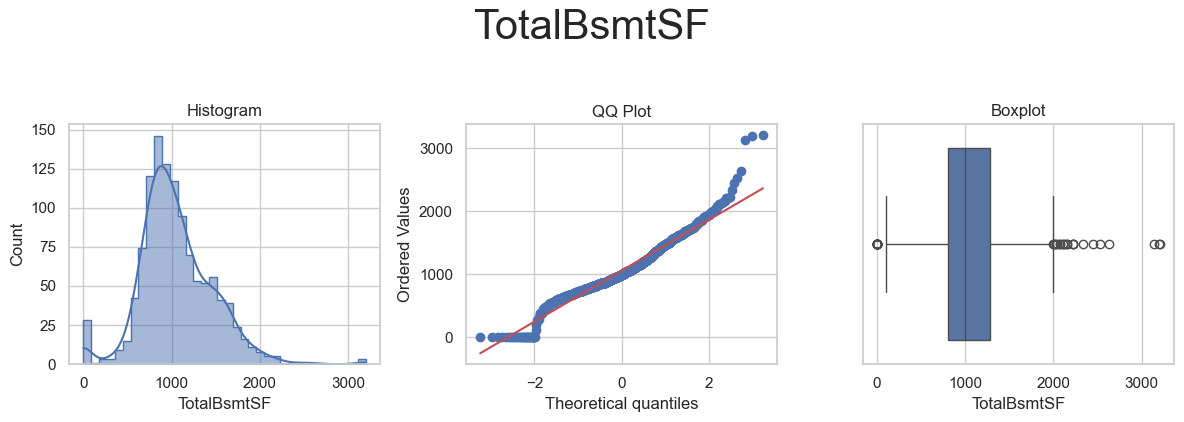

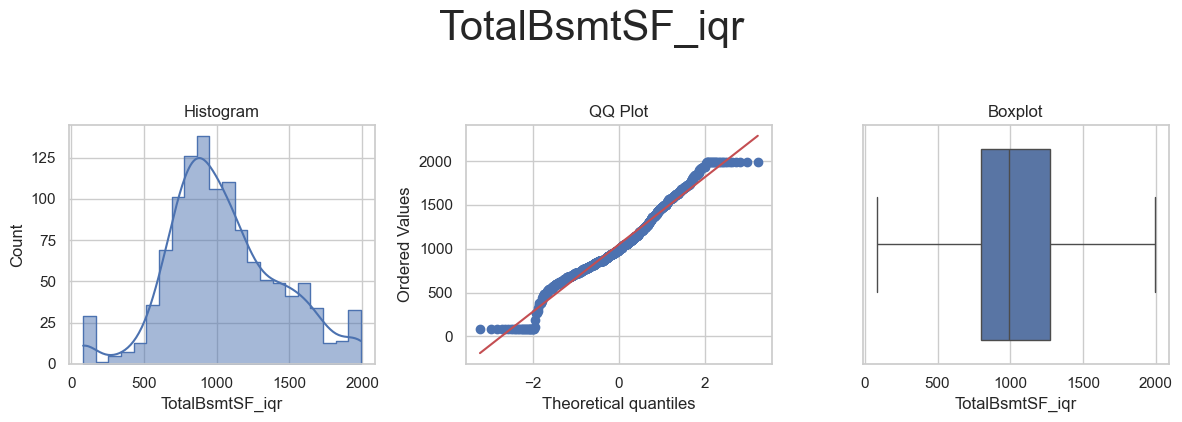



* Variable Analyzed: YearBuilt
* Applied transformation: ['YearBuilt_iqr'] 



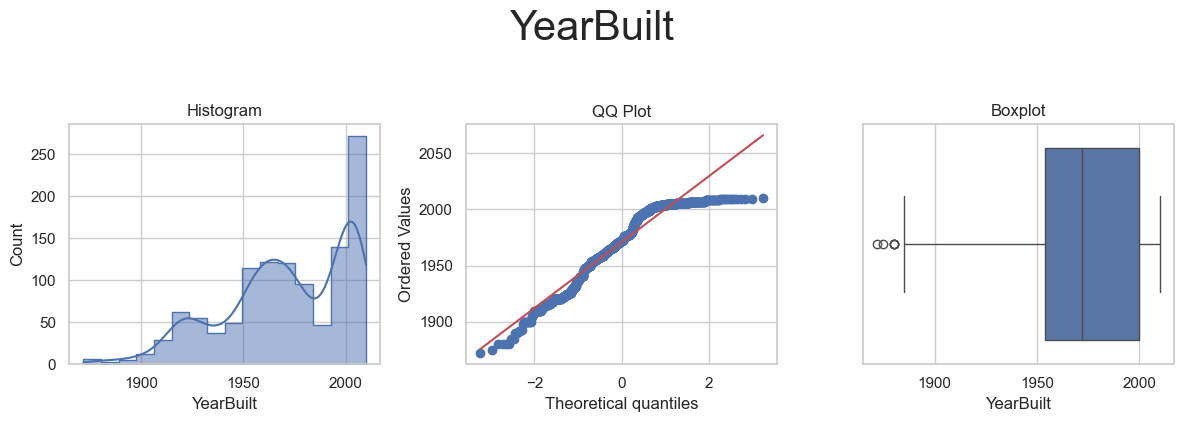

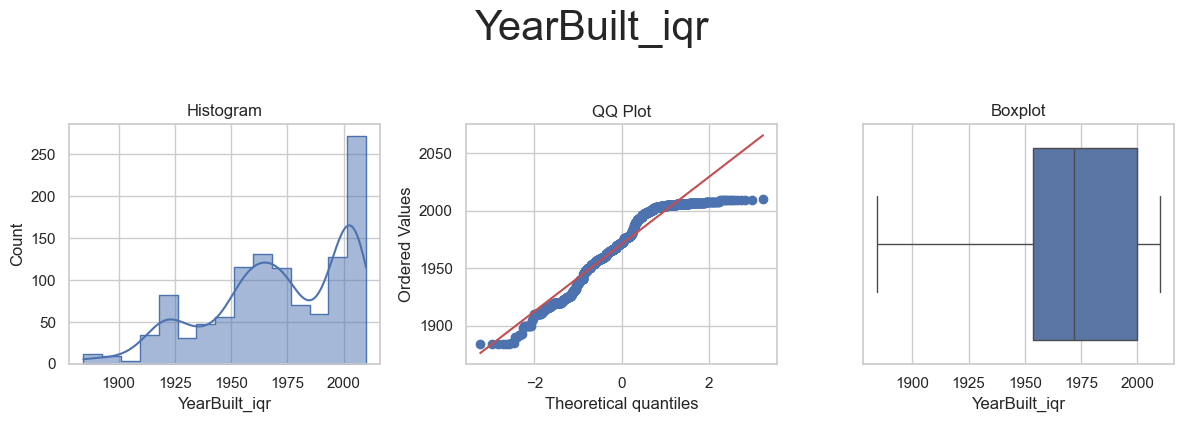

In [24]:
%matplotlib inline
df_engineering = FeatureEngineeringAnalysis(df=df_engineering,
                                            analysis_type='outlier_winsorizer')


Winsorization improved the distribution of all the features above by reducing the impact of outliers and bringing the data closer to a normal distribution. However, the transformation had limited effect on OverallCond, likely because it is an ordinal feature.

* Step 4 - Apply the selected transformation to the Train and Test set

In [25]:
variables_winsor = ['1stFlrSF', '2ndFlrSF', 'BsmtFinSF1',
                    'BsmtUnfSF', 'GarageYrBlt', 'GrLivArea',
                    'LotArea', 'LotFrontage',
                    'TotalBsmtSF', 'YearBuilt']
# the steps are:
# 1 - create a transformer
# 2 - fit_transform into TrainSet
# 3 - transform into TestSet
winsor = Winsorizer(
            capping_method='iqr', tail='both',
            fold=1.5, variables=variables_winsor)
TrainSet = winsor.fit_transform(TrainSet)
TestSet = winsor.transform(TestSet)

print("* Winsorization (IQR-based) completed!")


* Winsorization (IQR-based) completed!


### Numerical Transformation

**Numerical Transformation: ['1stFlrSF', '2ndFlrSF', 'BedroomAbvGr', 'BsmtFinSE1', 'BsmtUnfSF', 'GarageArea', 'GarageYrBlt', 'GrLivArea', 'LotArea', 'LotFrontage', 'OverallCond', 'OverallQual', 'TotalBsmtSF', 'YearBlt', 'YearRemodAdd']**

* Step 1: Select variable(s)

In [26]:
variables_engineering = ['1stFlrSF', '2ndFlrSF', 'BedroomAbvGr',
                         'BsmtFinSF1', 'BsmtUnfSF', 'GarageArea',
                         'GarageYrBlt', 'GrLivArea', 'LotArea',
                         'LotFrontage', 'OverallCond', 'OverallQual',
                         'TotalBsmtSF', 'YearBuilt', 'YearRemodAdd']
variables_engineering


['1stFlrSF',
 '2ndFlrSF',
 'BedroomAbvGr',
 'BsmtFinSF1',
 'BsmtUnfSF',
 'GarageArea',
 'GarageYrBlt',
 'GrLivArea',
 'LotArea',
 'LotFrontage',
 'OverallCond',
 'OverallQual',
 'TotalBsmtSF',
 'YearBuilt',
 'YearRemodAdd']

* Step 2: Create a separate DataFrame, with your variable(s)

In [27]:
df_engineering = TrainSet[variables_engineering].copy()
df_engineering.head(3)


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtFinSF1,BsmtUnfSF,GarageArea,GarageYrBlt,GrLivArea,LotArea,LotFrontage,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd
0,1828.0,0.0,3.0,48,1686.125,774,2007.0,1828.0,11694.0,90.0,5,9,1822.0,2007.0,2007
1,894.0,0.0,2.0,0,894.000,308,1962.0,894.0,6600.0,60.0,5,5,894.0,1962.0,1962
2,964.0,0.0,2.0,713,163.000,432,1921.0,964.0,13360.0,80.0,7,5,876.0,1921.0,2006


* Step 3: Create engineered variables(s) by applying the transformation(s), assess engineered variables distribution and select the most suitable method

* Variable Analyzed: 1stFlrSF
* Applied transformation: ['1stFlrSF_log_e', '1stFlrSF_log_10', '1stFlrSF_reciprocal', '1stFlrSF_power', '1stFlrSF_box_cox', '1stFlrSF_yeo_johnson'] 



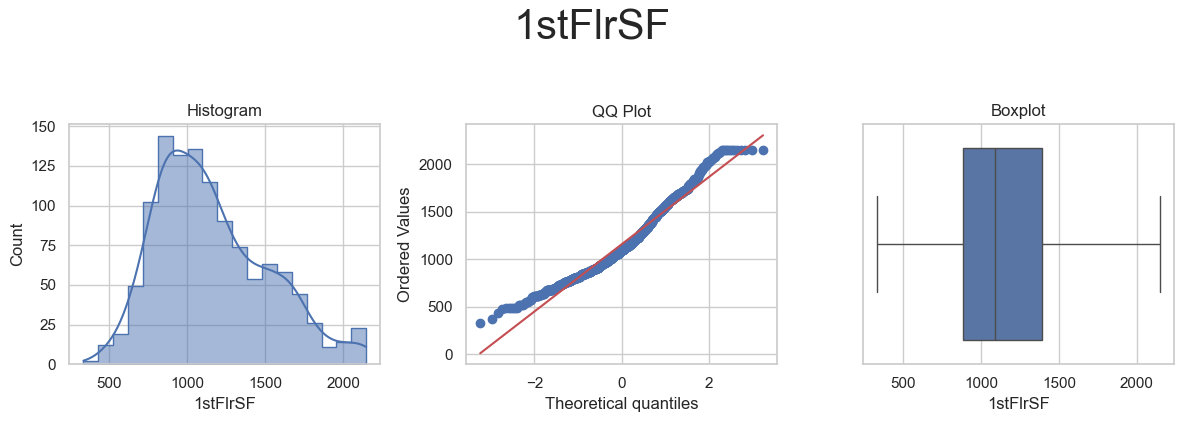

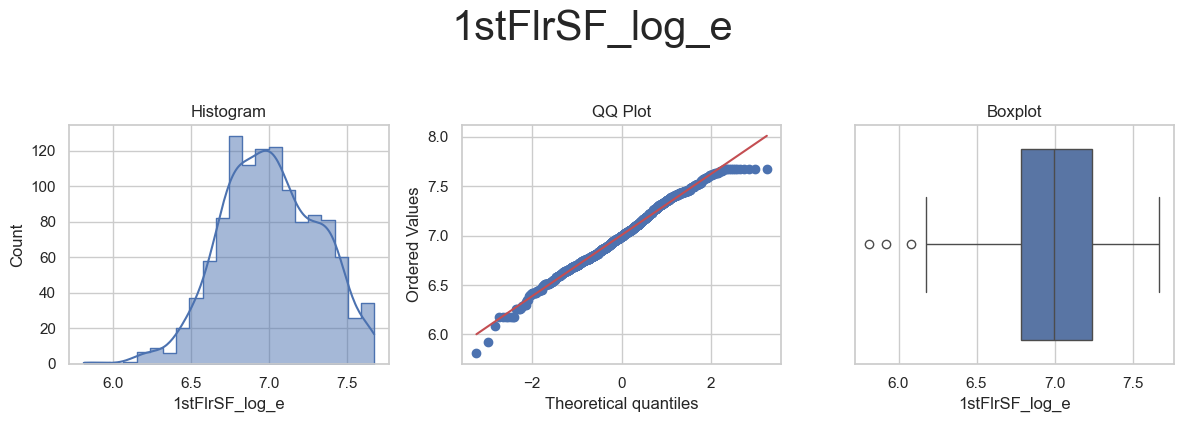

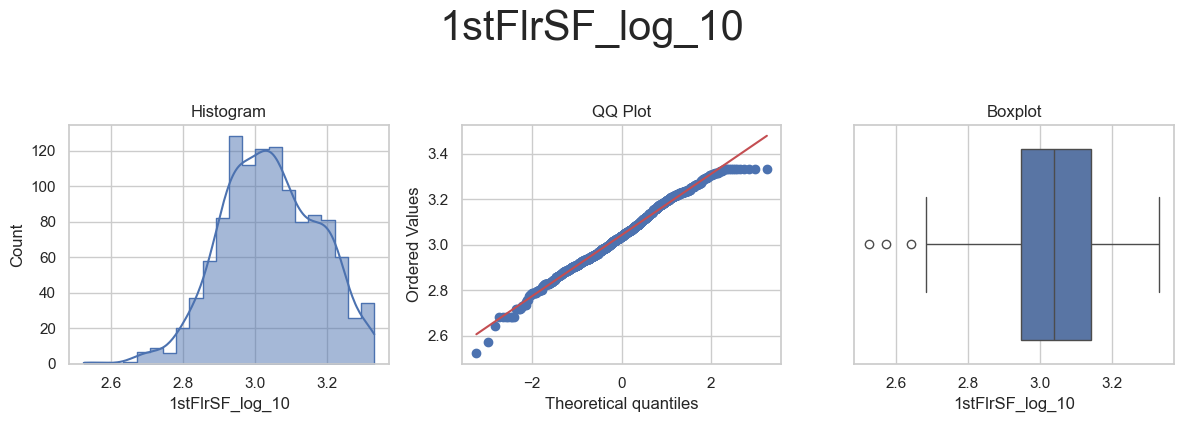

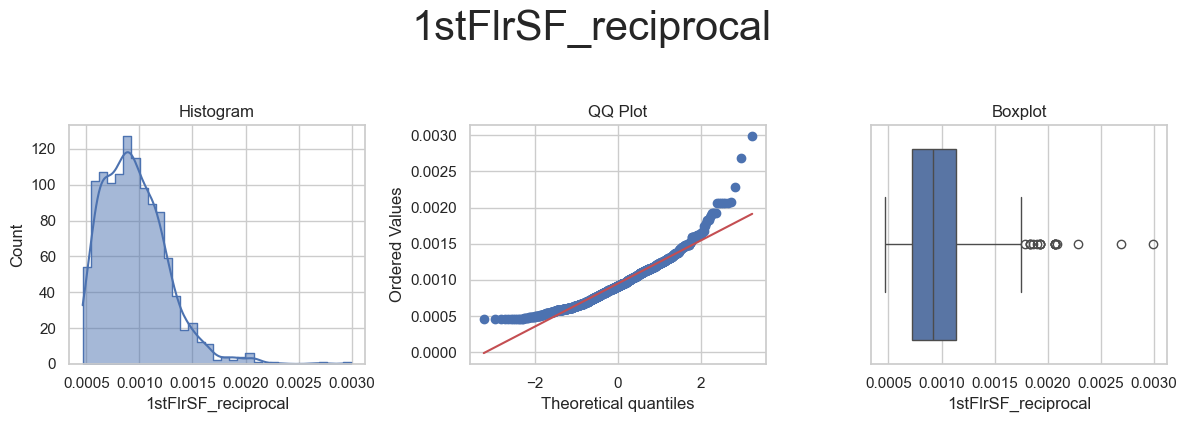

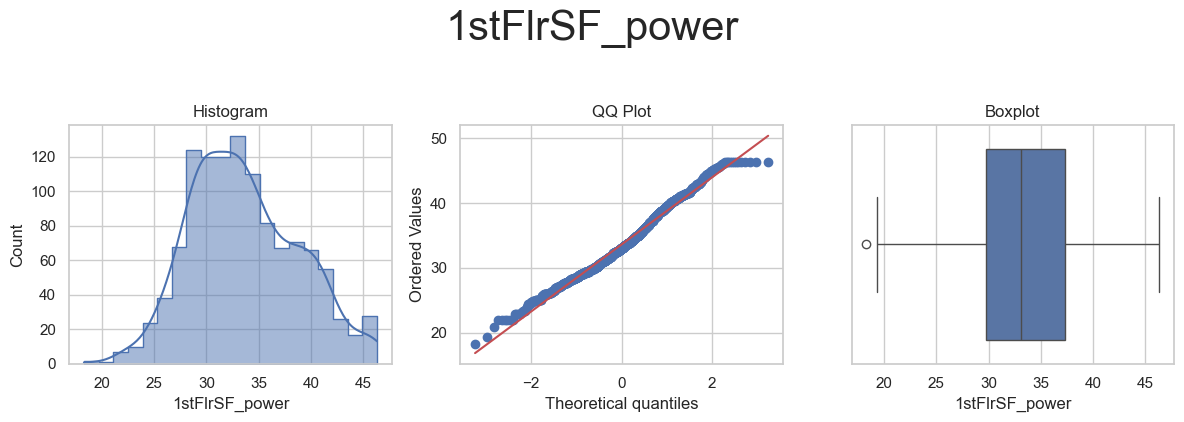

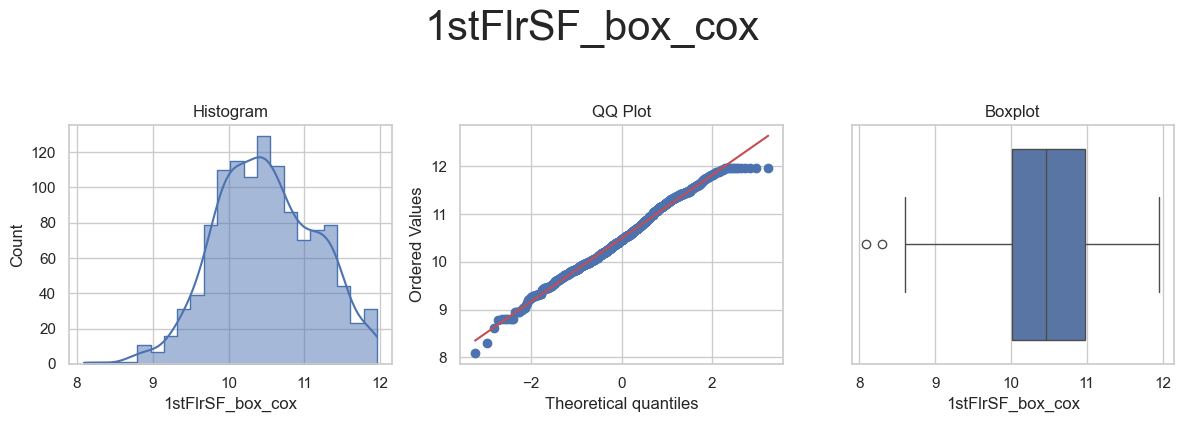

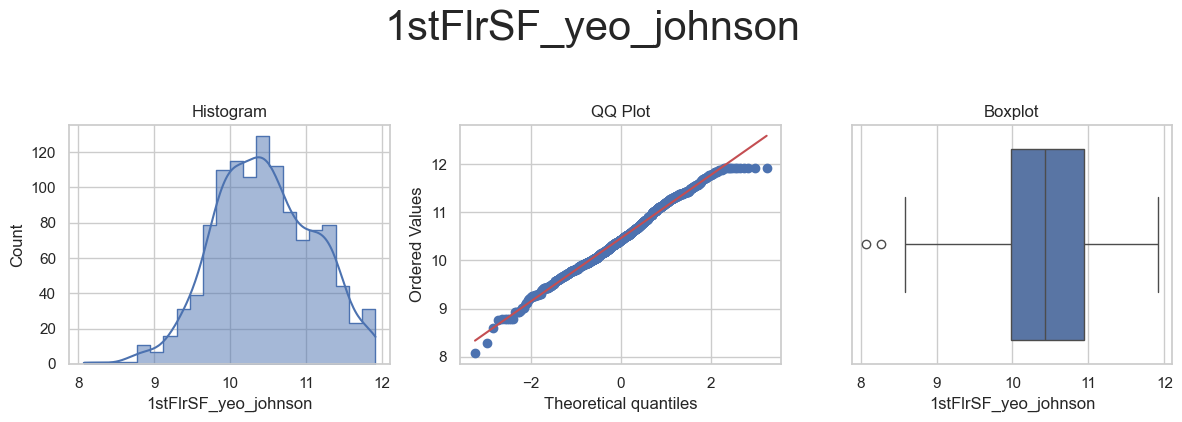



* Variable Analyzed: 2ndFlrSF
* Applied transformation: ['2ndFlrSF_power', '2ndFlrSF_yeo_johnson'] 



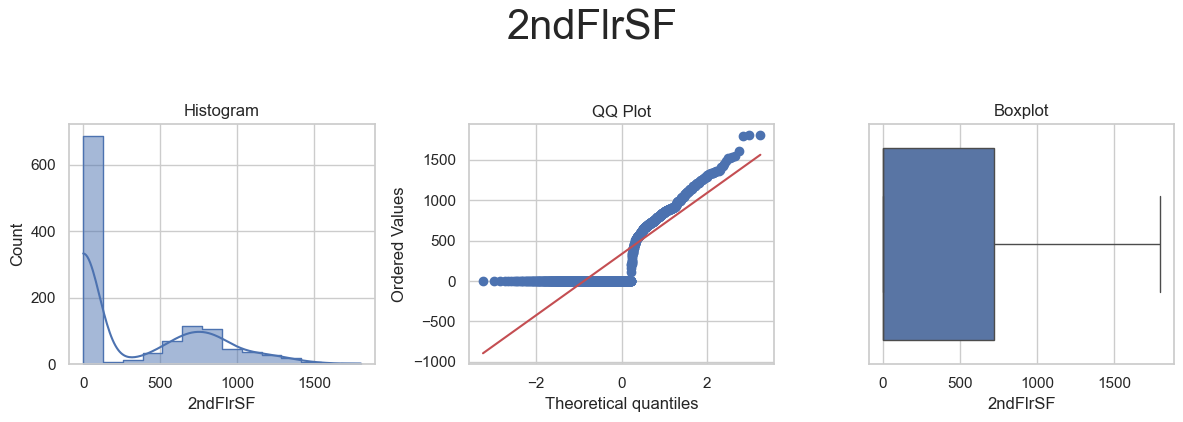

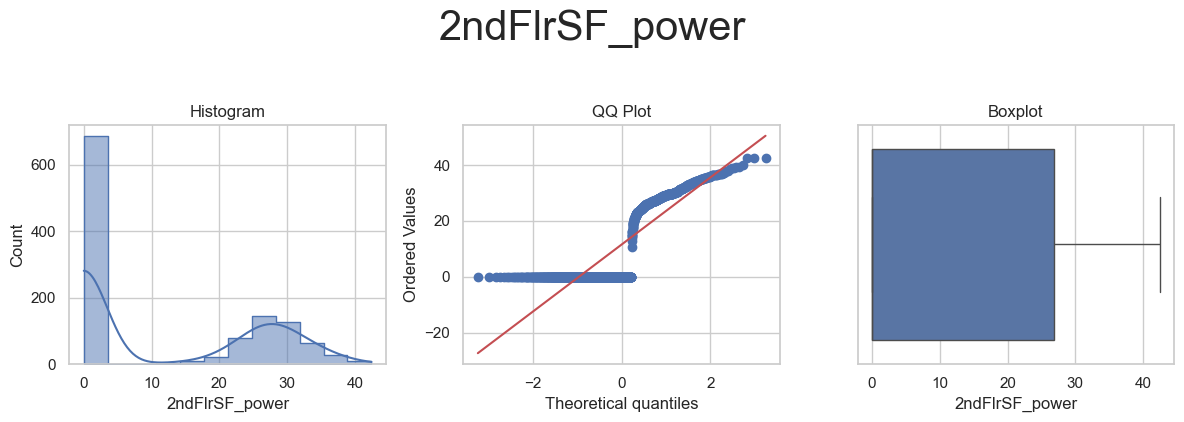

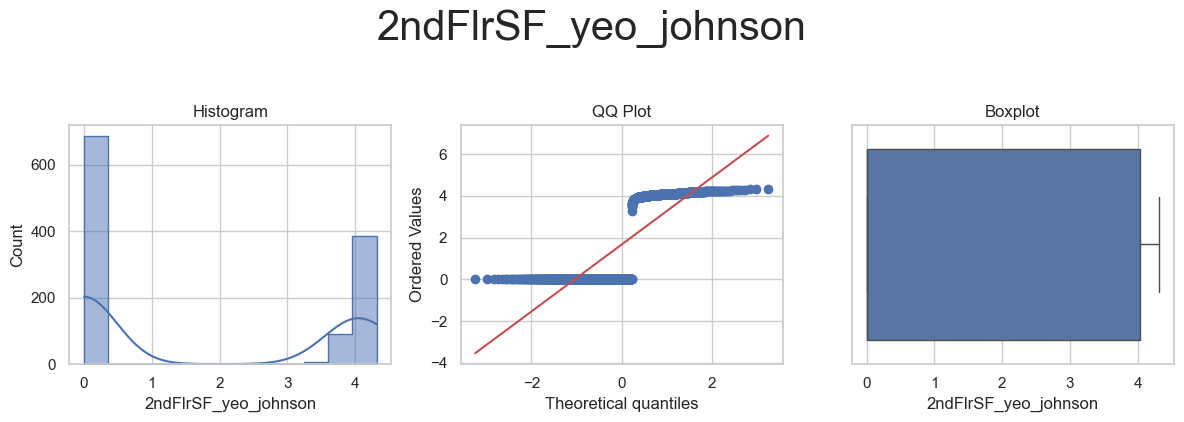



* Variable Analyzed: BedroomAbvGr
* Applied transformation: ['BedroomAbvGr_power', 'BedroomAbvGr_yeo_johnson'] 



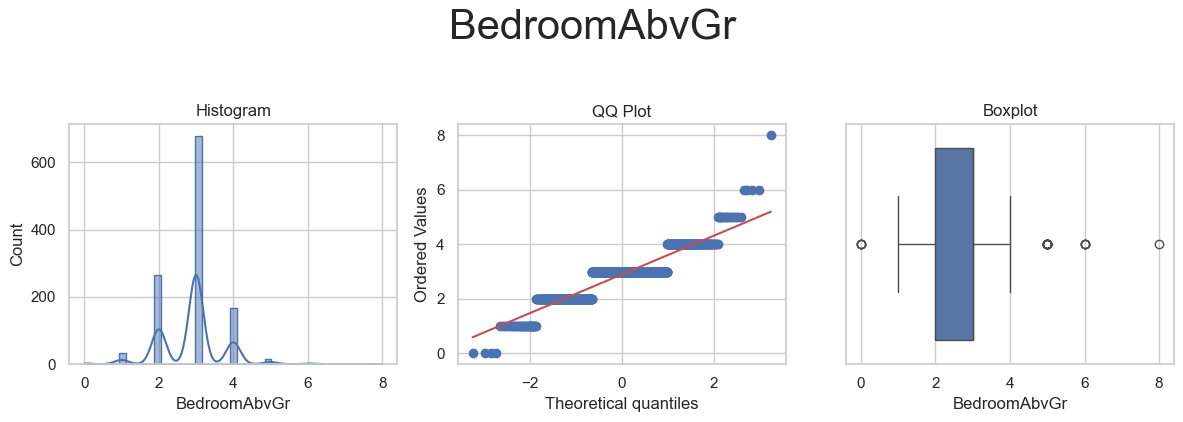

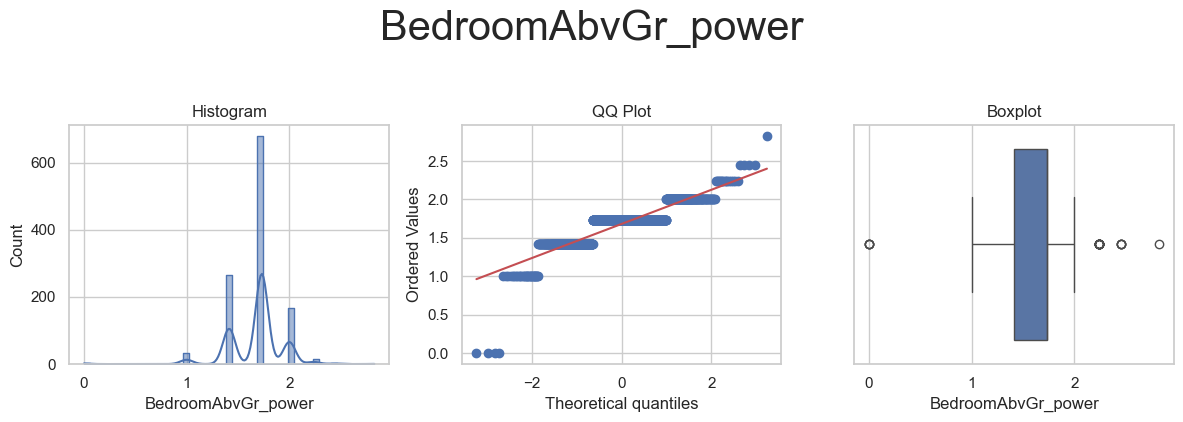

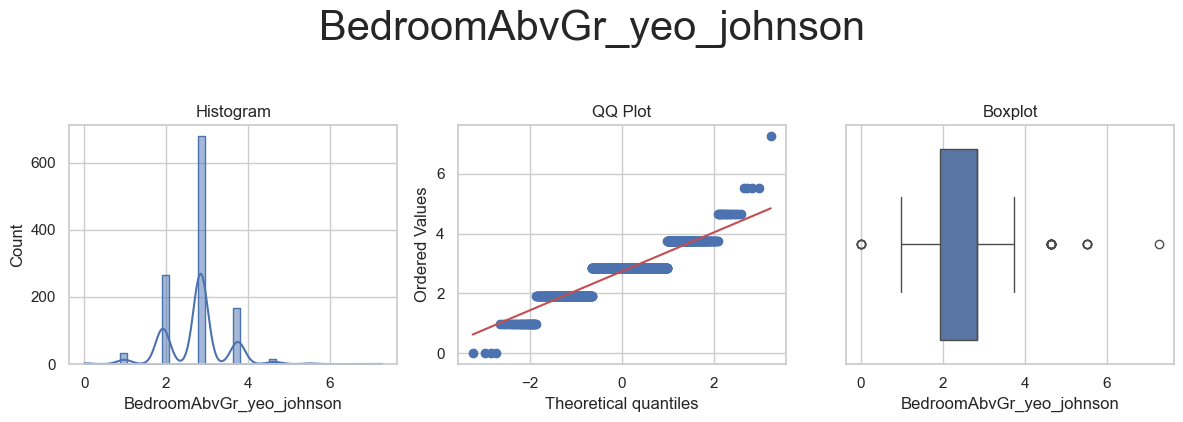



* Variable Analyzed: BsmtFinSF1
* Applied transformation: ['BsmtFinSF1_power', 'BsmtFinSF1_yeo_johnson'] 



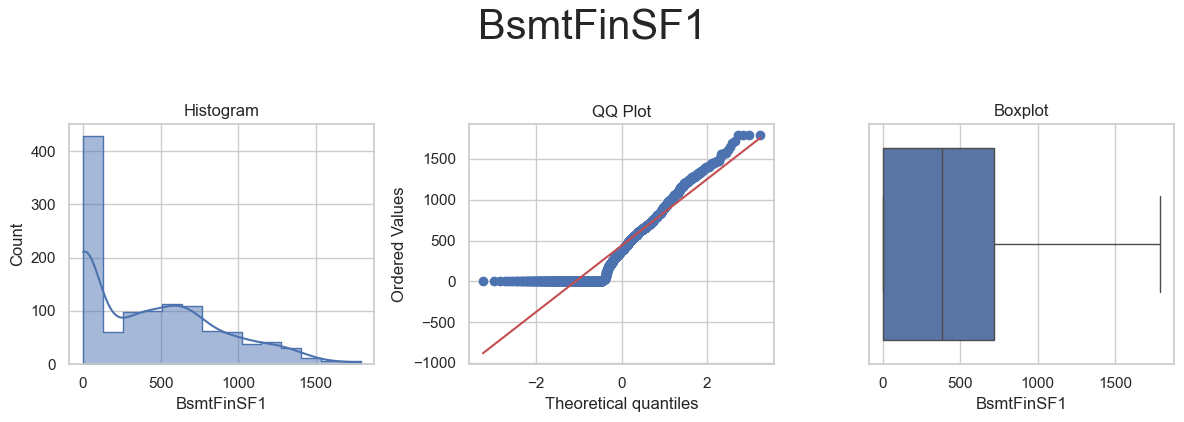

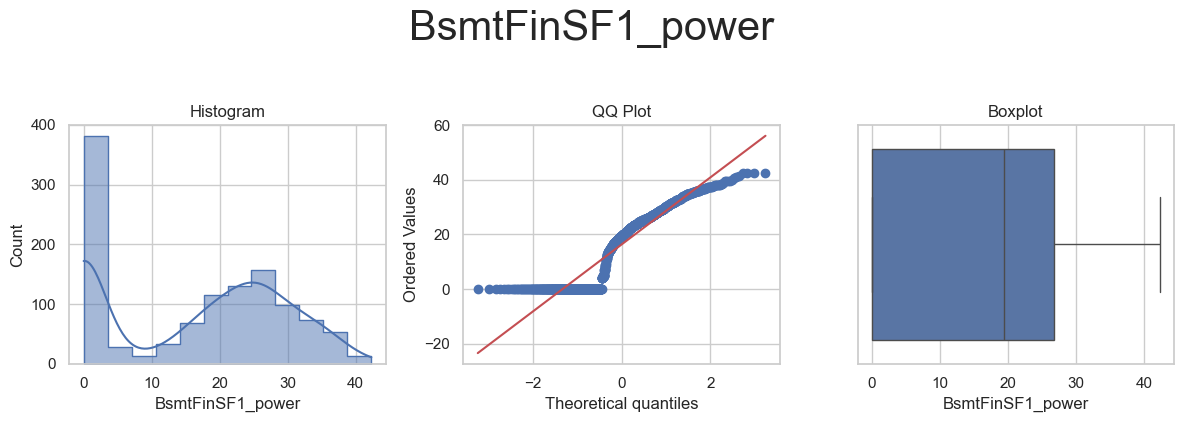

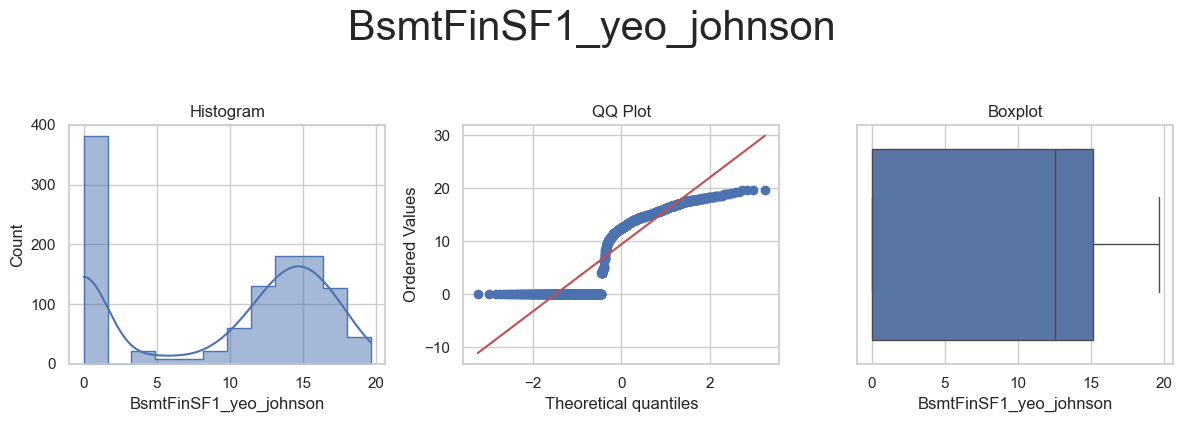



* Variable Analyzed: BsmtUnfSF
* Applied transformation: ['BsmtUnfSF_power', 'BsmtUnfSF_yeo_johnson'] 



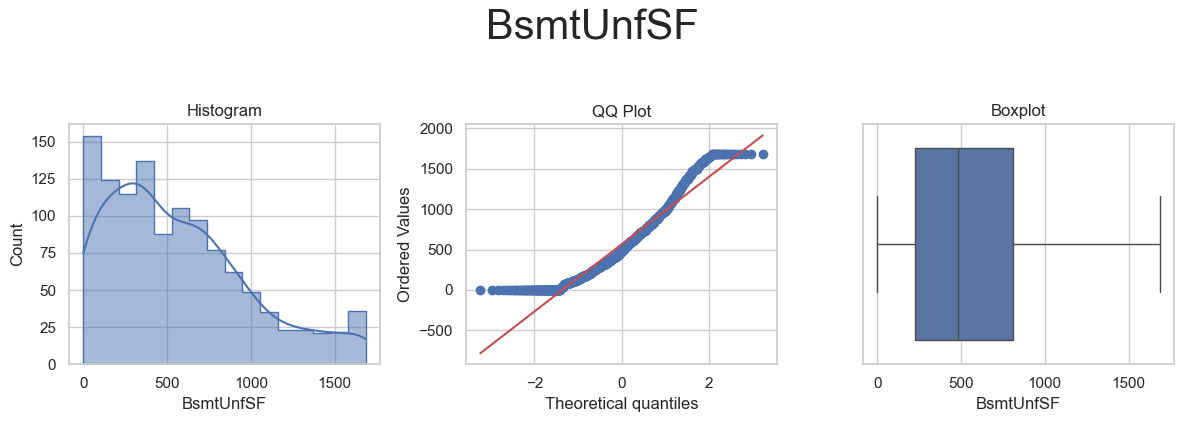

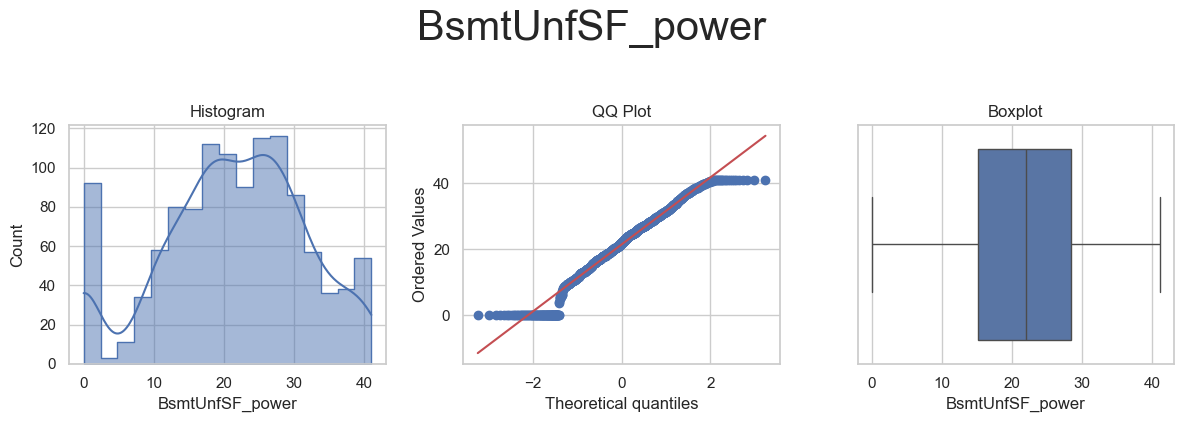

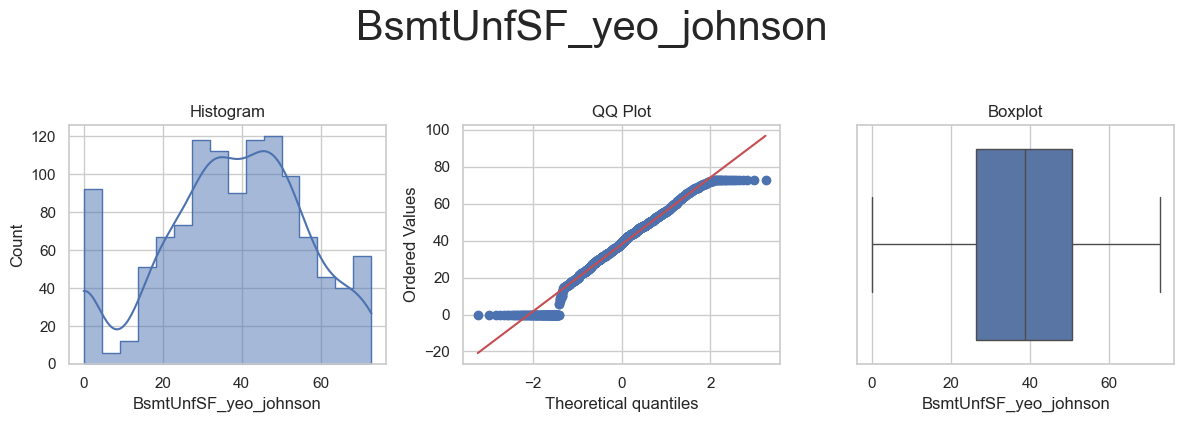



* Variable Analyzed: GarageArea
* Applied transformation: ['GarageArea_power', 'GarageArea_yeo_johnson'] 



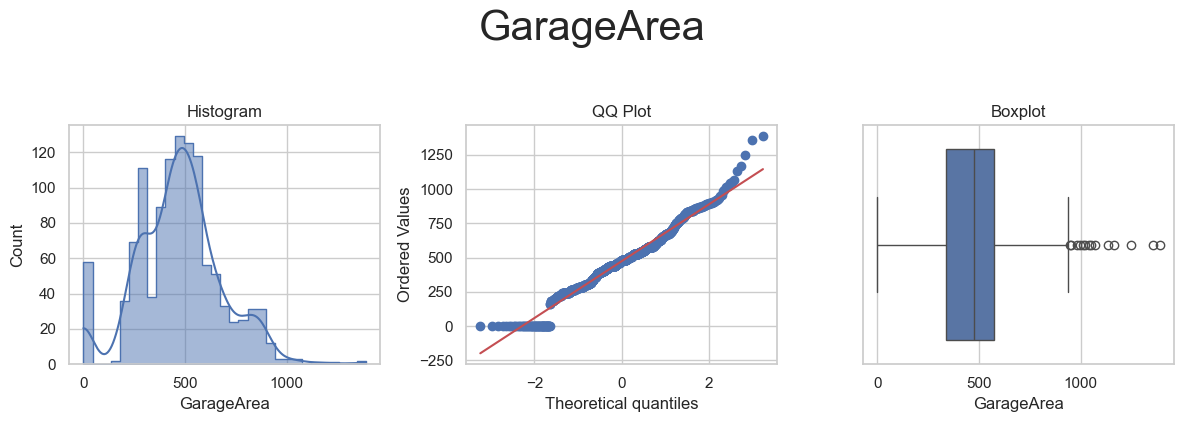

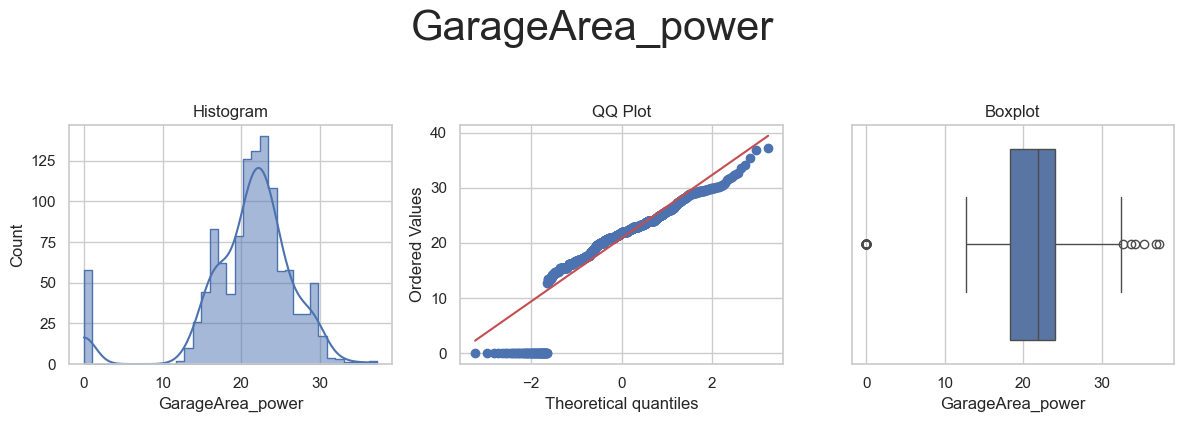

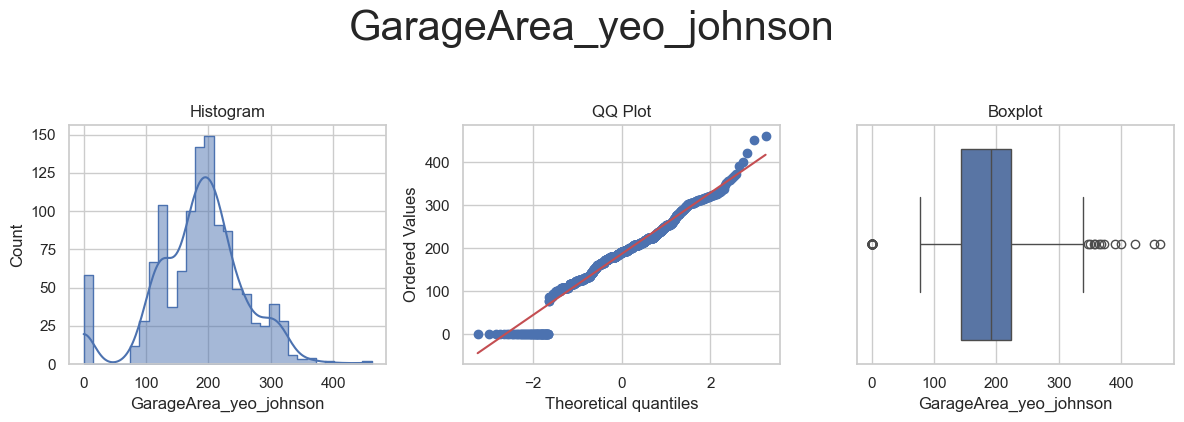



* Variable Analyzed: GarageYrBlt
* Applied transformation: ['GarageYrBlt_log_e', 'GarageYrBlt_log_10', 'GarageYrBlt_reciprocal', 'GarageYrBlt_power', 'GarageYrBlt_box_cox', 'GarageYrBlt_yeo_johnson'] 



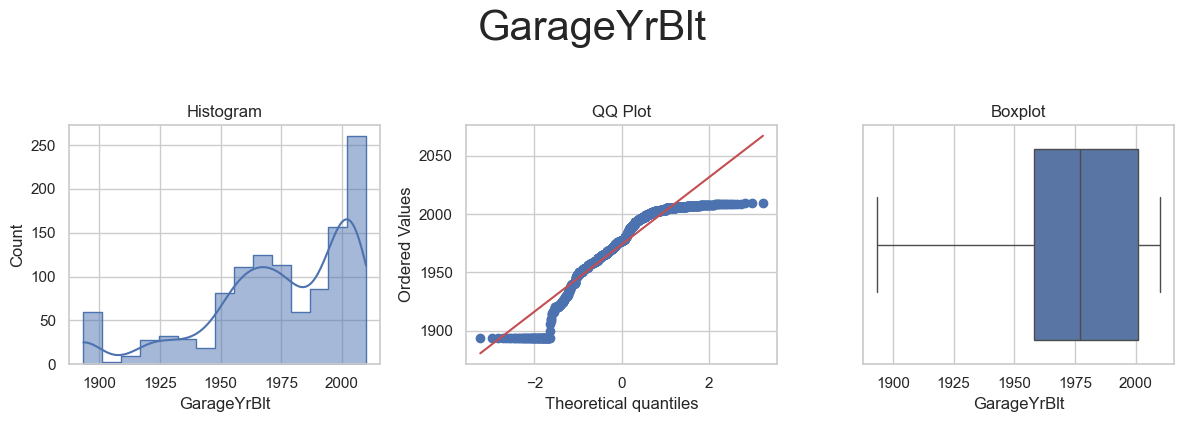

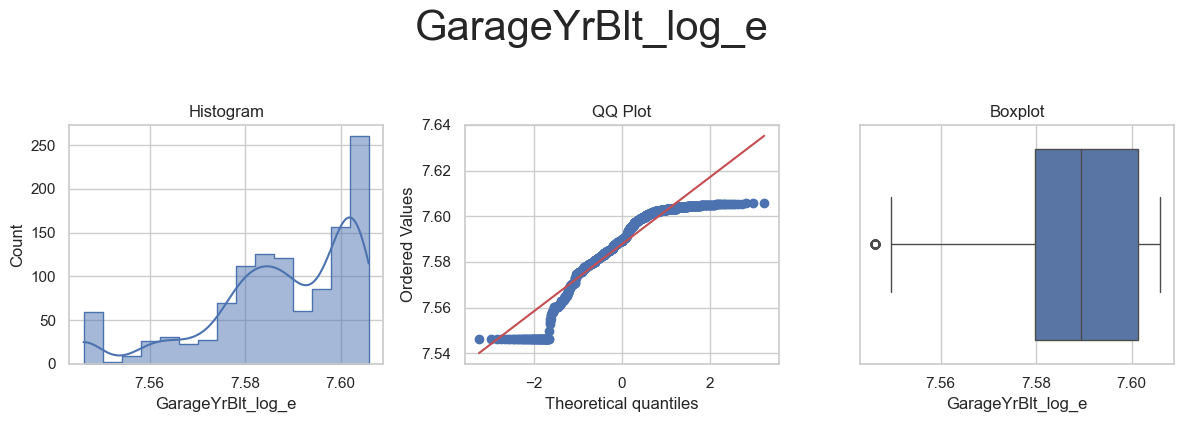

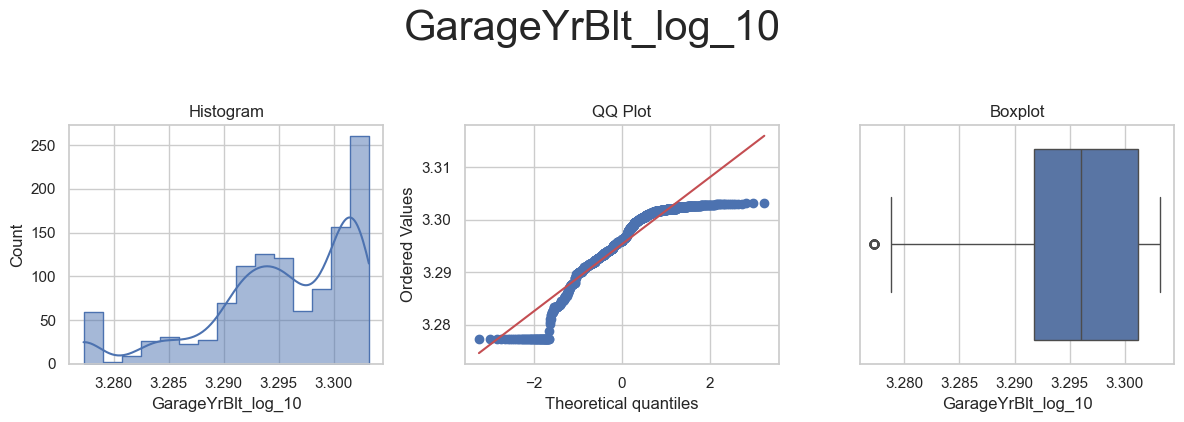

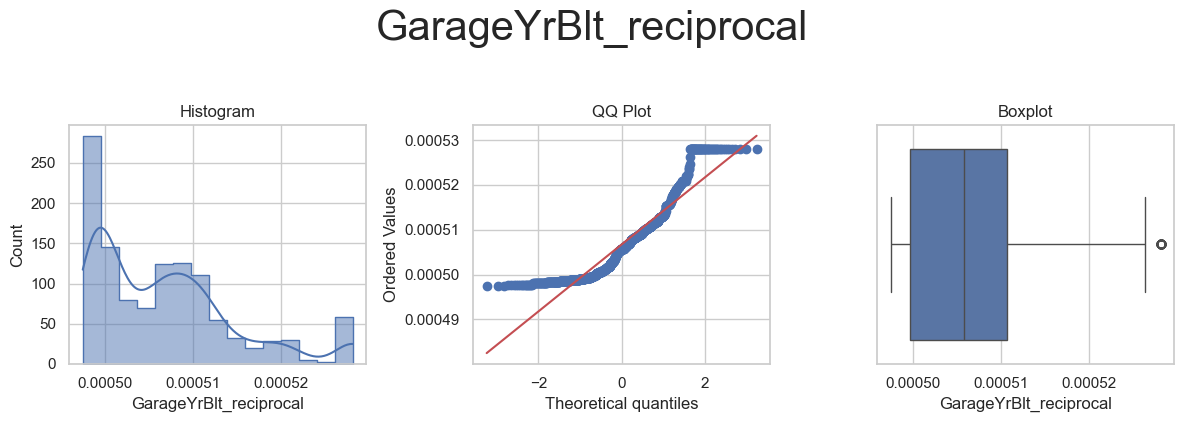

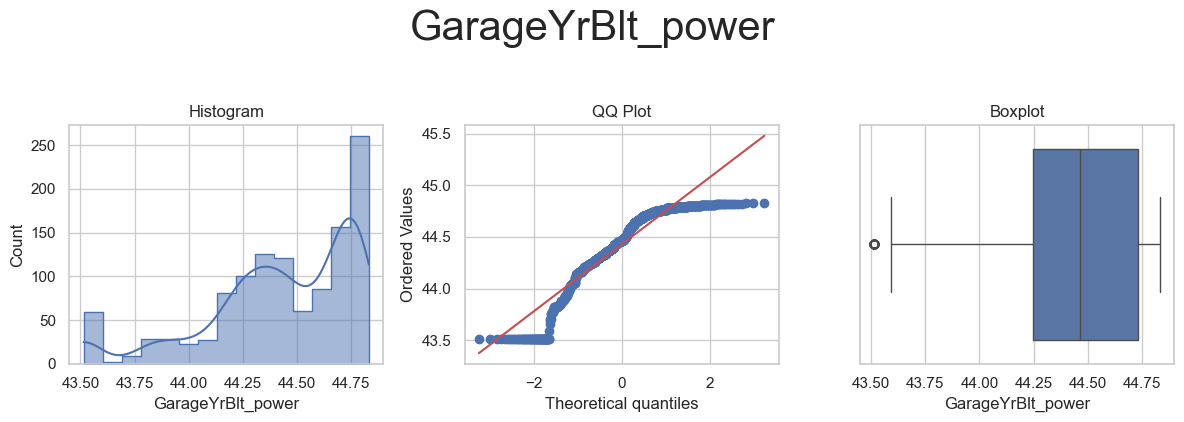

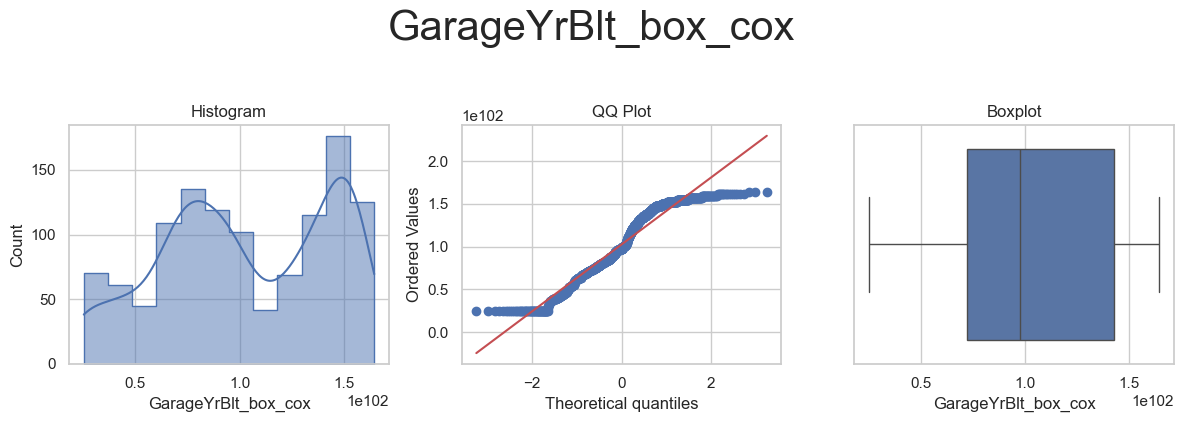

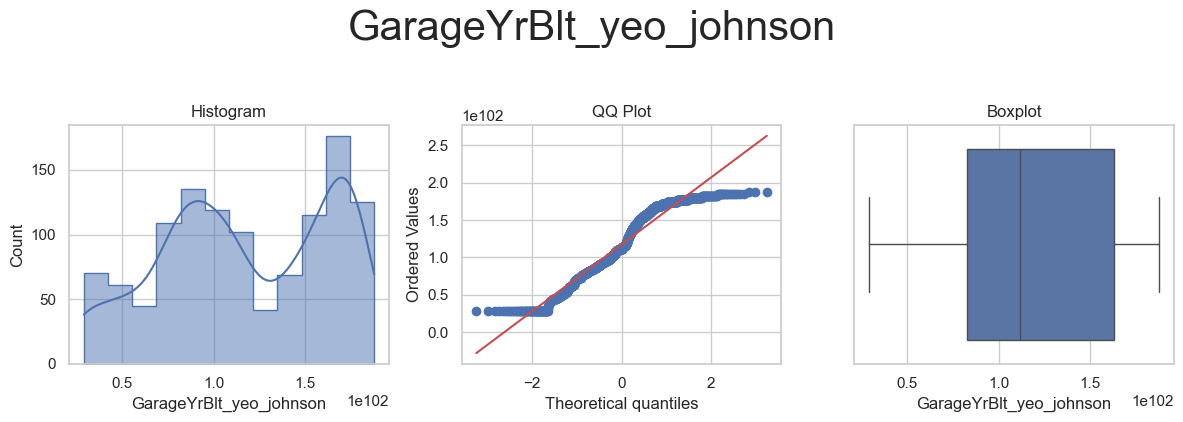



* Variable Analyzed: GrLivArea
* Applied transformation: ['GrLivArea_log_e', 'GrLivArea_log_10', 'GrLivArea_reciprocal', 'GrLivArea_power', 'GrLivArea_box_cox', 'GrLivArea_yeo_johnson'] 



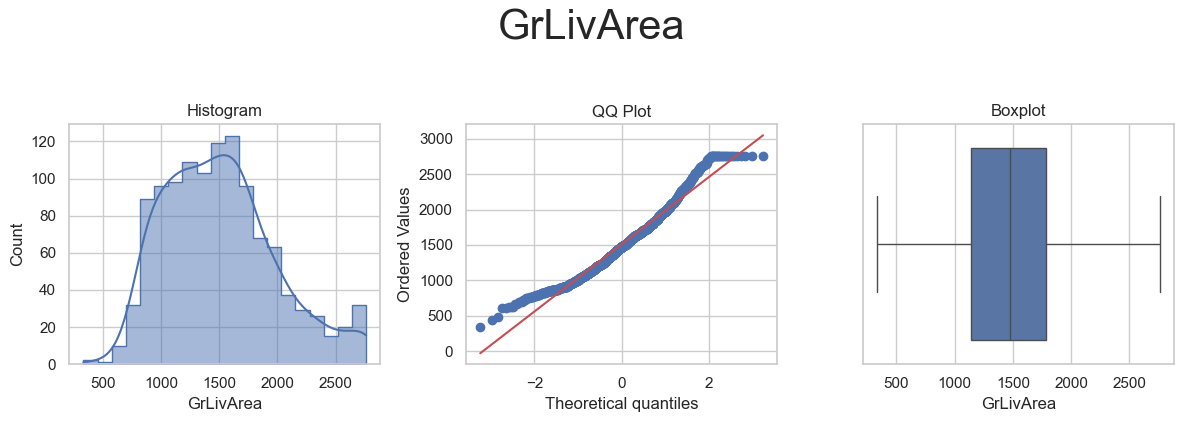

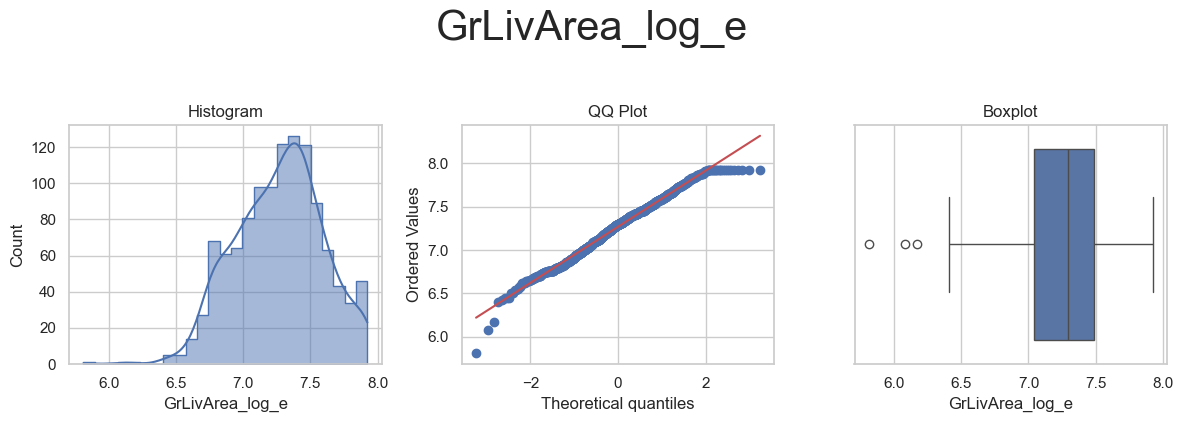

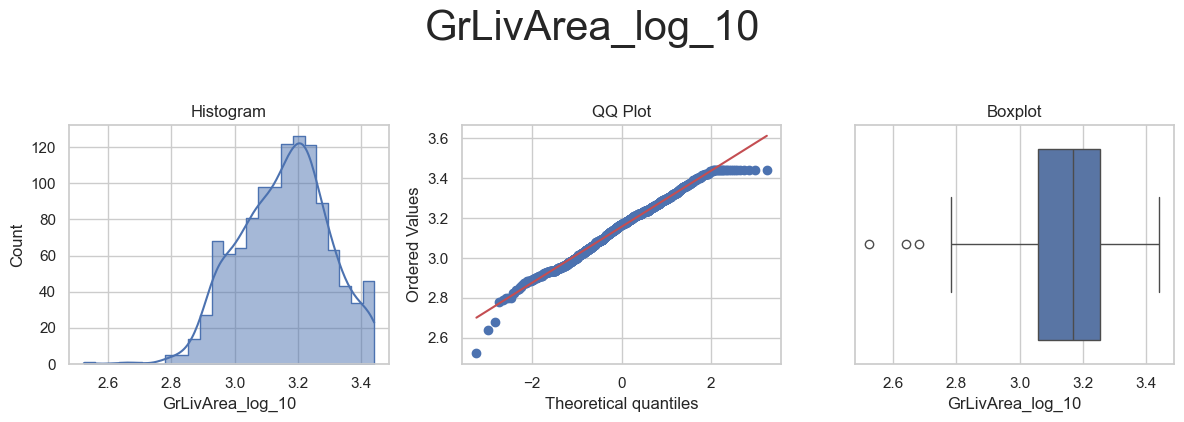

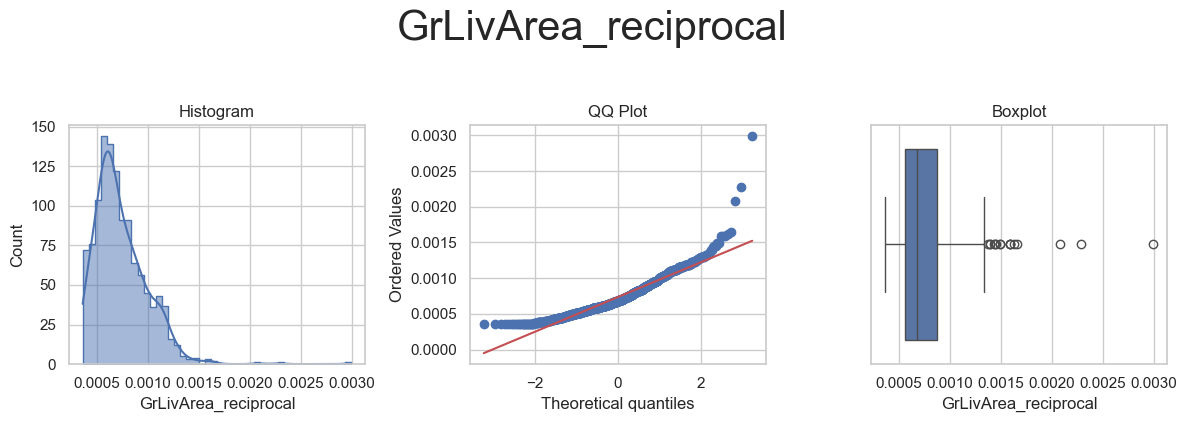

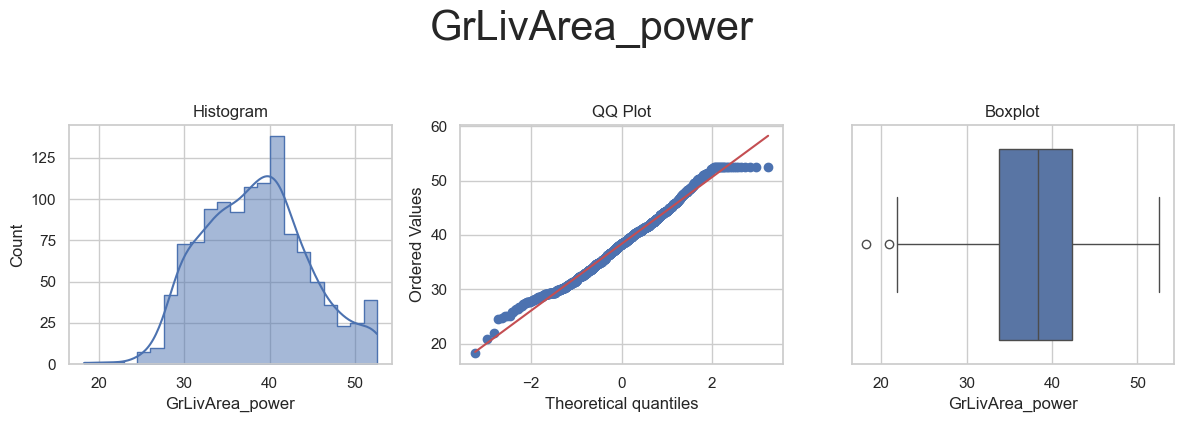

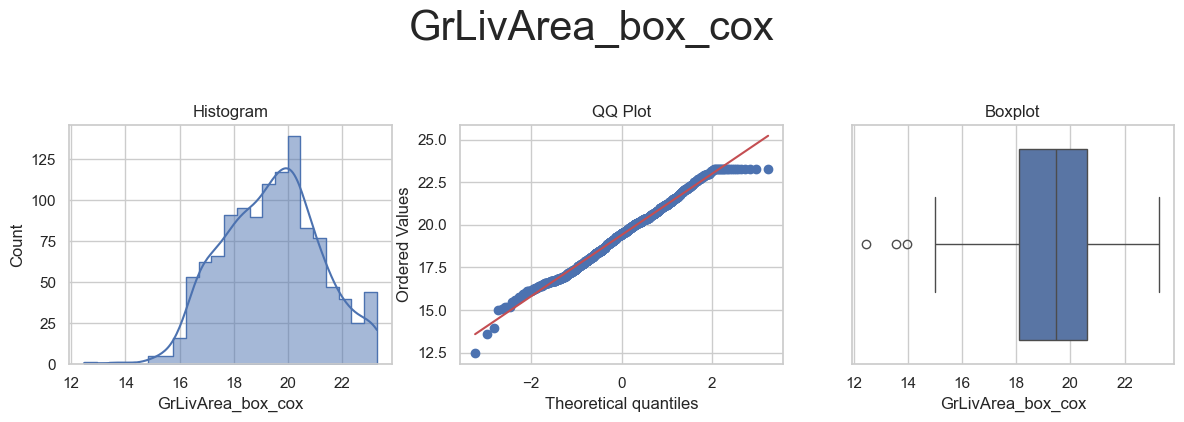

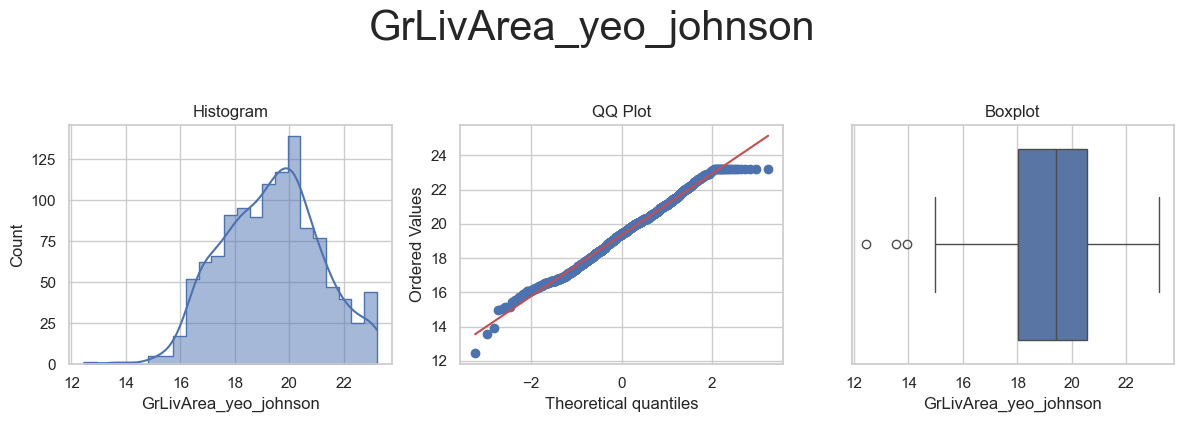



* Variable Analyzed: LotArea
* Applied transformation: ['LotArea_log_e', 'LotArea_log_10', 'LotArea_reciprocal', 'LotArea_power', 'LotArea_box_cox', 'LotArea_yeo_johnson'] 



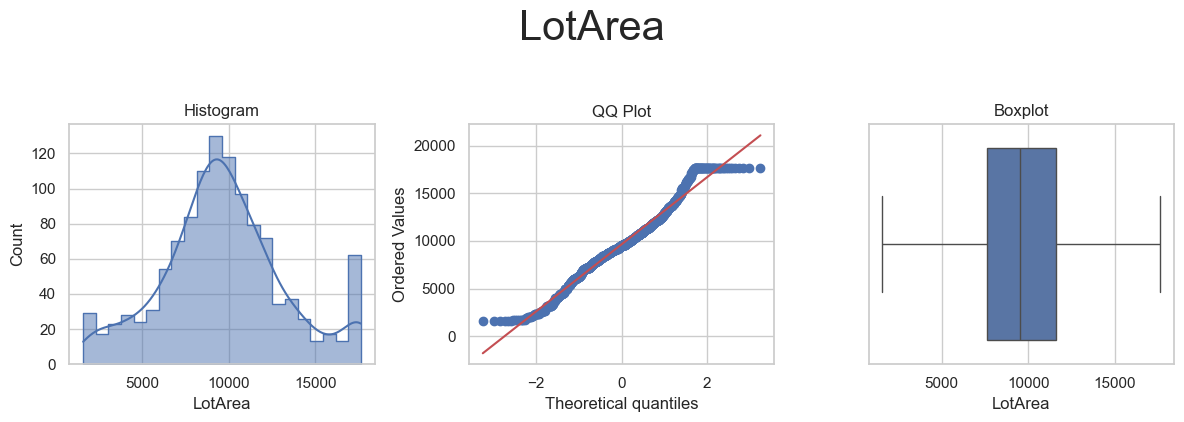

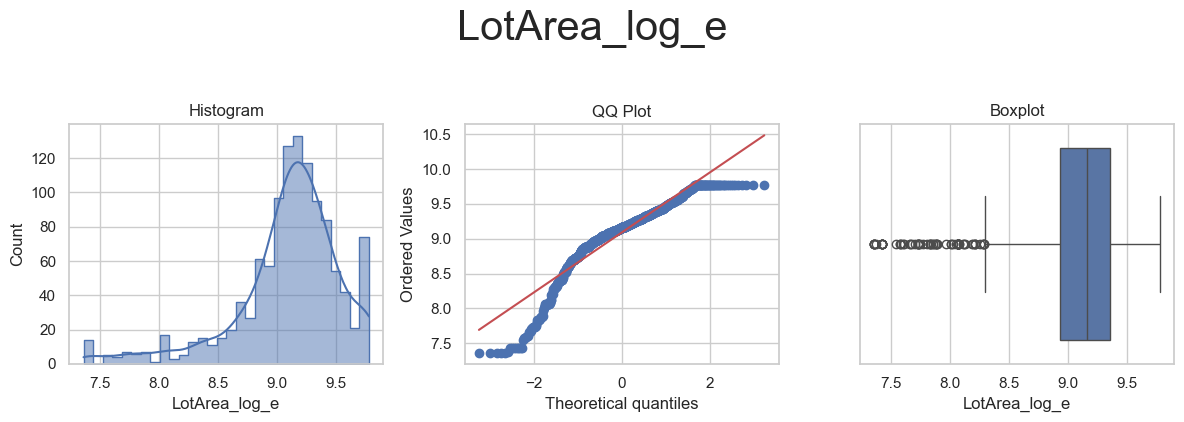

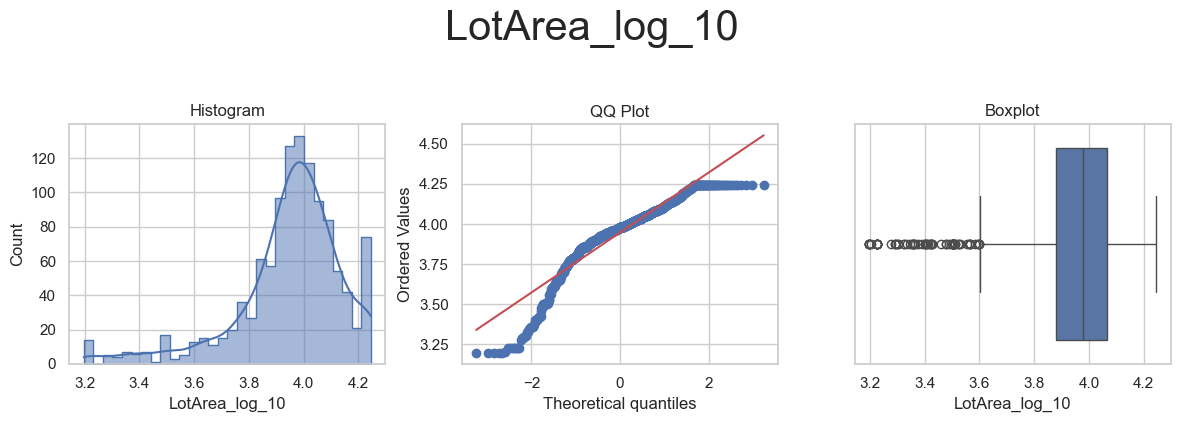

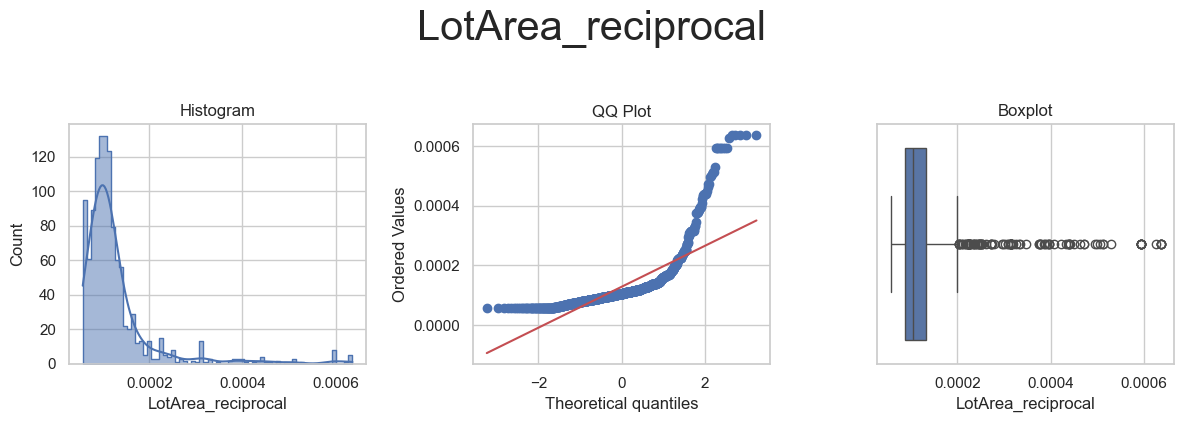

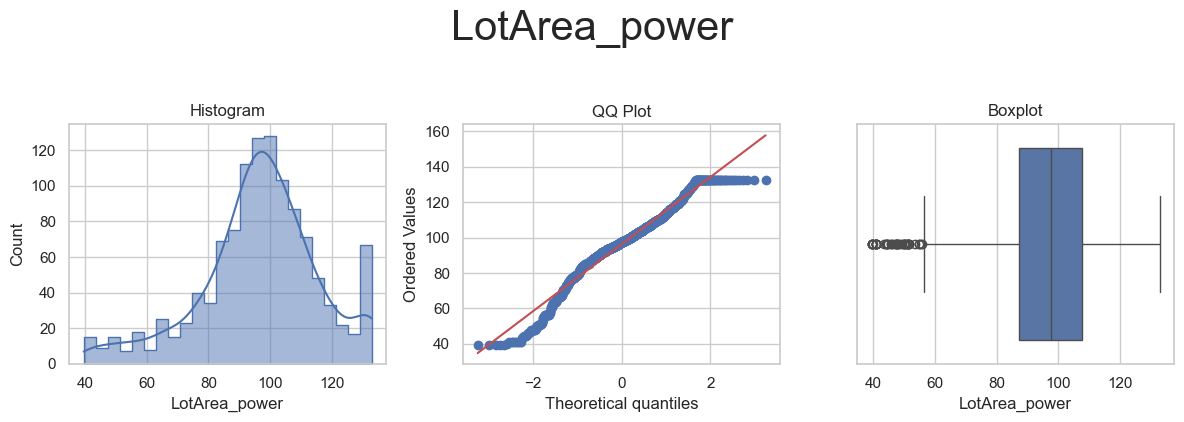

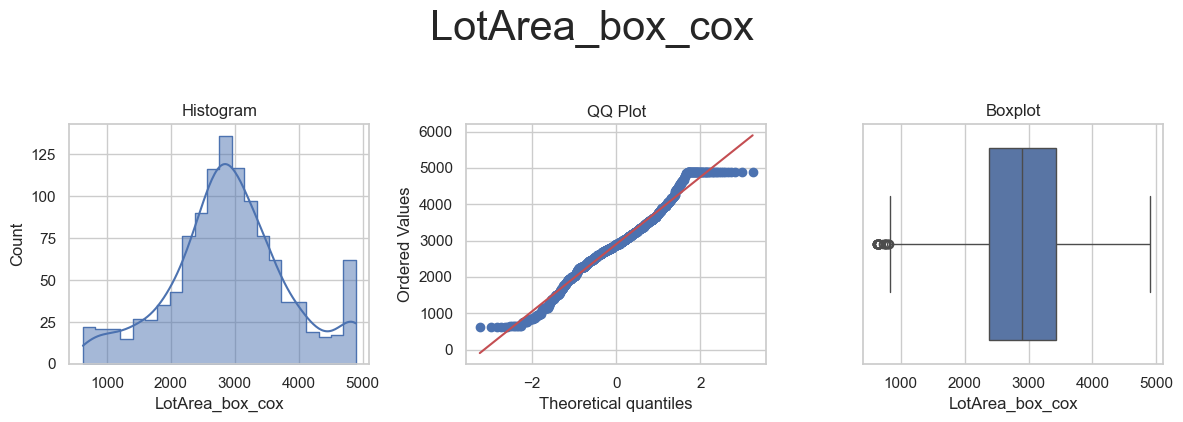

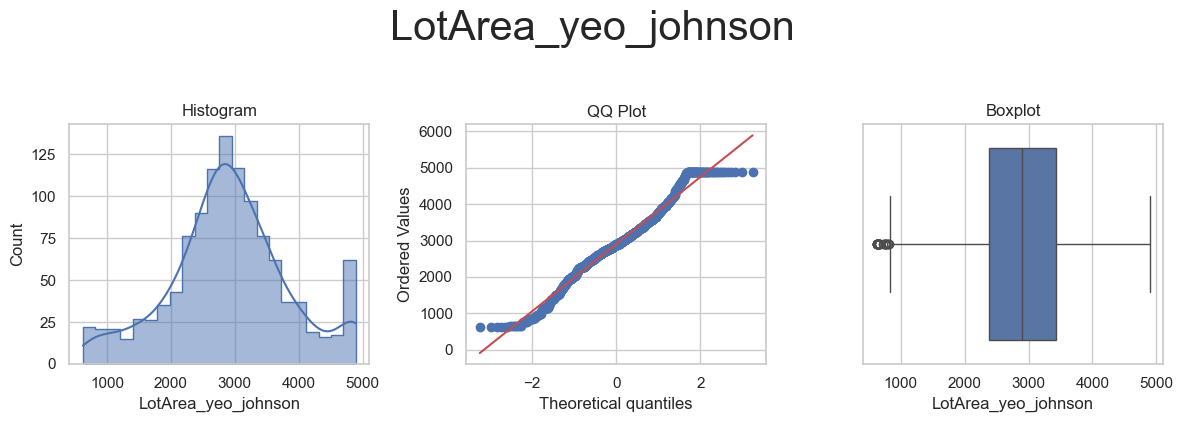



* Variable Analyzed: LotFrontage
* Applied transformation: ['LotFrontage_log_e', 'LotFrontage_log_10', 'LotFrontage_reciprocal', 'LotFrontage_power', 'LotFrontage_box_cox', 'LotFrontage_yeo_johnson'] 



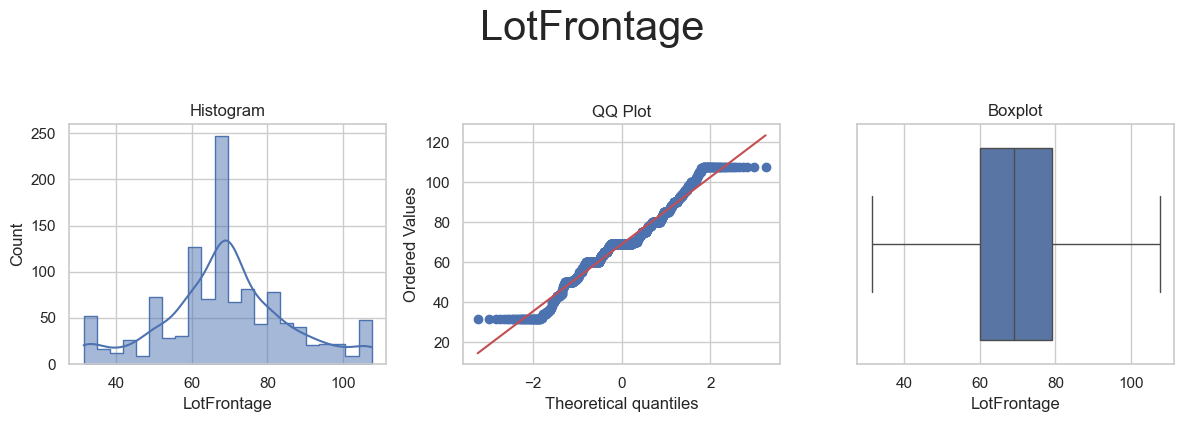

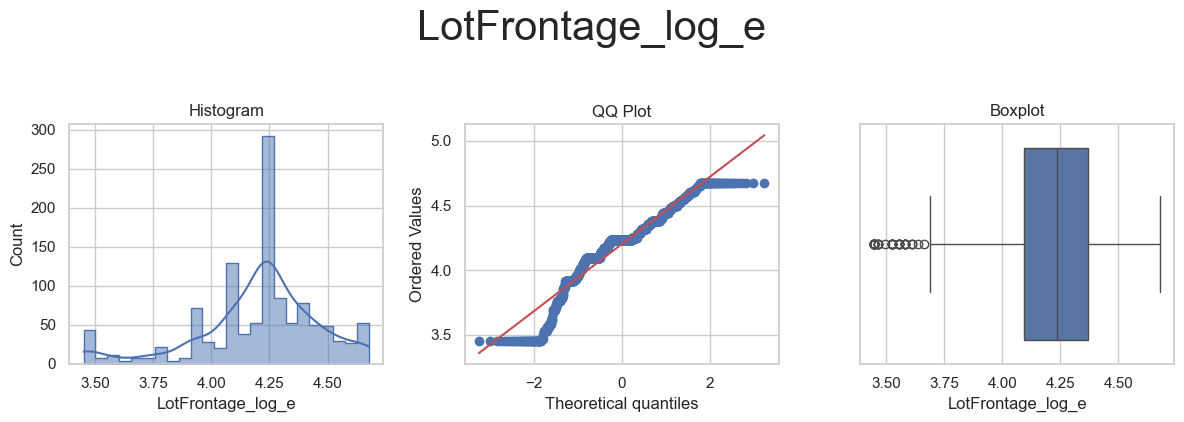

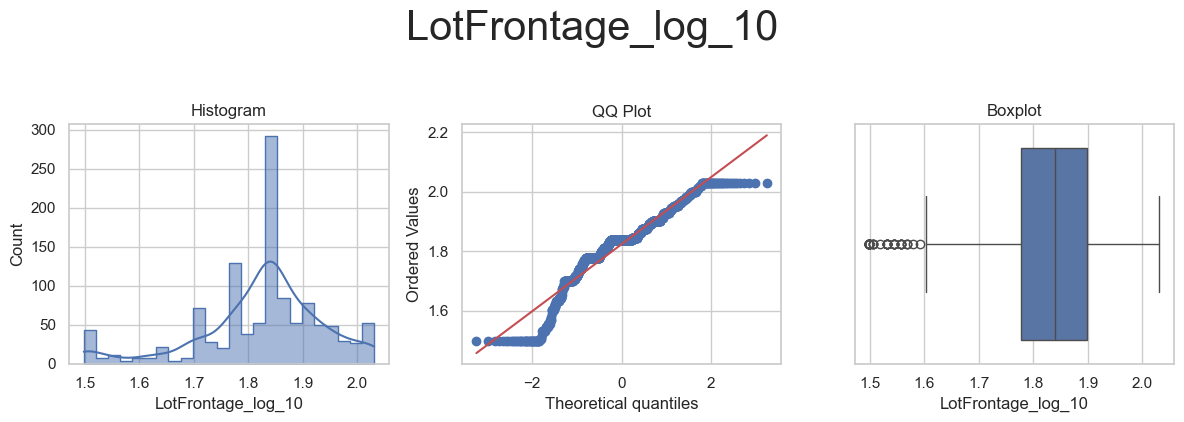

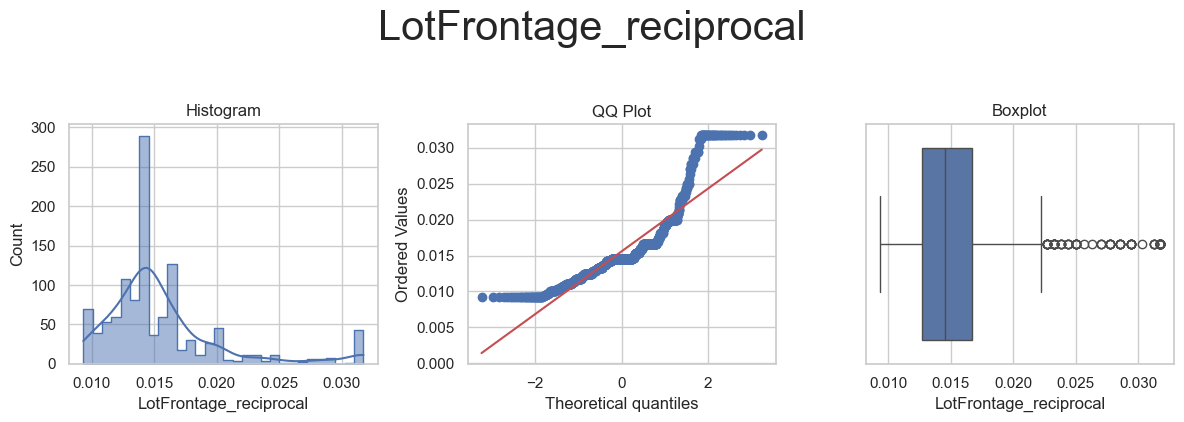

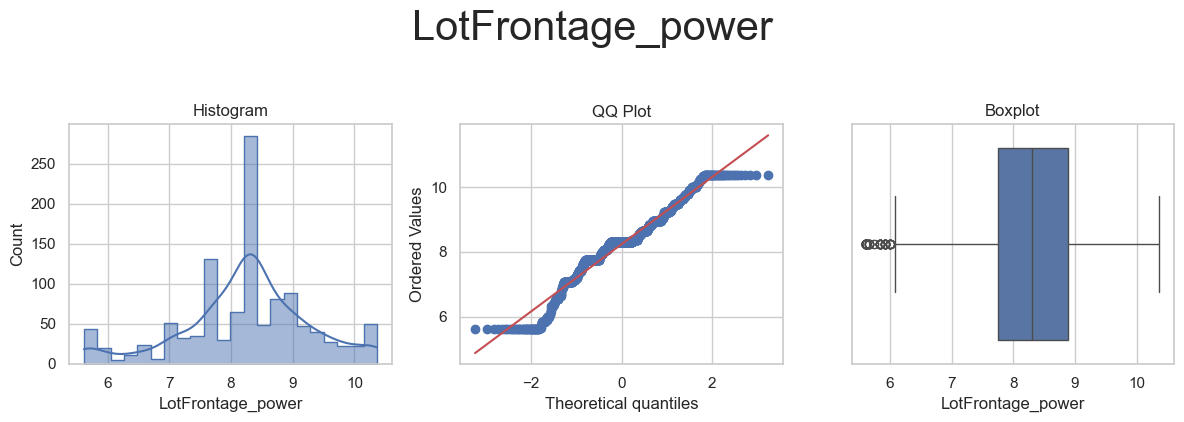

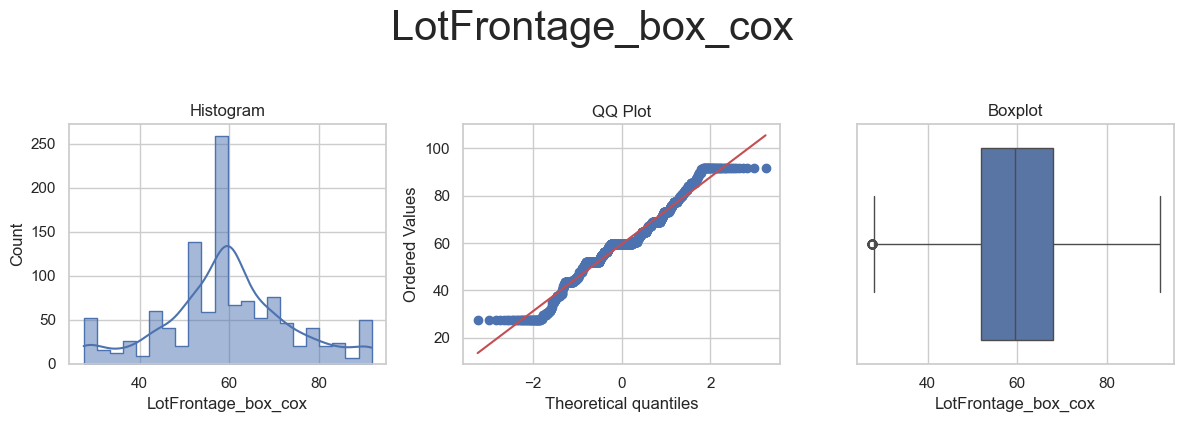

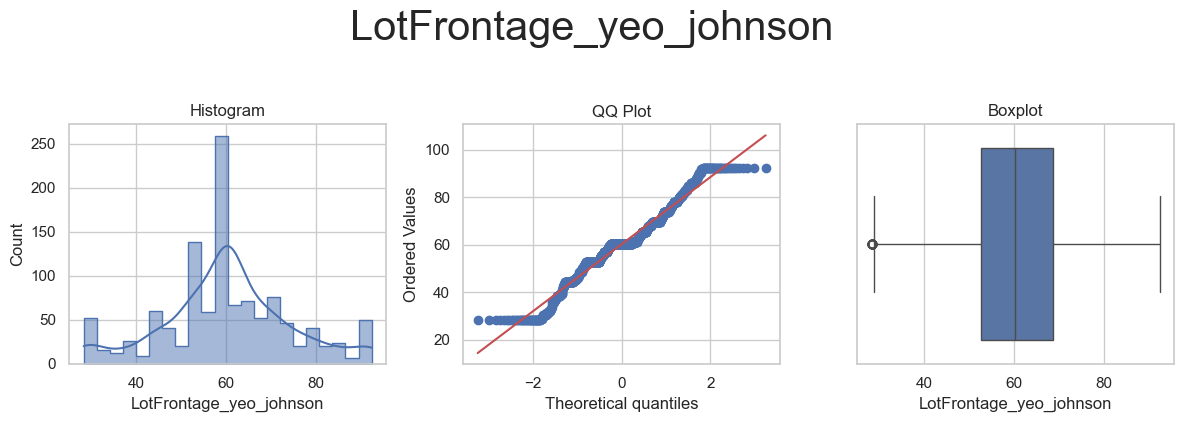



* Variable Analyzed: OverallCond
* Applied transformation: ['OverallCond_log_e', 'OverallCond_log_10', 'OverallCond_reciprocal', 'OverallCond_power', 'OverallCond_box_cox', 'OverallCond_yeo_johnson'] 



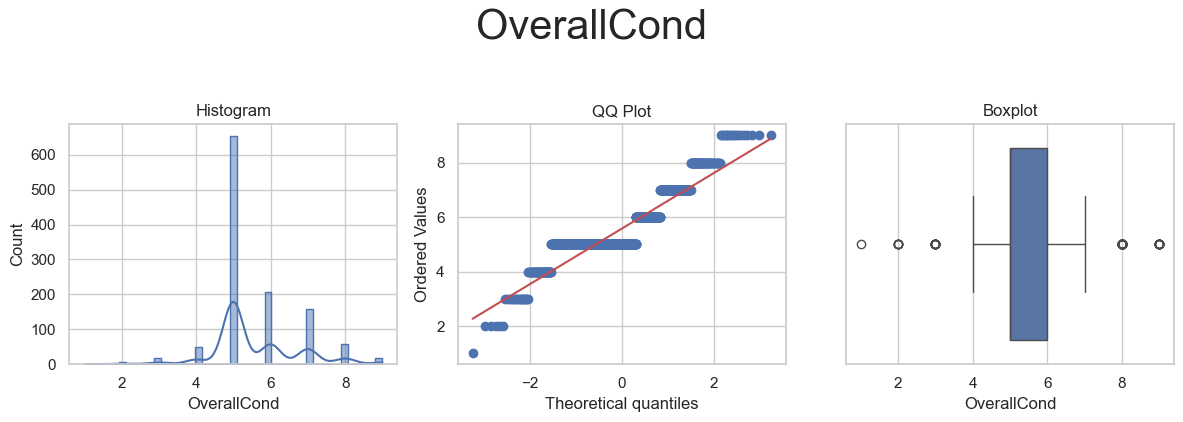

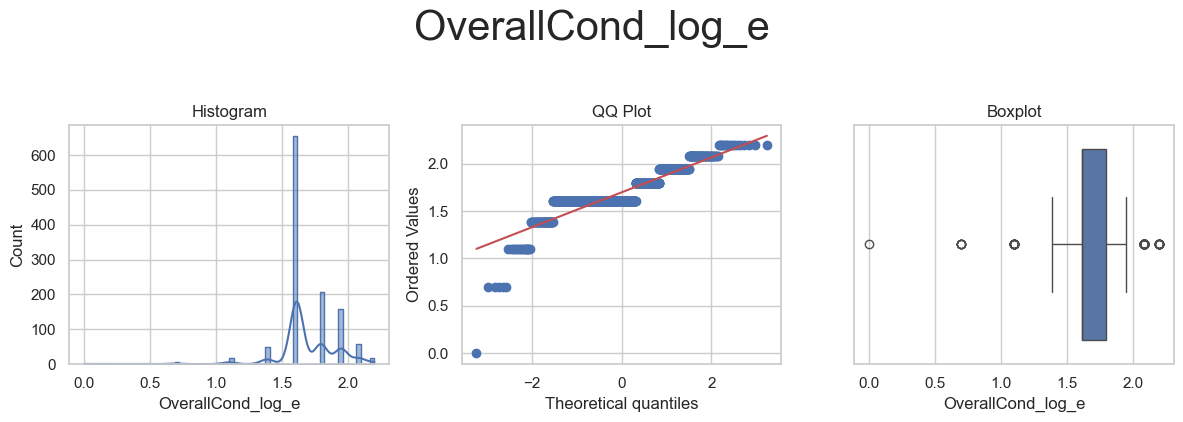

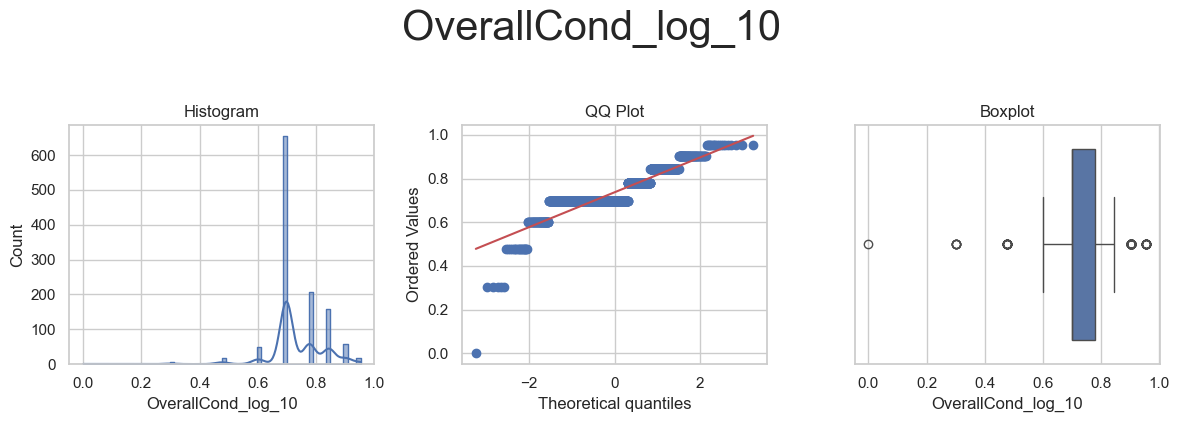

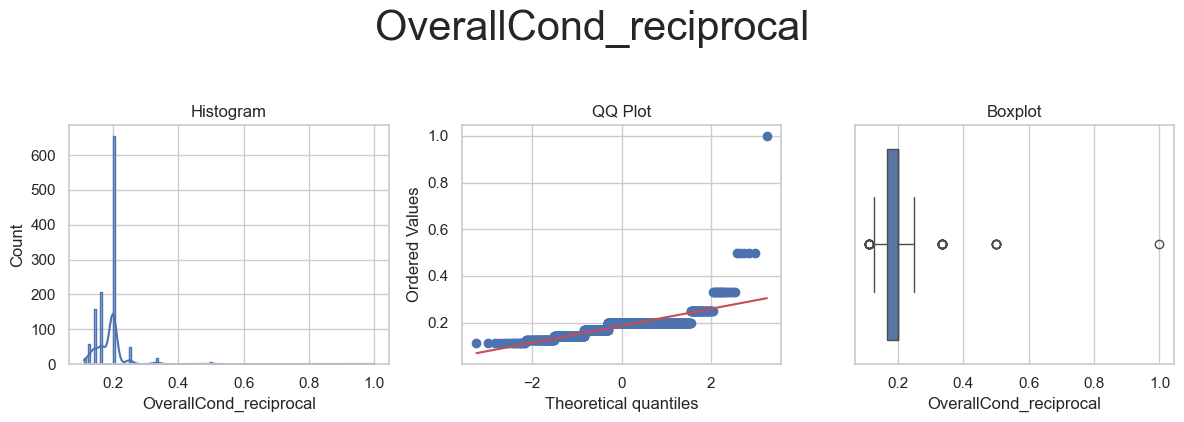

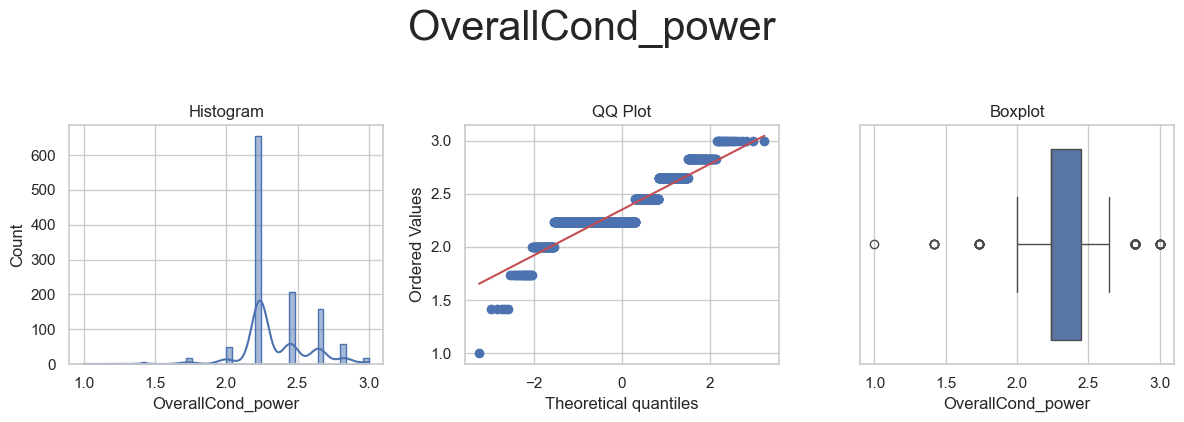

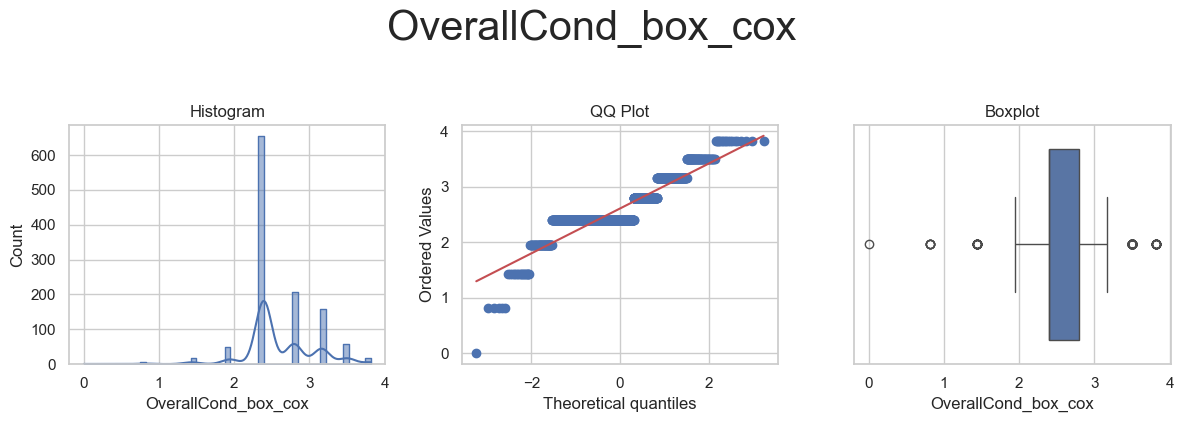

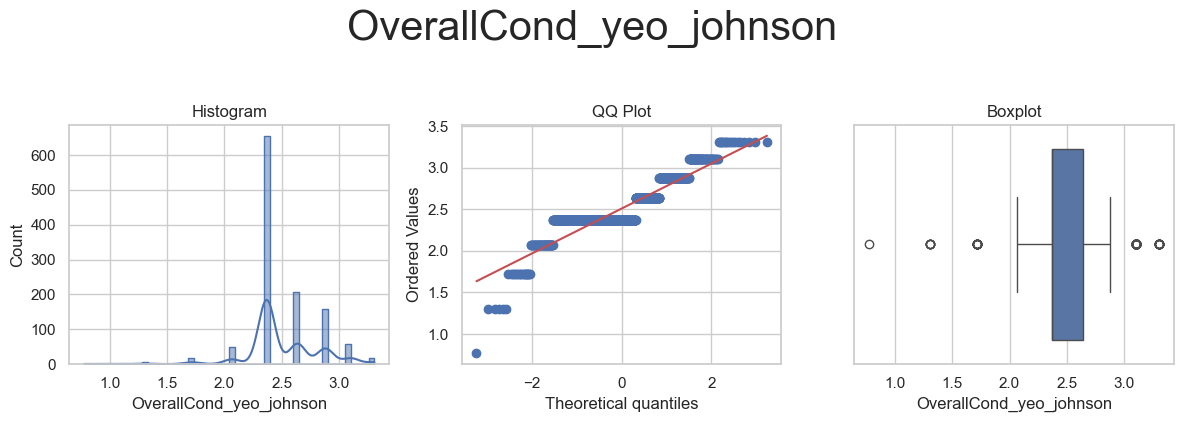



* Variable Analyzed: OverallQual
* Applied transformation: ['OverallQual_log_e', 'OverallQual_log_10', 'OverallQual_reciprocal', 'OverallQual_power', 'OverallQual_box_cox', 'OverallQual_yeo_johnson'] 



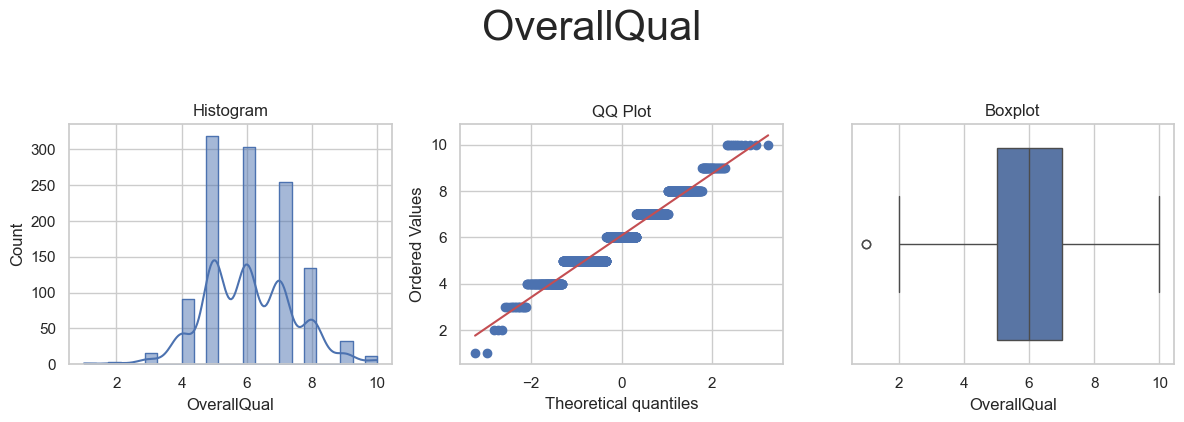

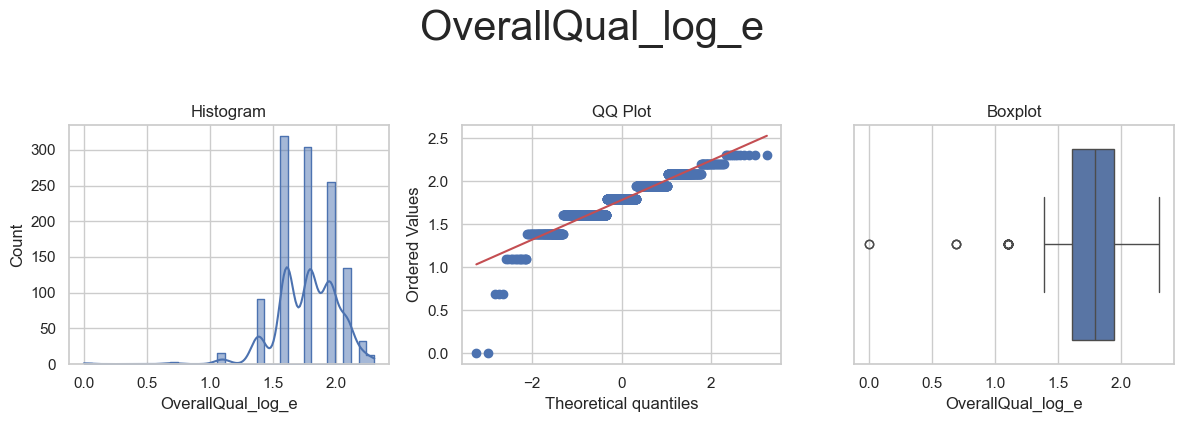

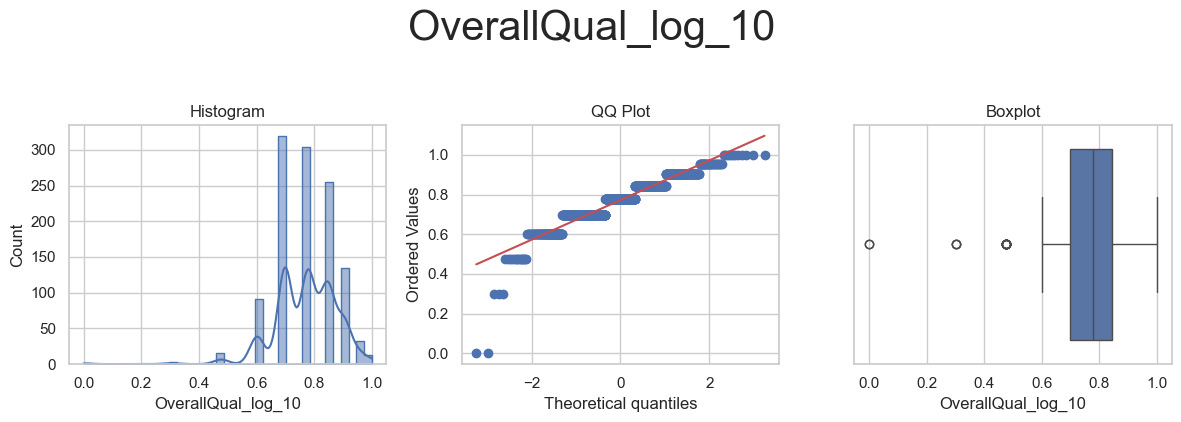

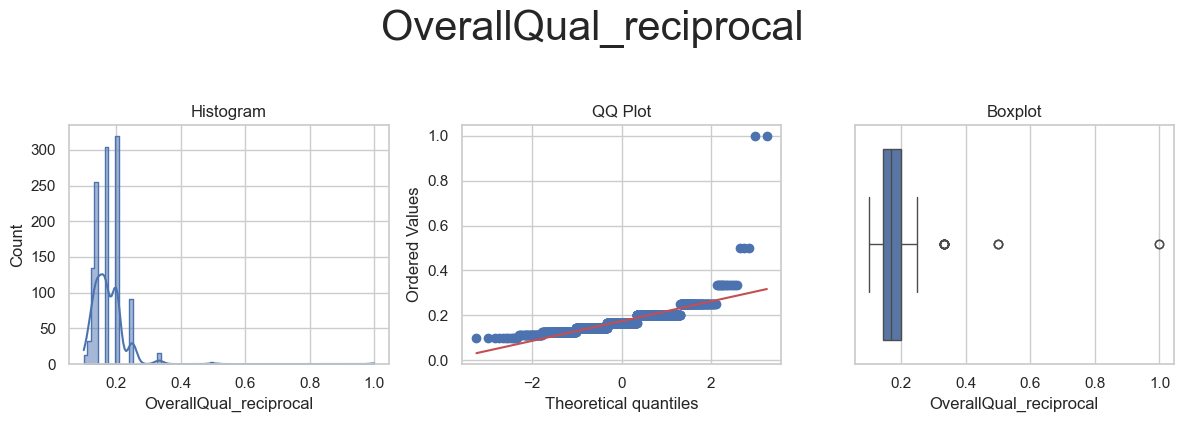

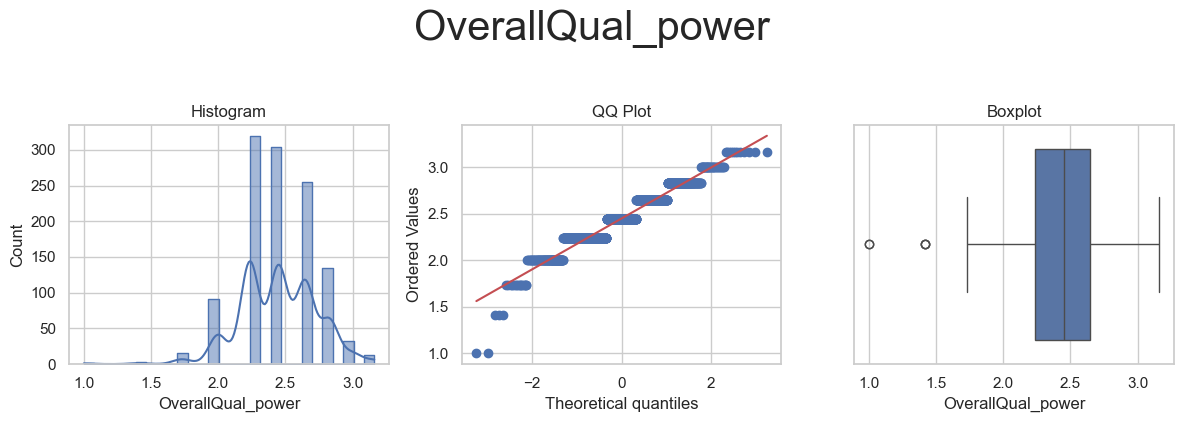

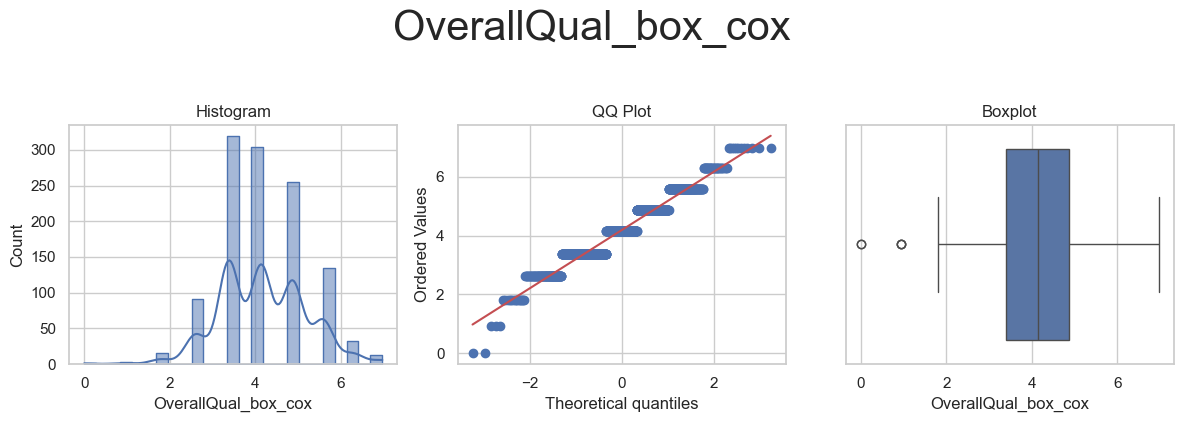

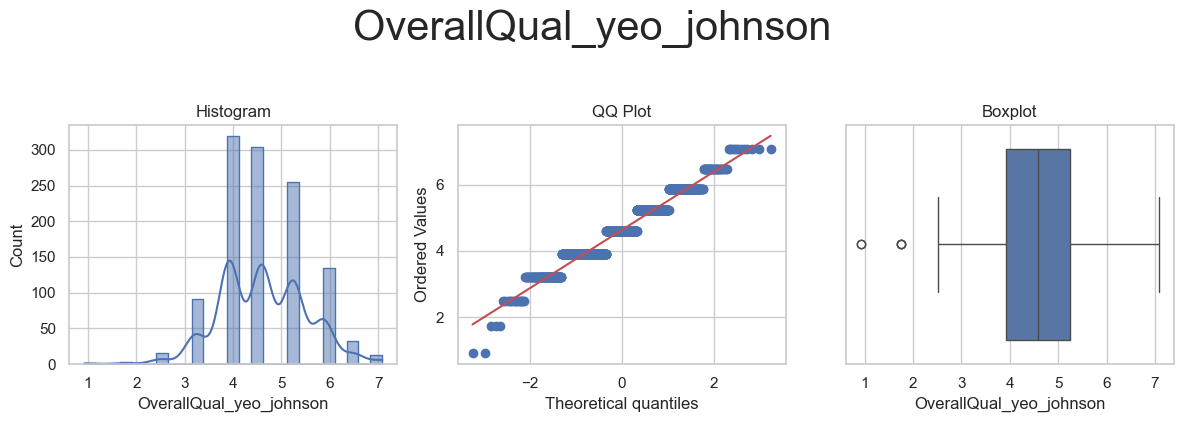



* Variable Analyzed: TotalBsmtSF
* Applied transformation: ['TotalBsmtSF_log_e', 'TotalBsmtSF_log_10', 'TotalBsmtSF_reciprocal', 'TotalBsmtSF_power', 'TotalBsmtSF_box_cox', 'TotalBsmtSF_yeo_johnson'] 



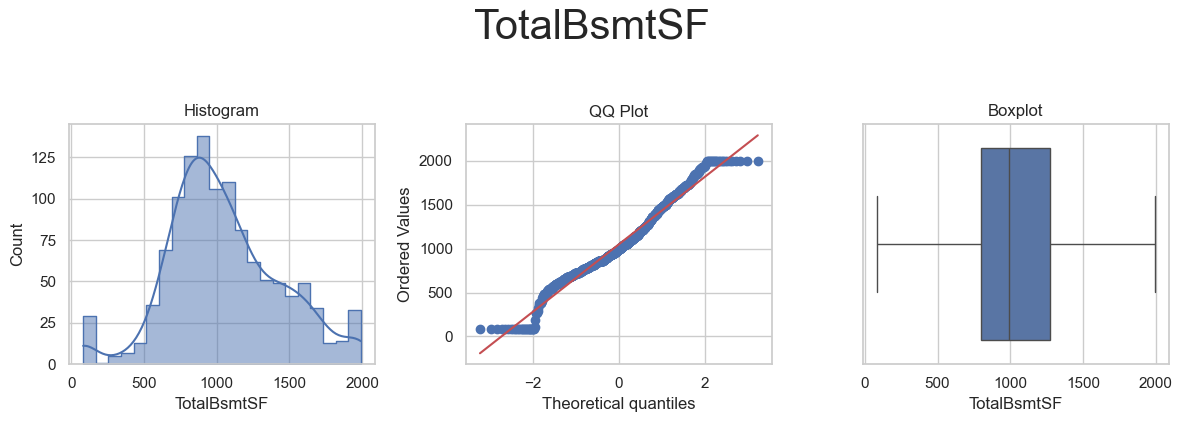

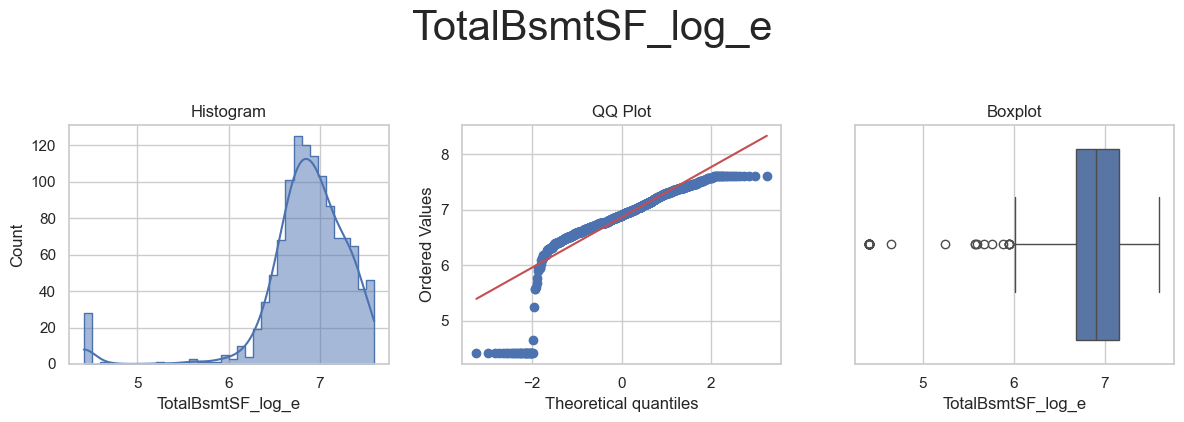

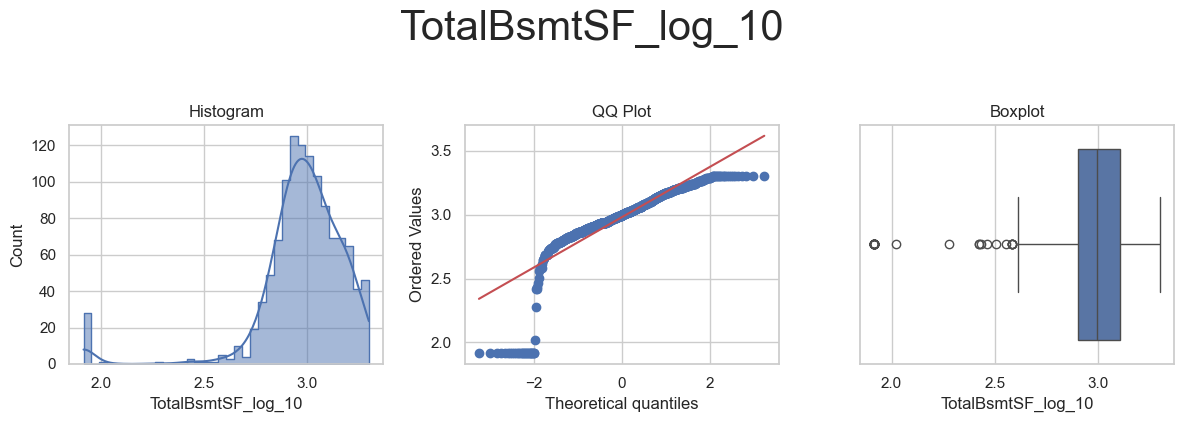

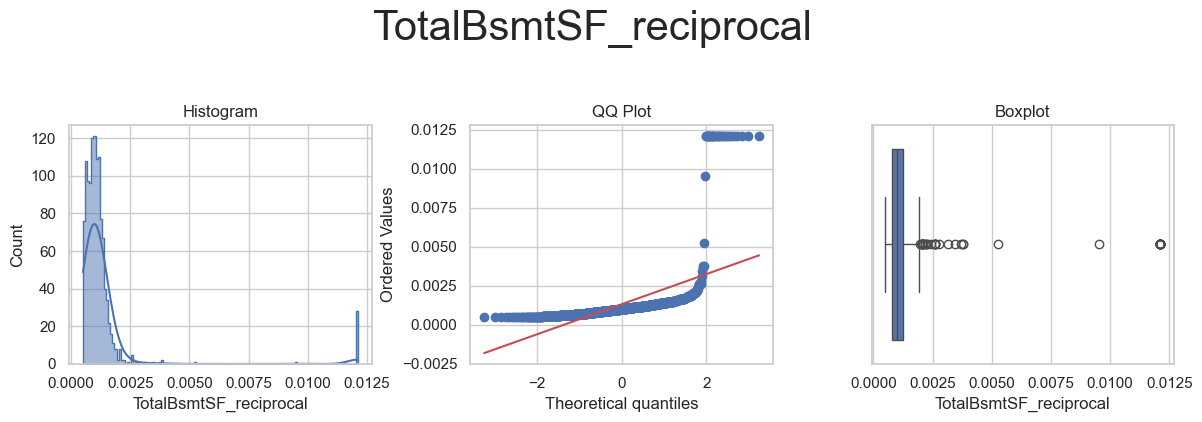

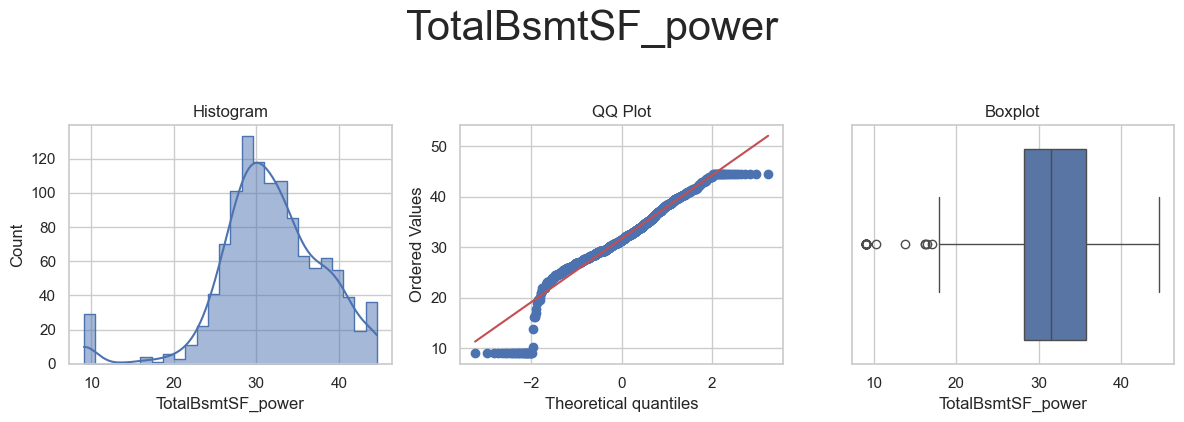

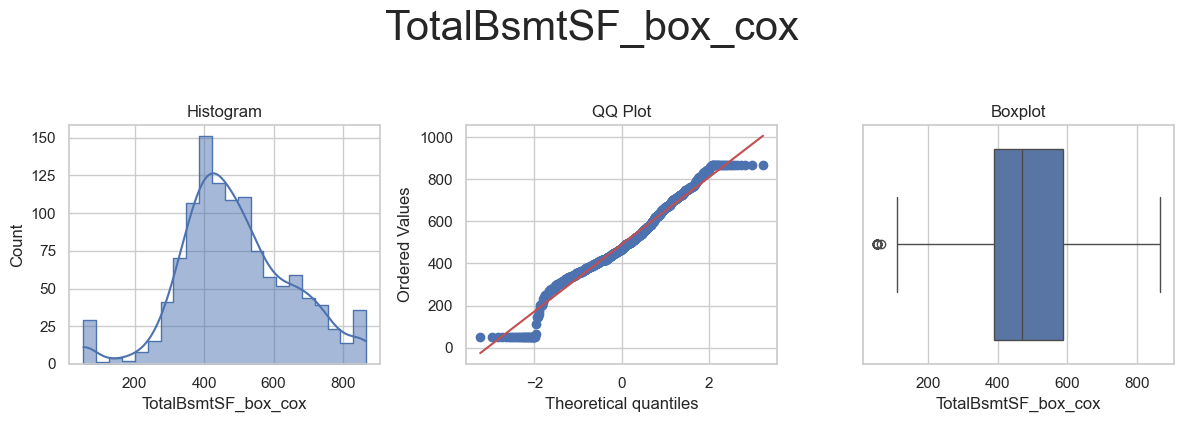

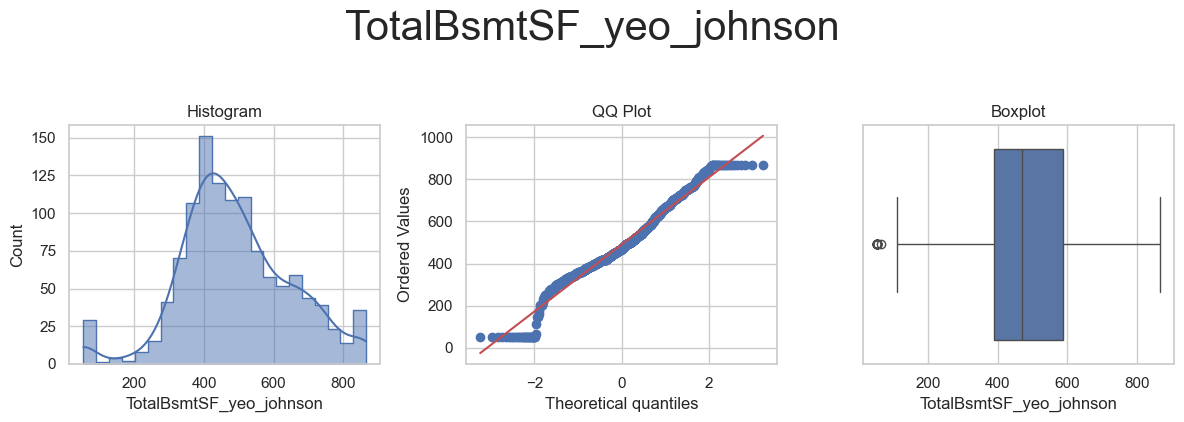



* Variable Analyzed: YearBuilt
* Applied transformation: ['YearBuilt_log_e', 'YearBuilt_log_10', 'YearBuilt_reciprocal', 'YearBuilt_power', 'YearBuilt_box_cox', 'YearBuilt_yeo_johnson'] 



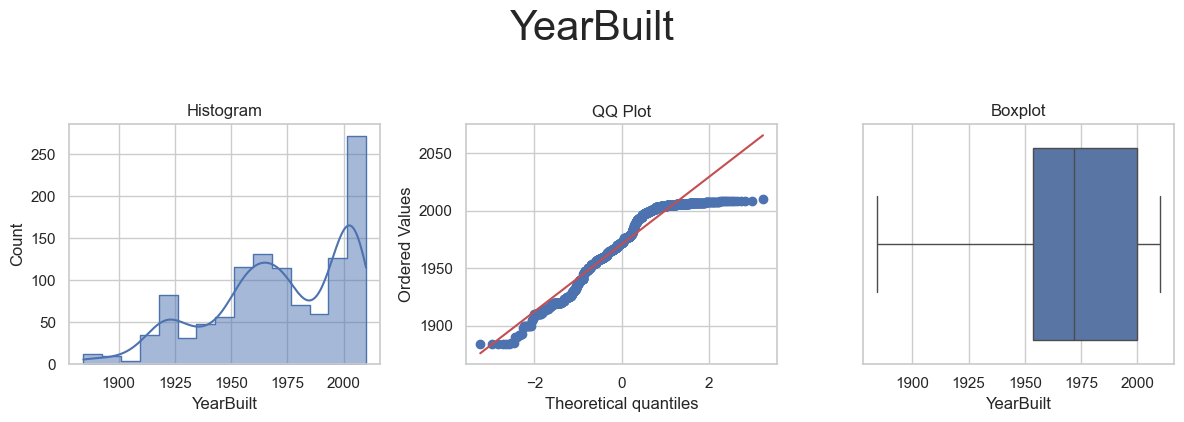

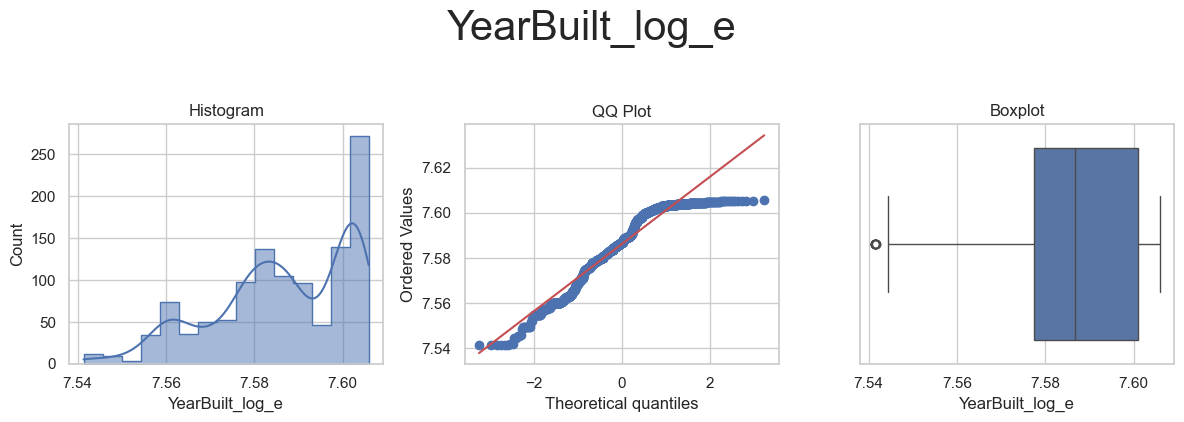

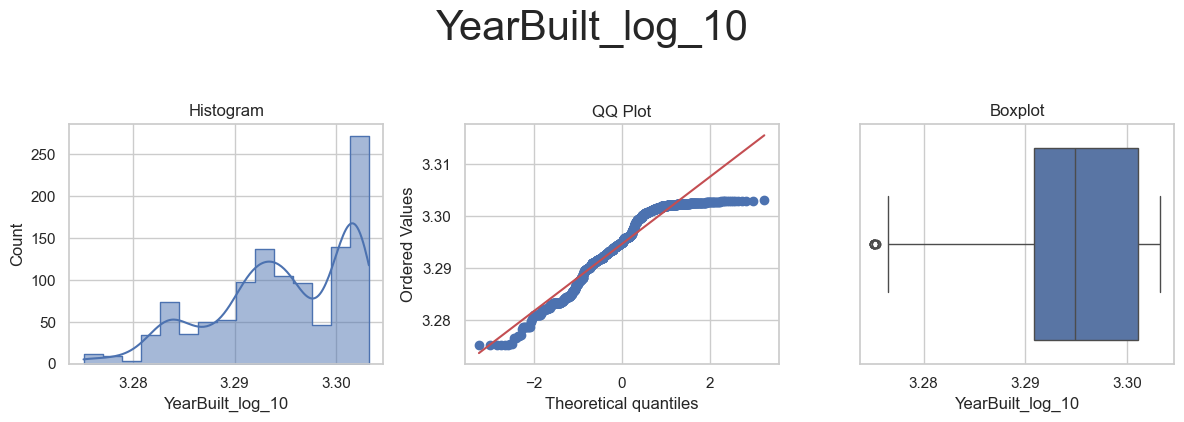

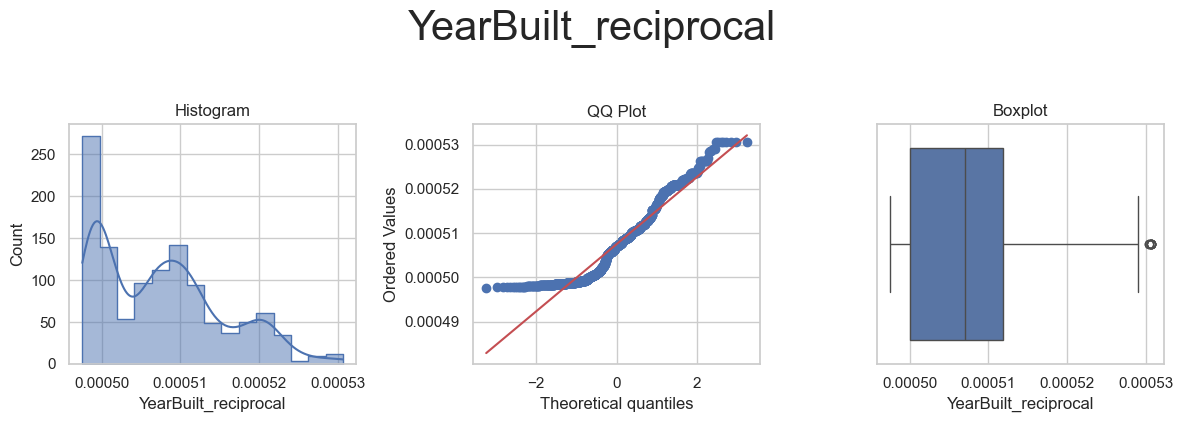

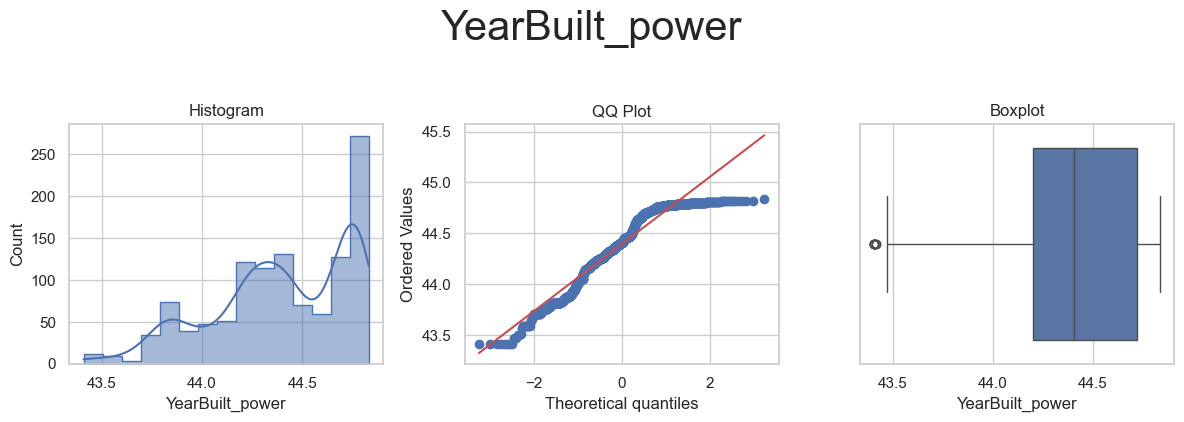

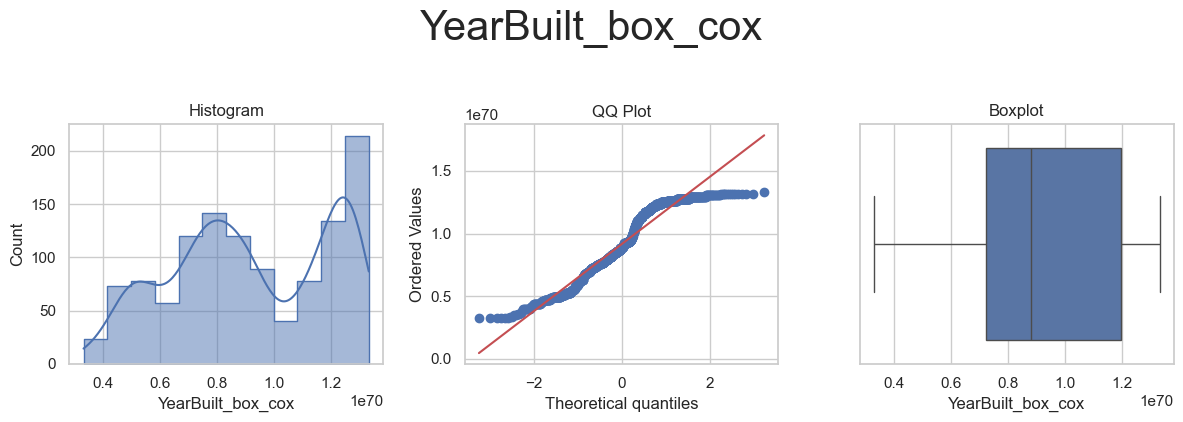

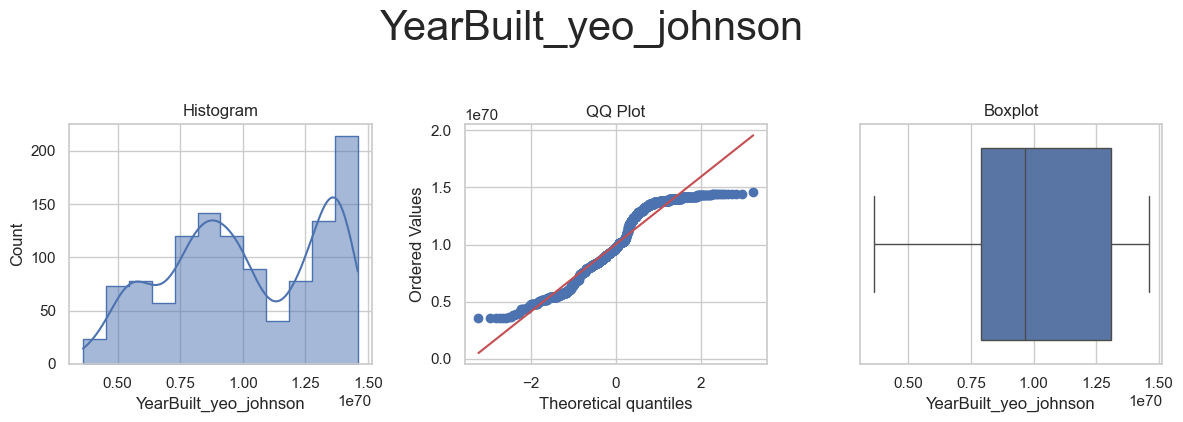



* Variable Analyzed: YearRemodAdd
* Applied transformation: ['YearRemodAdd_log_e', 'YearRemodAdd_log_10', 'YearRemodAdd_reciprocal', 'YearRemodAdd_power', 'YearRemodAdd_box_cox', 'YearRemodAdd_yeo_johnson'] 



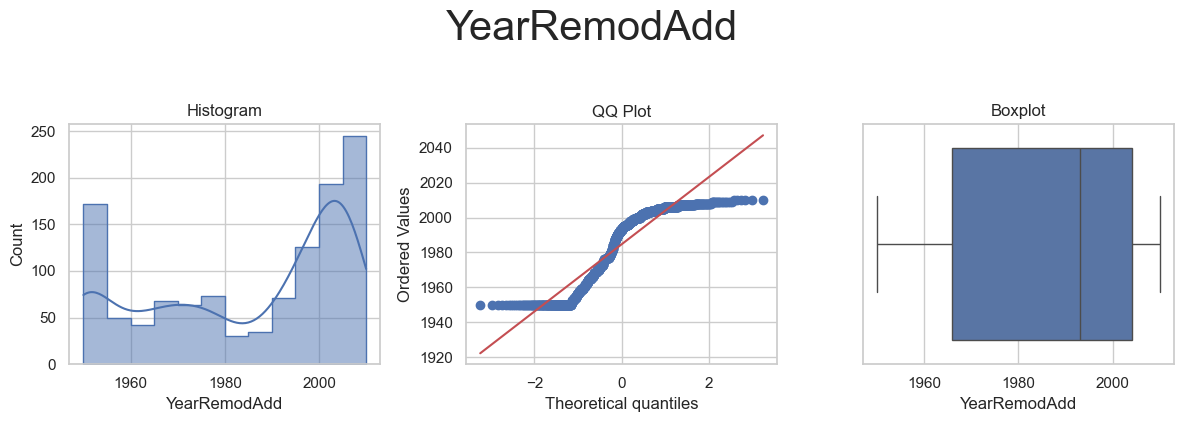

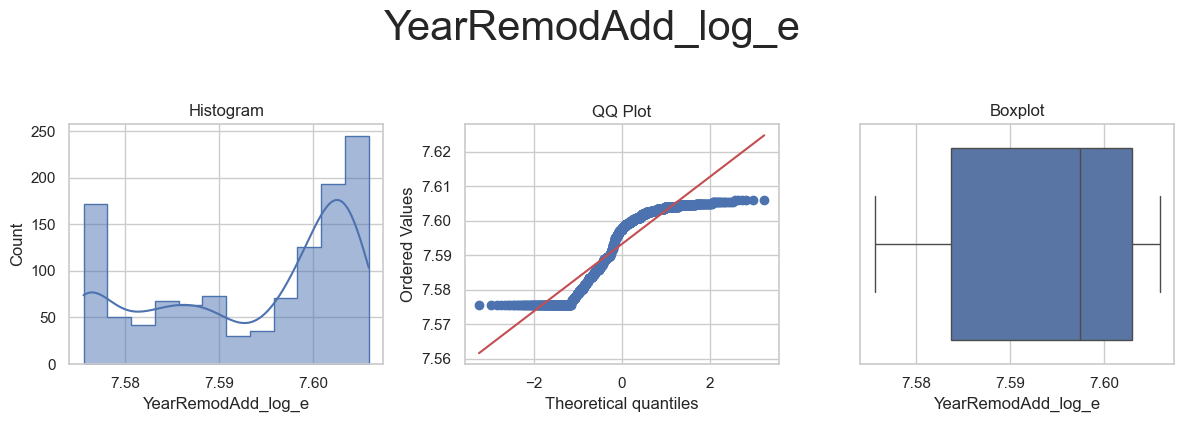

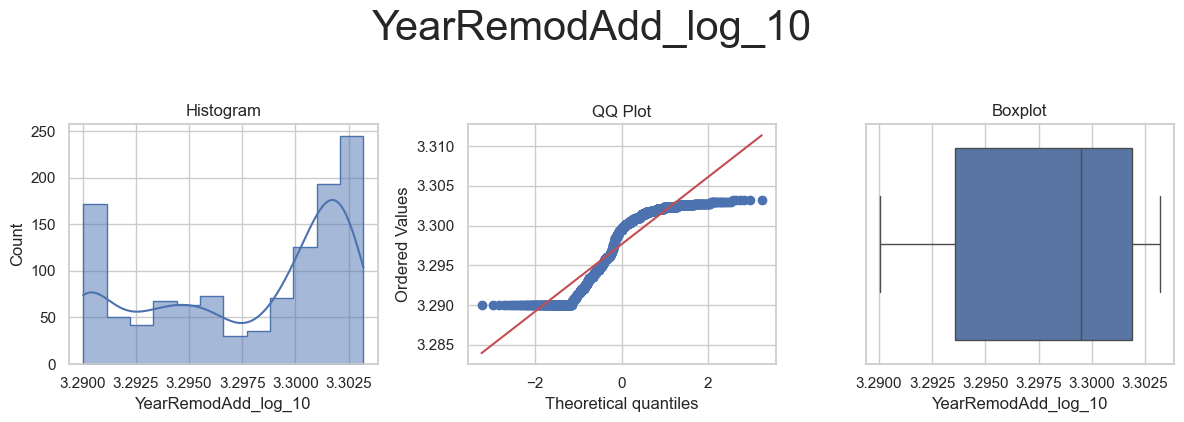

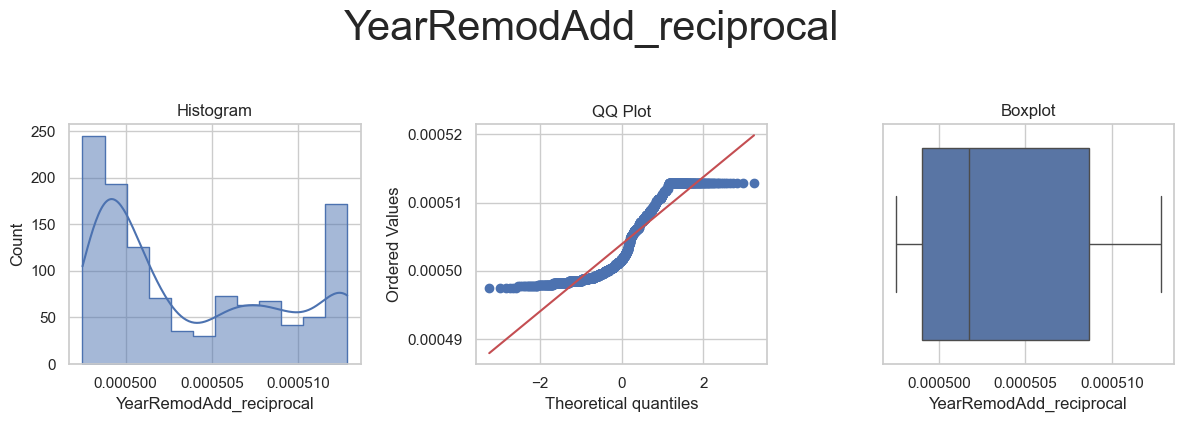

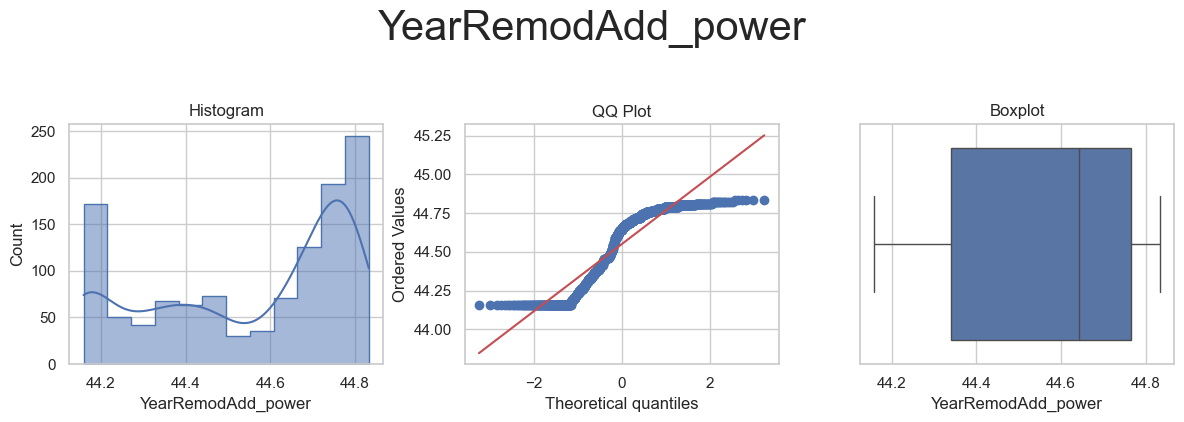

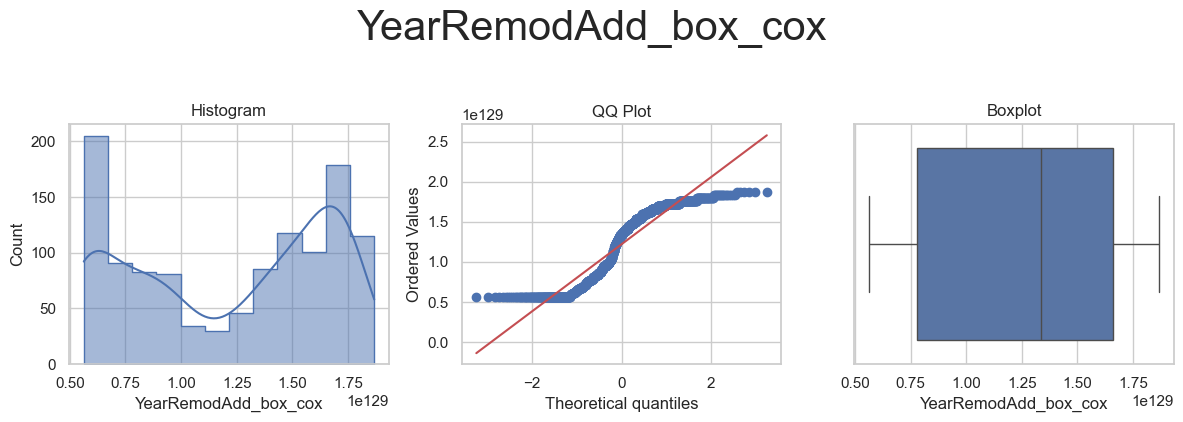

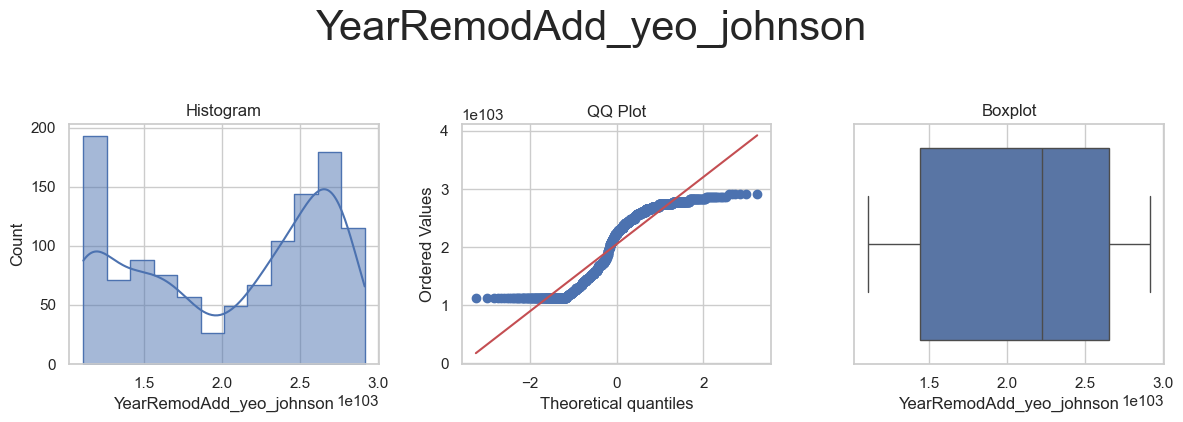

In [28]:
df_engineering = FeatureEngineeringAnalysis(df=df_engineering,
                                            analysis_type='numerical')


**Conclusion**

After applying various numerical transformations to improve feature distributions and normality, the following conclusions were drawn:

* The power transformation worked best for 1stFlrSF, resulting in the most normalized distribution and improved QQ plot alignment.

* The yeo_johnson transformation provided the most consistent improvements across several features. It worked best for BedroomAbvGr, BsmtFinSF1, BsmtUnfSF, GarageArea, YearRemodAdd, and YearBuilt, significantly reducing skew and aligning values closer to the normal distribution.

* For GarageYrBlt, both log_e and log_10 transformations had a moderate positive effect, but did not fully normalize the distribution.

* For GrLivArea, OverallCond, and TotalBsmtSF, both yeo_johnson and box_cox transformations performed well, producing the most normal-like distributions and improved QQ plots.

* The box_cox transformation alone worked best for OverallQual, making it the most effective choice for that feature.

* For LotArea, all three transformations—log_10, box_cox, and yeo_johnson—helped improve the distribution by addressing right skewness effectively.

* Similarly, LotFrontage improved with log_e, box_cox, and yeo_johnson, which all helped bring the feature closer to normality.

However, not all transformations were beneficial:

* The reciprocal transformation did not improve any feature’s distribution and can be considered ineffective for this dataset.

* 2ndFlrSF did not benefit from any transformation. Its distribution remained irregular regardless of the method applied.


* Step 4 - Create a transformer pipeline using feature_engine

In [29]:
from feature_engine.transformation import (
    PowerTransformer, BoxCoxTransformer, YeoJohnsonTransformer, LogTransformer
)

from sklearn.pipeline import Pipeline

# Build a pipeline with all chosen transformations
preprocessing_pipeline = Pipeline([
    ("power_1stFlrSF", PowerTransformer(variables=["1stFlrSF"])),
    ("yeojohnson_group1", YeoJohnsonTransformer(variables=[
        "BedroomAbvGr", "BsmtFinSF1", "BsmtUnfSF",
        "GarageArea", "YearBuilt", "YearRemodAdd",
        "GrLivArea", "LotArea", "LotFrontage",
        "OverallCond", "TotalBsmtSF"
    ])),
    ("log_garageyrblt", LogTransformer(variables=["GarageYrBlt"], base='10')),
    ("boxcox_overallqual", BoxCoxTransformer(variables=["OverallQual"])),
])


* Step 5: Apply the pipeline to Train and Test sets

In [30]:
TrainSet = preprocessing_pipeline.fit_transform(TrainSet)
TestSet = preprocessing_pipeline.transform(TestSet)

print("* Numerical transformation completed!")


* Numerical transformation completed!


### Categorical Encoding - Ordinal: replaces categories with ordinal numbers 

* Step 1: Select variable(s)

In [31]:
variables_engineering = ['BsmtExposure', 'BsmtFinType1',
                         'GarageFinish', 'KitchenQual']
variables_engineering


['BsmtExposure', 'BsmtFinType1', 'GarageFinish', 'KitchenQual']

* Step 2: Create a separate DataFrame, with your variable(s)

In [32]:
df_engineering = TrainSet[variables_engineering].copy()
df_engineering.head(3)


,BsmtExposure,BsmtFinType1,GarageFinish,KitchenQual
0,Av,Unf,Unf,Gd
1,No,Unf,Unf,TA
2,No,ALQ,Unf,TA


* Step 3: Create engineered variables(s) by applying the transformation(s), assess engineered variables distribution and select the most suitable method for each variable.

* Variable Analyzed: BsmtExposure
* Applied transformation: ['BsmtExposure_ordinal_encoder'] 



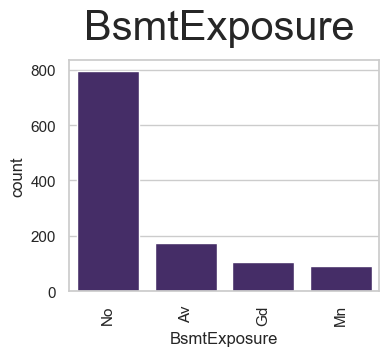

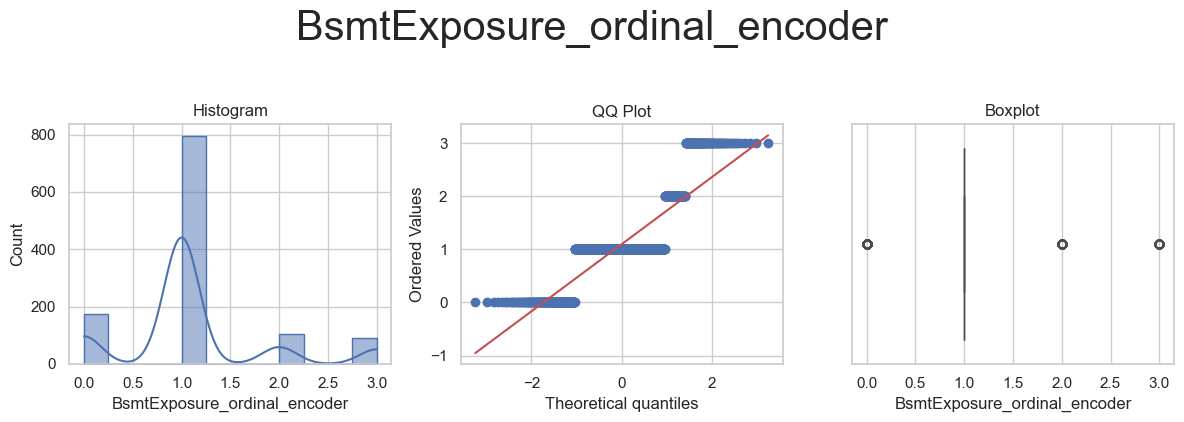



* Variable Analyzed: BsmtFinType1
* Applied transformation: ['BsmtFinType1_ordinal_encoder'] 



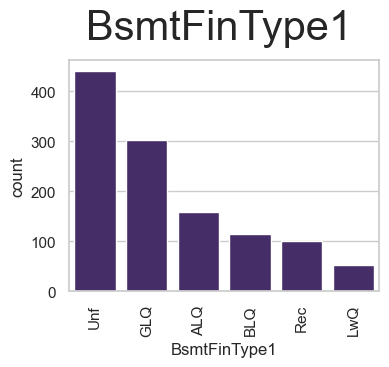

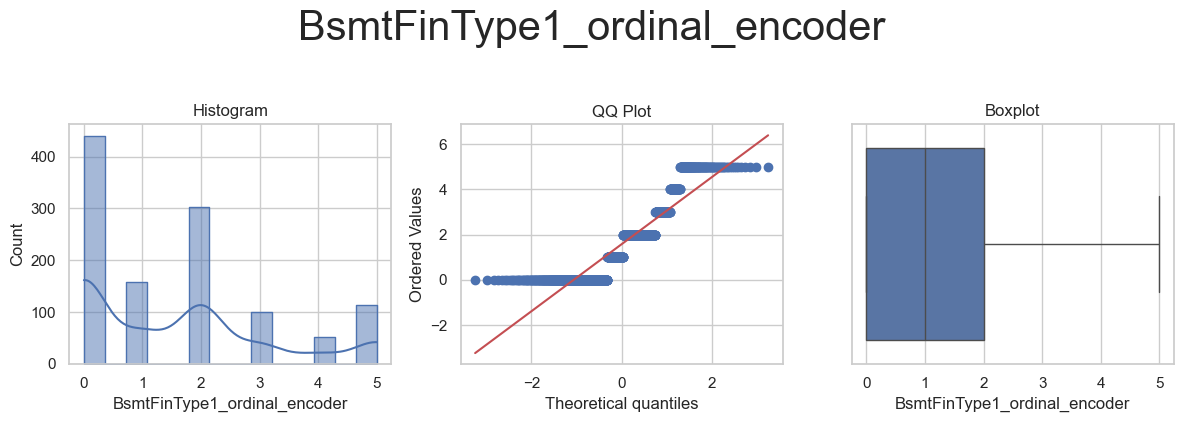



* Variable Analyzed: GarageFinish
* Applied transformation: ['GarageFinish_ordinal_encoder'] 



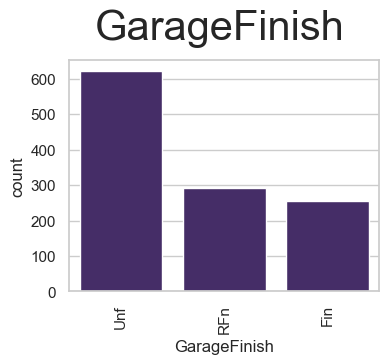

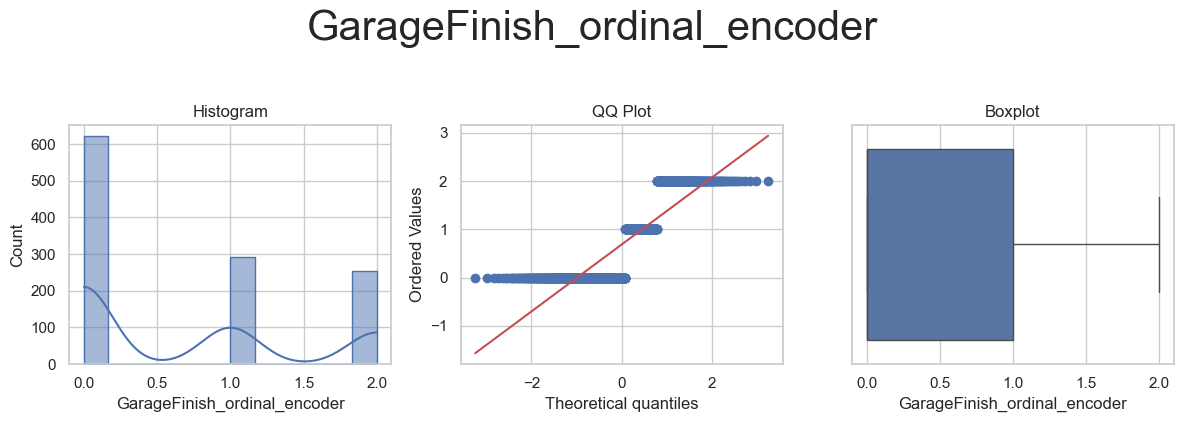



* Variable Analyzed: KitchenQual
* Applied transformation: ['KitchenQual_ordinal_encoder'] 



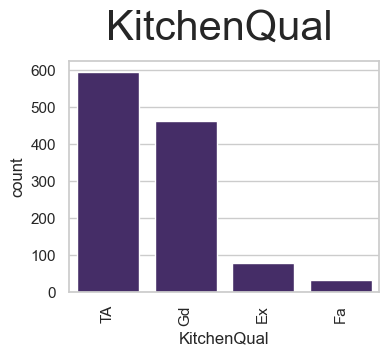

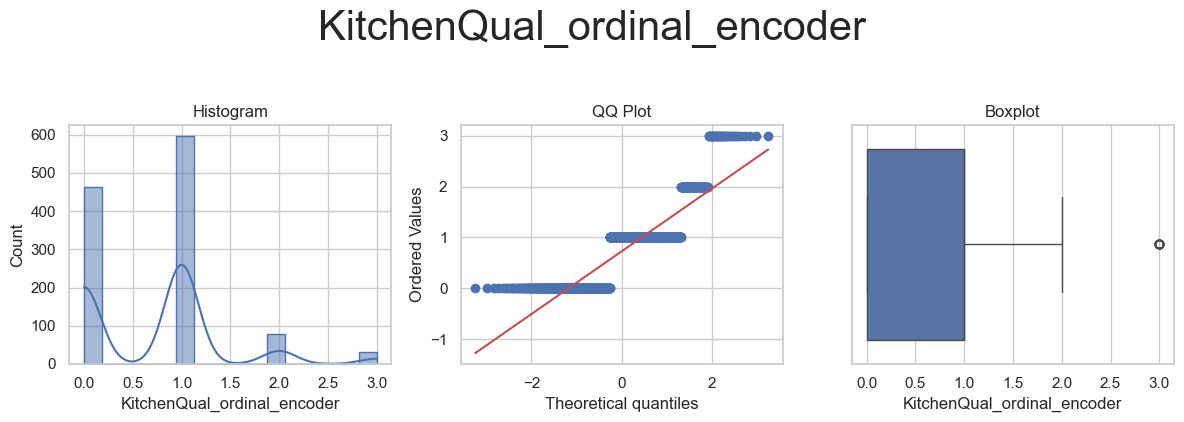

In [33]:
%matplotlib inline
df_engineering = FeatureEngineeringAnalysis(df=df_engineering,
                                            analysis_type='ordinal_encoder')


* Step 4 - Apply the selected transformation to the Train and Test set

In [34]:
# the steps are:
# 1 - create a transformer
# 2 - fit_transform into TrainSet
# 3 - transform into TestSet
encoder = OrdinalEncoder(encoding_method='arbitrary',
                         variables=variables_engineering)
TrainSet = encoder.fit_transform(TrainSet)
TestSet = encoder.transform(TestSet)

print("* Categorical encoding - ordinal transformation done!")


* Categorical encoding - ordinal transformation done!


### SmartCorrelatedSelection Variables

* Step 1: We need all variables for this transformer and we don't need to select features.

* Step 2: Create a separate DataFrame, with your variable(s)

In [35]:
df_engineering = TrainSet.copy()
df_engineering.head(3)


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,GarageArea,GarageFinish,GarageYrBlt,...,LotArea,LotFrontage,OverallCond,OverallQual,TotalBsmtSF,YearBuilt,YearRemodAdd,SalePrice,HasOpenPorch,HasMasonry
0,42.755117,0.0,2.840050,0,6.239650,0,72.857863,285.045711,0,3.302547,...,3448.815525,77.908699,2.369163,6.290680,800.735534,1.413616e+70,2.779130e+103,314813,1,1
1,29.899833,0.0,1.917971,1,0.000000,0,53.096375,133.391168,0,3.292699,...,2117.319597,52.749405,2.369163,3.389233,429.933435,8.655231e+69,1.352485e+103,109500,0,0
2,31.048349,0.0,1.917971,1,15.117559,1,22.237751,176.328998,0,3.283527,...,3863.688883,69.566474,2.882019,3.389233,422.359799,5.481105e+69,2.735488e+103,163500,0,0


* Step 3: Define important features to protect

In [36]:
protected_features = ['GrLivArea', 'OverallQual', 'GarageArea']


Run SmartCorrelatedSelection

In [37]:
from feature_engine.selection import SmartCorrelatedSelection

# Fit the selector on the engineered features
corr_sel = SmartCorrelatedSelection(
    variables=None,
    method="spearman",          # or "pearson", depending on distribution
    threshold=0.6,
    selection_method="variance"
)

df_engineering_filtered = corr_sel.fit_transform(df_engineering)


In [38]:
# Get full list of features the selector recommends dropping
features_to_drop = corr_sel.features_to_drop_


In [39]:
# Only drop the ones that are NOT protected
final_features_to_drop = [
    f for f in features_to_drop
    if f not in protected_features
]


In [40]:
TrainSet.drop(columns=final_features_to_drop, inplace=True)
TestSet.drop(columns=final_features_to_drop, inplace=True)


In [41]:
print("All features suggested to drop:", features_to_drop)
print("Final features dropped (non-protected):", final_features_to_drop)
print("Protected features retained:", protected_features)


All features suggested to drop: ['1stFlrSF', 'GarageArea', 'GarageYrBlt', 'GrLivArea', 'OverallQual']
Final features dropped (non-protected): ['1stFlrSF', 'GarageYrBlt']
Protected features retained: ['GrLivArea', 'OverallQual', 'GarageArea']


# Conclusion

* **Sparse Feature Removal**

    The features ["OpenPorchSF", "MasVnrArea"] had a high proportion of missing or zero values and were dropped. Prior to removal, they were transformed into binary indicators outside the pipeline to preserve potential signals.

* **Ordinal Encoding**

    Four categorical features ["BsmtExposure", "BsmtFinType1", "GarageFinish", "KitchenQual"] were encoded using an arbitrary ordinal encoder.

* **Numerical Transformation**

    Skewed and non-normally distributed numerical features were transformed using the most suitable technique:

    * **PowerTransformer** was applied to ["1stFlrSF"].

    * **Yeo-Johnson transformation** was applied to ["BedroomAbvGr", "BsmtFinSF1", "BsmtUnfSF", "GarageArea", "YearBuilt", "YearRemodAdd", "GrLivArea", "LotArea", "LotFrontage", "OverallCond", "TotalBsmtSF"]

    * **Log10 transformation** was applied to ["GarageYrBlt"] due to heavy skew.

    * **Box-Cox transformation** was applied to ["OverallQual"], which benefits from variance stabilization.

* **Correlated Feature Removal**

    Based on Smart Correlation Selection, features such as ["1stFlrSF", "GarageYrBlt"] were removed to prevent multicollinearity while protecting key predictors like OverallQual and GrLivArea.